TESTING BASIC DIGITAL TWIN SYSTEM
Initializing Basic Digital Twin System
System initialized
Results directory: analysis_results/

Adding Test Patients:

Adding Patient: P001
Gene Expression: [2.8, 3.2, 1.5, 1.1, 1.3]
Treatment Outcome: Gefitinib
Patient P001 added successfully

Gene Expression Profile for P001:
----------------------------------------
TP53: 2.8x (HIGH)
EGFR: 3.2x (HIGH)
BRCA1: 1.5x (NORMAL)
MYC: 1.1x (NORMAL)
RAS: 1.3x (NORMAL)
----------------------------------------


Adding Patient: P002
Gene Expression: [2.1, 1.8, 1.4, 2.9, 2.3]
Treatment Outcome: Imatinib
Patient P002 added successfully

Gene Expression Profile for P002:
----------------------------------------
TP53: 2.1x (HIGH)
EGFR: 1.8x (NORMAL)
BRCA1: 1.4x (NORMAL)
MYC: 2.9x (HIGH)
RAS: 2.3x (HIGH)
----------------------------------------


Adding Patient: P003
Gene Expression: [1.9, 3.0, 2.1, 1.2, 1.1]
Treatment Outcome: Gefitinib
Patient P003 added successfully

Gene Expression Profile for P003:
------------

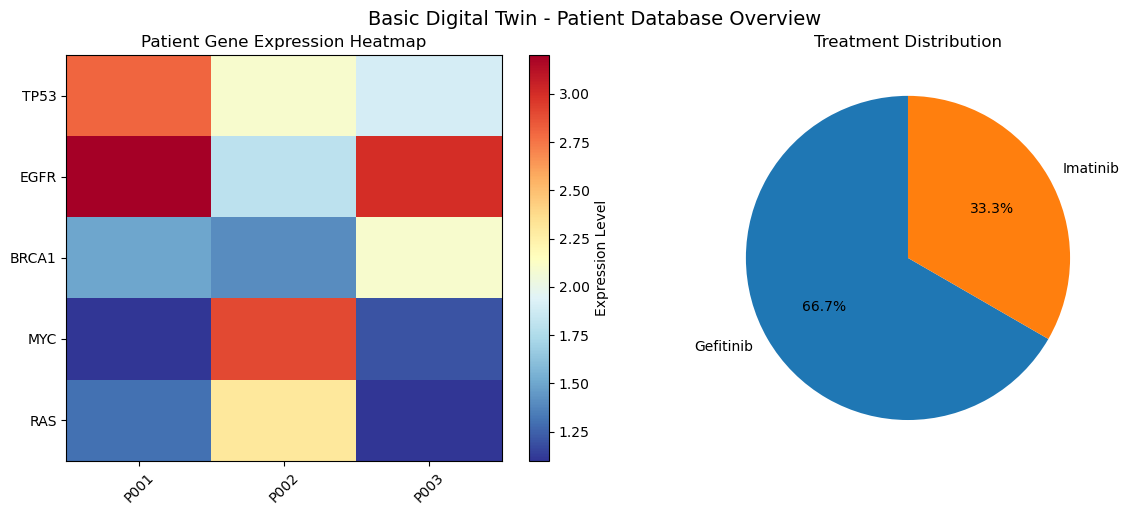


BASIC SYSTEM TEST COMPLETE!
Next: Run Chunk 2 for Patient Analysis

CHUNK 1 COMPLETED SUCCESSFULLY!
Basic digital twin system working
Patient database functional
Basic visualization created
Foundation ready for advanced features

Check your results in: analysis_results/
Ready for Chunk 2: Patient Analysis!


In [1]:
#!/usr/bin/env python3
"""
CHUNK 1: Basic System Foundation
Creates the core digital twin class with basic functionality.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime

class BasicDigitalTwin:
    """Foundation class for the cancer digital twin."""
    
    # Define a consistent list of genes for the entire system
    GENES = ['TP53', 'EGFR', 'BRCA1', 'MYC', 'RAS']
    
    def __init__(self):
        print("Initializing Basic Digital Twin System")
        
        # Core data storage
        self.patients_db = pd.DataFrame()
        self.outcomes_db = {}
        self.system_stats = {
            'patients_added': 0,
            'outcomes_recorded': 0,
            'creation_time': datetime.now().isoformat()
        }
        
        # Create a directory to store analysis results
        self.results_dir = "analysis_results"
        os.makedirs(self.results_dir, exist_ok=True)
        
        print(f"System initialized")
        print(f"Results directory: {self.results_dir}/")
    
    def add_patient(self, patient_id, gene_expression, treatment_outcome=None):
        """Adds a new patient to the system database."""
        
        print(f"\nAdding Patient: {patient_id}")
        print(f"Gene Expression: {gene_expression}")
        
        # Create a DataFrame with gene names and add to the database
        gene_df = pd.DataFrame([gene_expression], index=[patient_id], columns=self.GENES)
        self.patients_db = pd.concat([self.patients_db, gene_df], sort=False)
        
        # Store the treatment outcome if provided
        if treatment_outcome:
            self.outcomes_db[patient_id] = treatment_outcome
            self.system_stats['outcomes_recorded'] += 1
            print(f"Treatment Outcome: {treatment_outcome}")
        
        self.system_stats['patients_added'] += 1
        print(f"Patient {patient_id} added successfully")
        
        # Display a simple gene profile
        self._show_gene_profile(patient_id, gene_expression)
        
        return True
    
    def _show_gene_profile(self, patient_id, gene_expression):
        """Displays a basic gene expression profile for a given patient."""
        
        print(f"\nGene Expression Profile for {patient_id}:")
        print("-" * 40)
        
        # Iterate through genes and their expression values to print status
        for gene, expr in zip(self.GENES[:len(gene_expression)], gene_expression):
            status = "HIGH" if expr > 2.0 else "NORMAL"
            print(f"{gene}: {expr:.1f}x ({status})")
        
        print("-" * 40)
    
    def show_database_summary(self):
        """Displays the current status of the patient database."""
        
        print(f"\nDATABASE SUMMARY")
        print("=" * 50)
        print(f"Total Patients: {len(self.patients_db)}")
        print(f"Patients with Outcomes: {len(self.outcomes_db)}")
        print(f"System Created: {self.system_stats['creation_time'][:19]}")
        
        if len(self.patients_db) > 0:
            print(f"\nPatient List:")
            for patient_id in self.patients_db.index:
                outcome = self.outcomes_db.get(patient_id, "Unknown")
                print(f"  • {patient_id}: {outcome}")
        
        print("=" * 50)
    
    def create_basic_visualization(self):
        """Generates and saves a basic visualization of the patient data."""
        
        if len(self.patients_db) == 0:
            print("No patients to visualize yet")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot 1: Gene expression heatmap
        if len(self.patients_db) > 0:
            data_for_heatmap = self.patients_db.T
            im = ax1.imshow(data_for_heatmap.values, cmap='RdYlBu_r', aspect='auto')
            
            # Set labels and title
            ax1.set_xticks(range(len(self.patients_db.index)))
            ax1.set_xticklabels(self.patients_db.index, rotation=45)
            ax1.set_yticks(range(len(data_for_heatmap.index)))
            ax1.set_yticklabels(self.GENES[:len(data_for_heatmap.index)])
            ax1.set_title('Patient Gene Expression Heatmap')
            
            # Add colorbar
            plt.colorbar(im, ax=ax1, label='Expression Level')
        
        # Plot 2: Treatment outcome distribution
        if self.outcomes_db:
            outcomes = list(self.outcomes_db.values())
            outcome_counts = {}
            for outcome in outcomes:
                outcome_counts[outcome] = outcome_counts.get(outcome, 0) + 1
            
            if outcome_counts:
                drugs = list(outcome_counts.keys())
                counts = list(outcome_counts.values())
                
                ax2.pie(counts, labels=drugs, autopct='%1.1f%%', startangle=90)
                ax2.set_title('Treatment Distribution')
        else:
            ax2.text(0.5, 0.5, 'No Treatment Data\nAvailable Yet', 
                    ha='center', va='center', transform=ax2.transAxes, fontsize=12)
            ax2.set_title('Treatment Distribution')
        
        plt.tight_layout()
        plt.suptitle('Basic Digital Twin - Patient Database Overview', fontsize=14, y=1.02)
        
        # Save the plot
        save_path = f'{self.results_dir}/basic_database_overview.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Visualization saved: {save_path}")
        
        plt.show()
        plt.close()

def test_basic_system():
    """Tests the basic digital twin system's core functionalities."""
    
    print("TESTING BASIC DIGITAL TWIN SYSTEM")
    print("="*60)
    
    # Initialize the system
    twin = BasicDigitalTwin()
    
    # Add test patients
    print("\nAdding Test Patients:")
    
    test_patients = [
        ('P001', [2.8, 3.2, 1.5, 1.1, 1.3], 'Gefitinib'),
        ('P002', [2.1, 1.8, 1.4, 2.9, 2.3], 'Imatinib'),
        ('P003', [1.9, 3.0, 2.1, 1.2, 1.1], 'Gefitinib'),
    ]
    
    for patient_id, genes, treatment in test_patients:
        twin.add_patient(patient_id, genes, treatment)
        print()
    
    # Show the database summary
    twin.show_database_summary()
    
    # Create the visualization
    print("\nCreating Basic Visualization...")
    twin.create_basic_visualization()
    
    print("\nBASIC SYSTEM TEST COMPLETE!")
    print("Next: Run Chunk 2 for Patient Analysis")
    
    return twin

if __name__ == "__main__":
    digital_twin = test_basic_system()
    
    print("\n" + "="*60)
    print("CHUNK 1 COMPLETED SUCCESSFULLY!")
    print("="*60)
    print("Basic digital twin system working")
    print("Patient database functional")  
    print("Basic visualization created")
    print("Foundation ready for advanced features")
    
    print(f"\nCheck your results in: analysis_results/")
    print("Ready for Chunk 2: Patient Analysis!")

TESTING PATIENT ANALYSIS SYSTEM
Initializing Basic Digital Twin System
System initialized
Results directory: analysis_results/
Patient Analyzer Module Loaded

Analyzing Individual Patients:


DETAILED ANALYSIS: Patient_A

Adding Patient: Patient_A
Gene Expression: [2.8, 3.2, 1.5, 1.1, 1.3]
Treatment Outcome: Gefitinib
Patient Patient_A added successfully

Gene Expression Profile for Patient_A:
----------------------------------------
TP53: 2.8x (HIGH)
EGFR: 3.2x (HIGH)
BRCA1: 1.5x (NORMAL)
MYC: 1.1x (NORMAL)
RAS: 1.3x (NORMAL)
----------------------------------------

Gene Expression Analysis:
----------------------------------------
TP53 (Tumor Suppressor):
   Expression: 2.8x (HIGH)
   Risk: Low risk

EGFR (Oncogene):
   Expression: 3.2x (HIGH)
   Risk: HIGH RISK

BRCA1 (Tumor Suppressor):
   Expression: 1.5x (NORMAL)
   Risk: Low risk

MYC (Oncogene):
   Expression: 1.1x (NORMAL)
   Risk: Low risk

RAS (Oncogene):
   Expression: 1.3x (NORMAL)
   Risk: Low risk

Overall Cancer Risk S

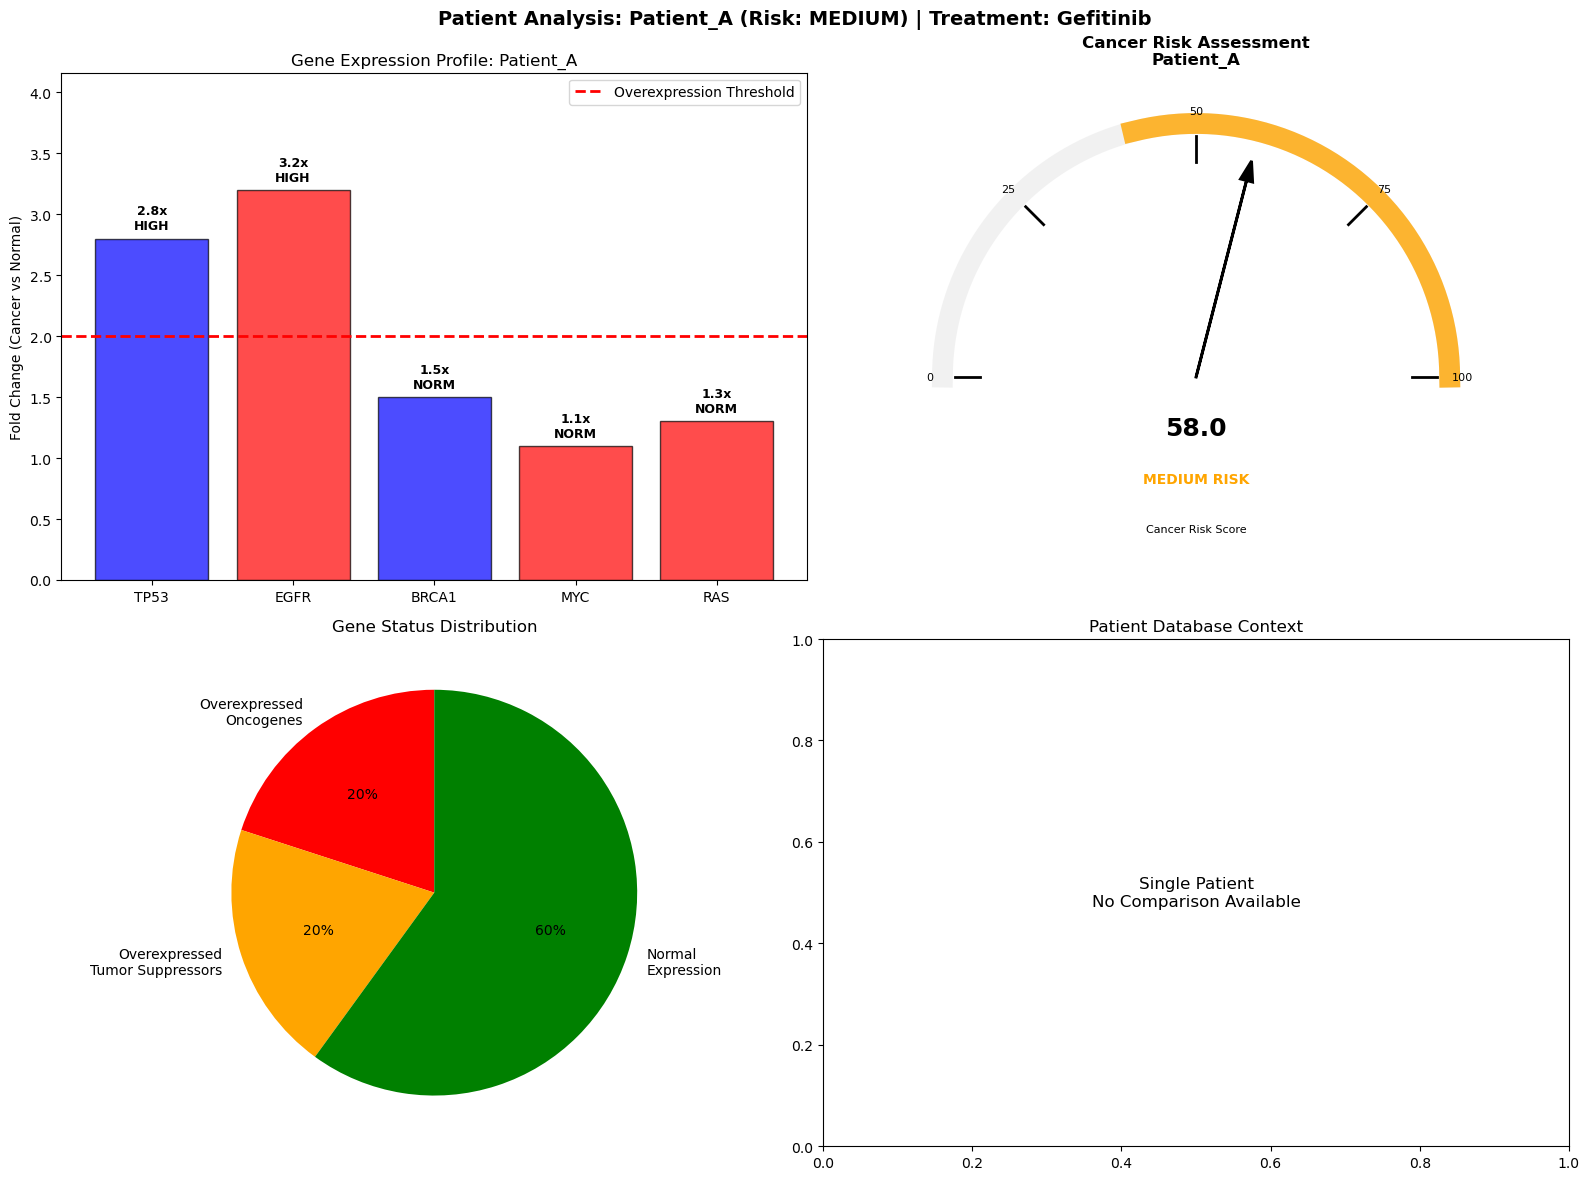

Analysis complete for Patient_A
Risk Score: 58.0/100
Overexpressed genes: TP53, EGFR


DETAILED ANALYSIS: Patient_B

Adding Patient: Patient_B
Gene Expression: [2.1, 1.8, 1.4, 2.9, 2.3]
Treatment Outcome: Imatinib
Patient Patient_B added successfully

Gene Expression Profile for Patient_B:
----------------------------------------
TP53: 2.1x (HIGH)
EGFR: 1.8x (NORMAL)
BRCA1: 1.4x (NORMAL)
MYC: 2.9x (HIGH)
RAS: 2.3x (HIGH)
----------------------------------------

Gene Expression Analysis:
----------------------------------------
TP53 (Tumor Suppressor):
   Expression: 2.1x (HIGH)
   Risk: Low risk

EGFR (Oncogene):
   Expression: 1.8x (NORMAL)
   Risk: Low risk

BRCA1 (Tumor Suppressor):
   Expression: 1.4x (NORMAL)
   Risk: Low risk

MYC (Oncogene):
   Expression: 2.9x (HIGH)
   Risk: HIGH RISK

RAS (Oncogene):
   Expression: 2.3x (HIGH)
   Risk: HIGH RISK

Overall Cancer Risk Score: 67.0/100
Overexpressed Genes: 3/5
Patient analysis saved: analysis_results/patient_analysis_Patient_B.p

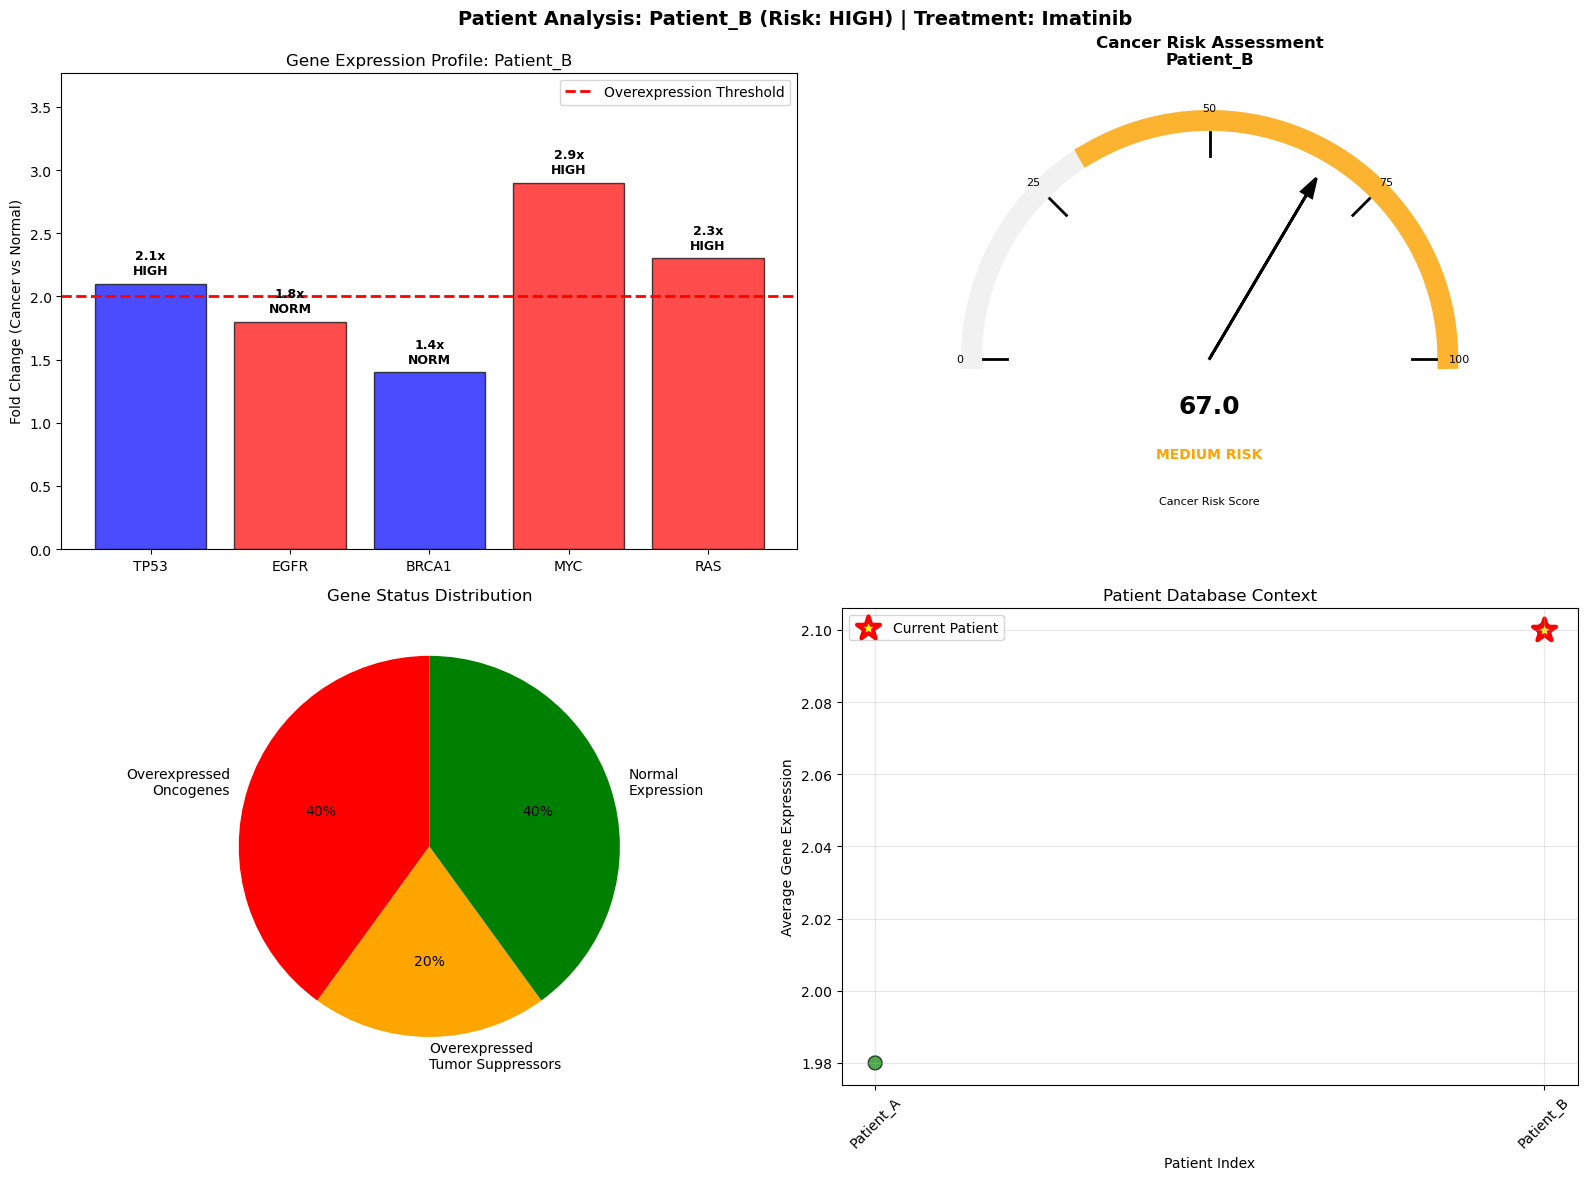

Analysis complete for Patient_B
Risk Score: 67.0/100
Overexpressed genes: TP53, MYC, RAS


DETAILED ANALYSIS: Patient_C

Adding Patient: Patient_C
Gene Expression: [1.9, 3.0, 2.1, 1.2, 1.1]
Treatment Outcome: Gefitinib
Patient Patient_C added successfully

Gene Expression Profile for Patient_C:
----------------------------------------
TP53: 1.9x (NORMAL)
EGFR: 3.0x (HIGH)
BRCA1: 2.1x (HIGH)
MYC: 1.2x (NORMAL)
RAS: 1.1x (NORMAL)
----------------------------------------

Gene Expression Analysis:
----------------------------------------
TP53 (Tumor Suppressor):
   Expression: 1.9x (NORMAL)
   Risk: Low risk

EGFR (Oncogene):
   Expression: 3.0x (HIGH)
   Risk: HIGH RISK

BRCA1 (Tumor Suppressor):
   Expression: 2.1x (HIGH)
   Risk: Low risk

MYC (Oncogene):
   Expression: 1.2x (NORMAL)
   Risk: Low risk

RAS (Oncogene):
   Expression: 1.1x (NORMAL)
   Risk: Low risk

Overall Cancer Risk Score: 53.4/100
Overexpressed Genes: 2/5
Patient analysis saved: analysis_results/patient_analysis_Pat

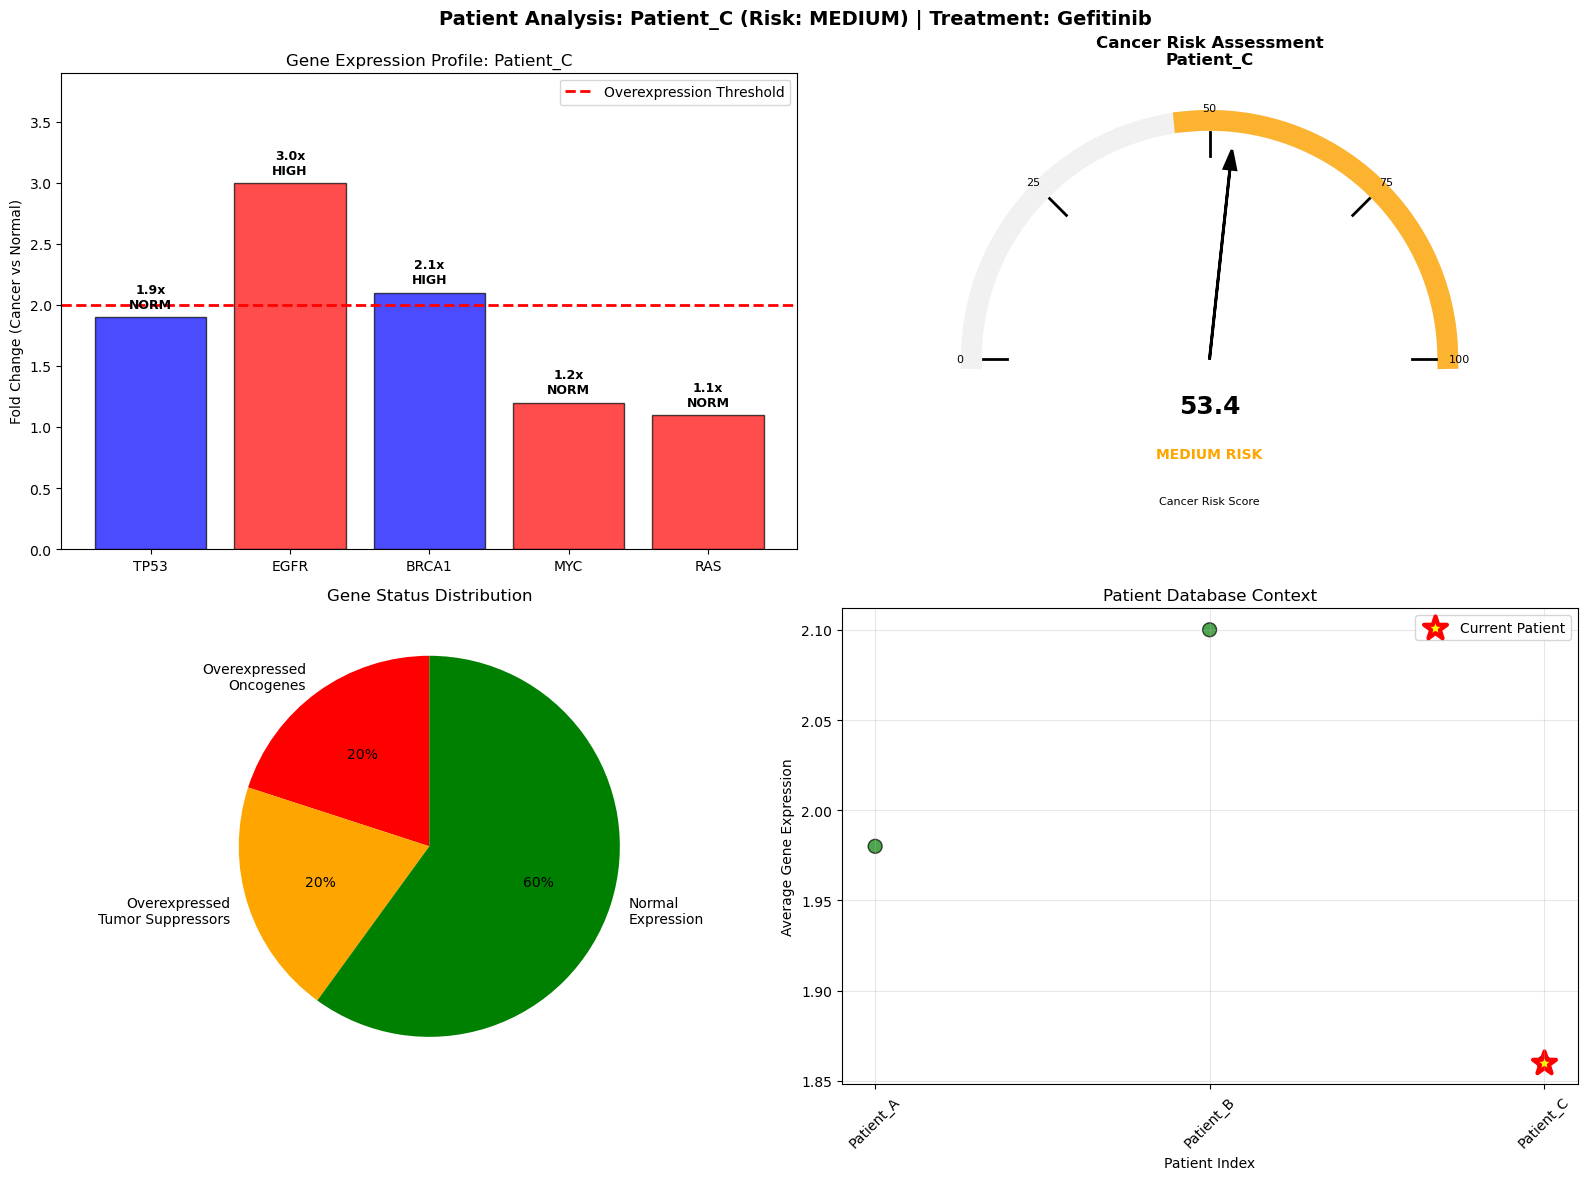

Analysis complete for Patient_C
Risk Score: 53.4/100
Overexpressed genes: EGFR, BRCA1

Comparing All Patients:

COMPARING PATIENTS: Patient_A, Patient_B, Patient_C
Patient comparison saved: analysis_results/patient_comparison.png


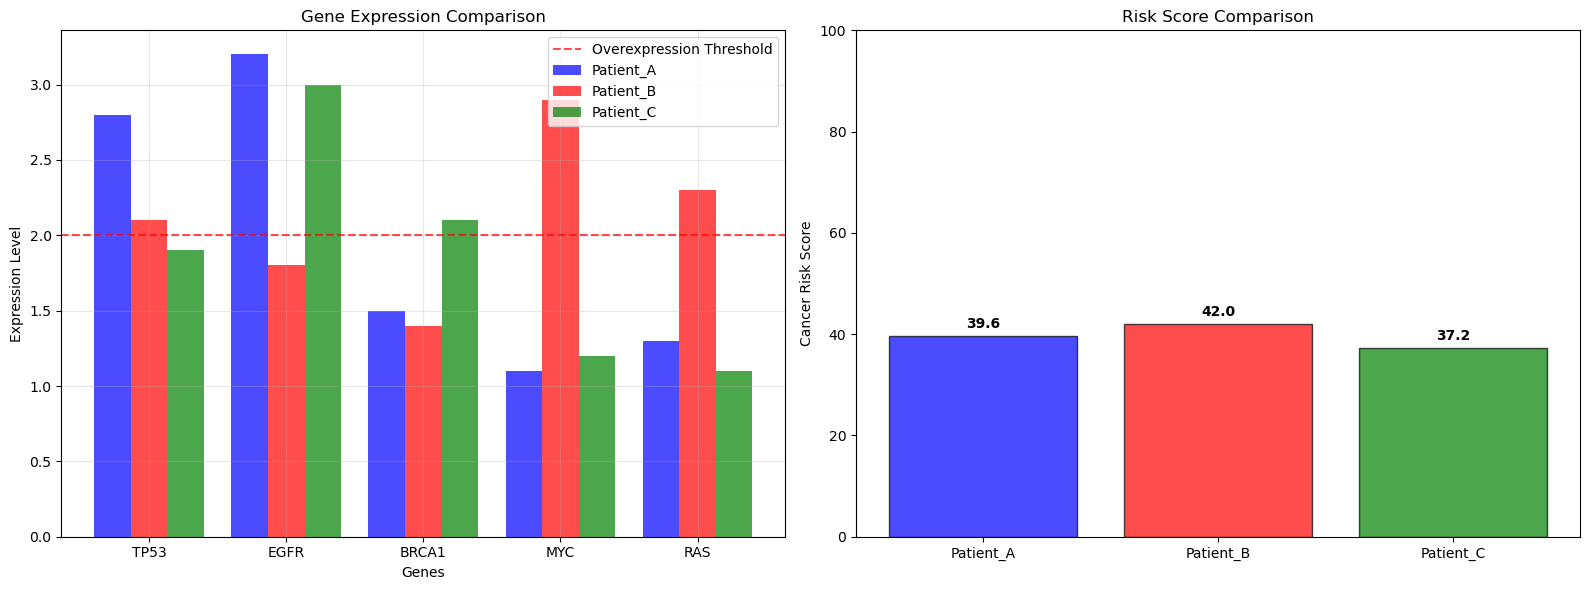


PATIENT ANALYSIS TEST COMPLETE!
Next: Run Chunk 3 for Similarity Engine

CHUNK 2 COMPLETED SUCCESSFULLY!
Patient analysis system working
Detailed gene expression analysis
Risk assessment gauges created
Patient comparison functionality

Check your results in: analysis_results/
Ready for Chunk 3: Similarity Engine!


In [3]:
#!/usr/bin/env python3
"""
CHUNK 2: Patient Analysis with Gene Visualization
This chunk extends the basic digital twin to perform detailed patient analysis.

Save as: chunk2_patient_analysis.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from chunk1_basic_system import BasicDigitalTwin
import os

class PatientAnalyzer(BasicDigitalTwin):
    """Extended digital twin with detailed patient analysis capabilities."""
    
    def __init__(self):
        super().__init__()
        print("Patient Analyzer Module Loaded")
        
        # Gene information mapping gene names to type
        self.gene_info = {
            'TP53': {'name': 'Tumor Protein 53', 'type': 'Tumor Suppressor'},
            'EGFR': {'name': 'Epidermal Growth Factor Receptor', 'type': 'Oncogene'},
            'BRCA1': {'name': 'Breast Cancer 1', 'type': 'Tumor Suppressor'},
            'MYC': {'name': 'MYC Proto-Oncogene', 'type': 'Oncogene'},
            'RAS': {'name': 'RAS Proto-Oncogene', 'type': 'Oncogene'}
        }
    
    def analyze_patient_profile(self, patient_id, gene_expression, treatment_outcome=None):
        """Performs a detailed analysis of a patient's gene expression profile."""
        
        print(f"\nDETAILED ANALYSIS: {patient_id}")
        print("="*50)
        
        # Add patient to database before analysis
        self.add_patient(patient_id, gene_expression, treatment_outcome)
        
        # Perform gene analysis and calculate risk score
        analysis_results = self._perform_gene_analysis(gene_expression, patient_id)
        
        # Create visualization based on the analysis
        self._create_patient_visualization(patient_id, gene_expression, analysis_results, treatment_outcome)
        
        return analysis_results
    
    def _perform_gene_analysis(self, gene_expression, patient_id):
        """Analyzes gene expression patterns to calculate a risk score."""
        
        genes = self.GENES
        analysis = {
            'patient_id': patient_id,
            'overexpressed_genes': [],
            'normal_genes': [],
            'cancer_risk_score': 0,
            'gene_details': []
        }
        
        print(f"\nGene Expression Analysis:")
        print("-"*40)
        
        total_score = 0
        for i, (gene, expr) in enumerate(zip(genes[:len(gene_expression)], gene_expression)):
            gene_analysis = {
                'gene': gene,
                'expression': expr,
                'fold_change': expr,
                'status': 'HIGH' if expr > 2.0 else 'NORMAL',
                'gene_type': self.gene_info.get(gene, {}).get('type', 'Unknown'),
                'full_name': self.gene_info.get(gene, {}).get('name', gene)
            }
            
            # Calculate contribution to cancer risk based on gene type and expression level
            if expr > 2.0:
                analysis['overexpressed_genes'].append(gene)
                if gene_analysis['gene_type'] == 'Oncogene':
                    total_score += expr * 2
                else:
                    total_score += expr * 1.5
            else:
                analysis['normal_genes'].append(gene)
                total_score += expr
            
            analysis['gene_details'].append(gene_analysis)
            
            risk_contribution = "HIGH RISK" if expr > 2.0 and gene_analysis['gene_type'] == 'Oncogene' else "Low risk"
            
            print(f"{gene} ({gene_analysis['gene_type']}):")
            print(f"   Expression: {expr:.1f}x ({gene_analysis['status']})")
            print(f"   Risk: {risk_contribution}")
            print()
        
        # Calculate overall risk score
        analysis['cancer_risk_score'] = min(100, (total_score / len(gene_expression)) * 20)
        
        print(f"Overall Cancer Risk Score: {analysis['cancer_risk_score']:.1f}/100")
        print(f"Overexpressed Genes: {len(analysis['overexpressed_genes'])}/{len(gene_expression)}")
        
        return analysis
    
    def _create_patient_visualization(self, patient_id, gene_expression, analysis, treatment_outcome):
        """Creates a detailed multi-panel visualization for a patient's analysis."""
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Gene expression bar chart
        genes = self.GENES[:len(gene_expression)]
        gene_types = [self.gene_info.get(gene, {}).get('type', 'Unknown') for gene in genes]
        colors = ['red' if gt == 'Oncogene' else 'blue' for gt in gene_types]
        
        bars = ax1.bar(genes, gene_expression, color=colors, alpha=0.7, edgecolor='black')
        ax1.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Overexpression Threshold')
        ax1.set_ylabel('Fold Change (Cancer vs Normal)')
        ax1.set_title(f'Gene Expression Profile: {patient_id}')
        ax1.legend()
        ax1.set_ylim(0, max(gene_expression) * 1.3)
        
        for bar, expr, gene in zip(bars, gene_expression, genes):
            height = bar.get_height()
            status = 'HIGH' if expr > 2.0 else 'NORM'
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{expr:.1f}x\n{status}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Plot 2: Risk assessment gauge
        self._draw_risk_gauge(ax2, analysis['cancer_risk_score'], patient_id)
        
        # Plot 3: Gene type breakdown pie chart
        overexpressed_oncogenes = sum(1 for detail in analysis['gene_details'] if detail['gene_type'] == 'Oncogene' and detail['expression'] > 2.0)
        overexpressed_tumor_suppressors = sum(1 for detail in analysis['gene_details'] if detail['gene_type'] == 'Tumor Suppressor' and detail['expression'] > 2.0)
        normal_genes = len(gene_expression) - overexpressed_oncogenes - overexpressed_tumor_suppressors
        
        categories = ['Overexpressed\nOncogenes', 'Overexpressed\nTumor Suppressors', 'Normal\nExpression']
        values = [overexpressed_oncogenes, overexpressed_tumor_suppressors, normal_genes]
        colors_pie = ['red', 'orange', 'green']
        
        if sum(values) > 0:
            ax3.pie(values, labels=categories, colors=colors_pie, autopct='%1.0f%%', startangle=90)
        ax3.set_title('Gene Status Distribution')
        
        # Plot 4: Patient position in database context
        if len(self.patients_db) > 1:
            patient_scores = []
            patient_ids = []
            
            for pid in self.patients_db.index:
                genes_patient = self.patients_db.loc[pid].values
                score = np.mean(genes_patient)
                patient_scores.append(score)
                patient_ids.append(pid)
            
            colors_scatter = []
            for pid in patient_ids:
                if pid in self.outcomes_db:
                    if 'success' in str(self.outcomes_db[pid]).lower() or self.outcomes_db[pid] in ['Gefitinib', 'Imatinib', 'Dasatinib']:
                        colors_scatter.append('green')
                    else:
                        colors_scatter.append('red')
                else:
                    colors_scatter.append('gray')
            
            x_positions = range(len(patient_ids))
            ax4.scatter(x_positions, patient_scores, c=colors_scatter, s=100, alpha=0.7, edgecolors='black')
            
            if patient_id in patient_ids:
                current_idx = patient_ids.index(patient_id)
                ax4.scatter(current_idx, patient_scores[current_idx], c='yellow', s=300, marker='*', 
                           edgecolors='red', linewidths=3, label='Current Patient')
            
            ax4.set_xlabel('Patient Index')
            ax4.set_ylabel('Average Gene Expression')
            ax4.set_title('Patient Database Context')
            ax4.set_xticks(x_positions)
            ax4.set_xticklabels(patient_ids, rotation=45)
            ax4.legend()
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, 'Single Patient\nNo Comparison Available', 
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('Patient Database Context')
        
        outcome_text = f" | Treatment: {treatment_outcome}" if treatment_outcome else ""
        risk_score = analysis['cancer_risk_score']
        
        # Harmonized risk level logic for title
        if risk_score > 60:
            risk_level_text = "HIGH"
        elif risk_score > 40:
            risk_level_text = "MEDIUM"
        else:
            risk_level_text = "LOW"
            
        plt.suptitle(f'Patient Analysis: {patient_id} (Risk: {risk_level_text}){outcome_text}', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        save_path = f'{self.results_dir}/patient_analysis_{patient_id}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Patient analysis saved: {save_path}")
        
        plt.show()
        plt.close()
    
    def _draw_risk_gauge(self, ax, risk_score, patient_id):
        """Draws a cancer risk assessment gauge visualization."""
        
        theta = np.linspace(0, np.pi, 100)
        ax.plot(np.cos(theta), np.sin(theta), 'lightgray', linewidth=15, alpha=0.3)
        
        if risk_score >= 70:
            color = 'red'
            label = 'HIGH RISK'
        elif risk_score >= 50:
            color = 'orange'
            label = 'MEDIUM RISK'
        elif risk_score >= 30:
            color = 'yellow'
            label = 'LOW-MEDIUM RISK'
        else:
            color = 'green'
            label = 'LOW RISK'
        
        risk_theta = np.linspace(0, np.pi * risk_score/100, 50)
        ax.plot(np.cos(risk_theta), np.sin(risk_theta), color, linewidth=15, alpha=0.8)
        
        needle_angle = np.pi * (1 - risk_score/100)
        ax.arrow(0, 0, 0.8*np.cos(needle_angle), 0.8*np.sin(needle_angle), 
                head_width=0.05, head_length=0.08, fc='black', ec='black', linewidth=2)
        
        ax.text(0, -0.2, f'{risk_score:.1f}', ha='center', va='center', 
               fontsize=18, fontweight='bold')
        ax.text(0, -0.4, label, ha='center', va='center', 
               fontsize=10, color=color, fontweight='bold')
        ax.text(0, -0.6, 'Cancer Risk Score', ha='center', va='center', fontsize=8)
        
        for i in range(0, 101, 25):
            angle = np.pi * (1 - i/100)
            x1, y1 = 0.85 * np.cos(angle), 0.85 * np.sin(angle)
            x2, y2 = 0.95 * np.cos(angle), 0.95 * np.sin(angle)
            ax.plot([x1, x2], [y1, y2], 'black', linewidth=2)
            ax.text(1.05 * np.cos(angle), 1.05 * np.sin(angle), f'{i}', 
                   ha='center', va='center', fontsize=8)
        
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-0.8, 1.2)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(f'Cancer Risk Assessment\n{patient_id}', fontweight='bold')
    
    def compare_patients(self, patient_ids):
        """Compares multiple patients side-by-side with a visualization."""
        
        if len(patient_ids) < 2:
            print("Need at least 2 patients for comparison")
            return
        
        print(f"\nCOMPARING PATIENTS: {', '.join(patient_ids)}")
        print("="*60)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        genes = self.GENES
        x = np.arange(len(genes))
        width = 0.8 / len(patient_ids)
        
        colors = ['blue', 'red', 'green', 'orange', 'purple']
        
        for i, patient_id in enumerate(patient_ids):
            if patient_id in self.patients_db.index:
                gene_values = self.patients_db.loc[patient_id].values[:len(genes)]
                ax1.bar(x + i*width, gene_values, width, 
                       label=patient_id, color=colors[i % len(colors)], alpha=0.7)
        
        ax1.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='Overexpression Threshold')
        ax1.set_xlabel('Genes')
        ax1.set_ylabel('Expression Level')
        ax1.set_title('Gene Expression Comparison')
        ax1.set_xticks(x + width * (len(patient_ids)-1) / 2)
        ax1.set_xticklabels(genes)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        risk_scores = []
        for patient_id in patient_ids:
            if patient_id in self.patients_db.index:
                genes_patient = self.patients_db.loc[patient_id].values
                risk = min(100, np.mean(genes_patient) * 20)
                risk_scores.append(risk)
            else:
                risk_scores.append(0)
        
        bars = ax2.bar(patient_ids, risk_scores, 
                      color=[colors[i % len(colors)] for i in range(len(patient_ids))], 
                      alpha=0.7, edgecolor='black')
        ax2.set_ylabel('Cancer Risk Score')
        ax2.set_title('Risk Score Comparison')
        ax2.set_ylim(0, 100)
        
        for bar, score in zip(bars, risk_scores):
            ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                    f'{score:.1f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        
        save_path = f'{self.results_dir}/patient_comparison.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Patient comparison saved: {save_path}")
        
        plt.show()
        plt.close()


def test_patient_analysis():
    """Tests the patient analysis system's core functionalities."""
    
    print("TESTING PATIENT ANALYSIS SYSTEM")
    print("="*60)
    
    analyzer = PatientAnalyzer()
    
    print("\nAnalyzing Individual Patients:")
    
    test_patients = [
        ('Patient_A', [2.8, 3.2, 1.5, 1.1, 1.3], 'Gefitinib'),
        ('Patient_B', [2.1, 1.8, 1.4, 2.9, 2.3], 'Imatinib'),
        ('Patient_C', [1.9, 3.0, 2.1, 1.2, 1.1], 'Gefitinib'),
    ]
    
    for patient_id, genes, treatment in test_patients:
        print(f"\n{'='*30}")
        analysis = analyzer.analyze_patient_profile(patient_id, genes, treatment)
        print(f"Analysis complete for {patient_id}")
        print(f"Risk Score: {analysis['cancer_risk_score']:.1f}/100")
        print(f"Overexpressed genes: {', '.join(analysis['overexpressed_genes'])}")
    
    print(f"\n{'='*30}")
    print("Comparing All Patients:")
    analyzer.compare_patients(['Patient_A', 'Patient_B', 'Patient_C'])
    
    print("\nPATIENT ANALYSIS TEST COMPLETE!")
    print("Next: Run Chunk 3 for Similarity Engine")
    
    return analyzer

if __name__ == "__main__":
    patient_analyzer = test_patient_analysis()
    
    print("\n" + "="*60)
    print("CHUNK 2 COMPLETED SUCCESSFULLY!")
    print("="*60)
    print("Patient analysis system working")
    print("Detailed gene expression analysis")
    print("Risk assessment gauges created")
    print("Patient comparison functionality")
    
    print(f"\nCheck your results in: analysis_results/")
    print("Ready for Chunk 3: Similarity Engine!")

TESTING SIMILARITY ENGINE SYSTEM
Initializing Basic Digital Twin System
System initialized
Results directory: analysis_results/
Patient Analyzer Module Loaded
Similarity Engine Module Loaded

Adding Training Patients:

Adding Patient: Patient_001
Gene Expression: [2.8, 3.2, 1.5, 1.1, 1.3]
Treatment Outcome: Gefitinib
Patient Patient_001 added successfully

Gene Expression Profile for Patient_001:
----------------------------------------
TP53: 2.8x (HIGH)
EGFR: 3.2x (HIGH)
BRCA1: 1.5x (NORMAL)
MYC: 1.1x (NORMAL)
RAS: 1.3x (NORMAL)
----------------------------------------

Adding Patient: Patient_002
Gene Expression: [2.1, 1.8, 1.4, 2.9, 2.3]
Treatment Outcome: Imatinib
Patient Patient_002 added successfully

Gene Expression Profile for Patient_002:
----------------------------------------
TP53: 2.1x (HIGH)
EGFR: 1.8x (NORMAL)
BRCA1: 1.4x (NORMAL)
MYC: 2.9x (HIGH)
RAS: 2.3x (HIGH)
----------------------------------------

Adding Patient: Patient_003
Gene Expression: [1.9, 3.0, 2.1, 1.2, 

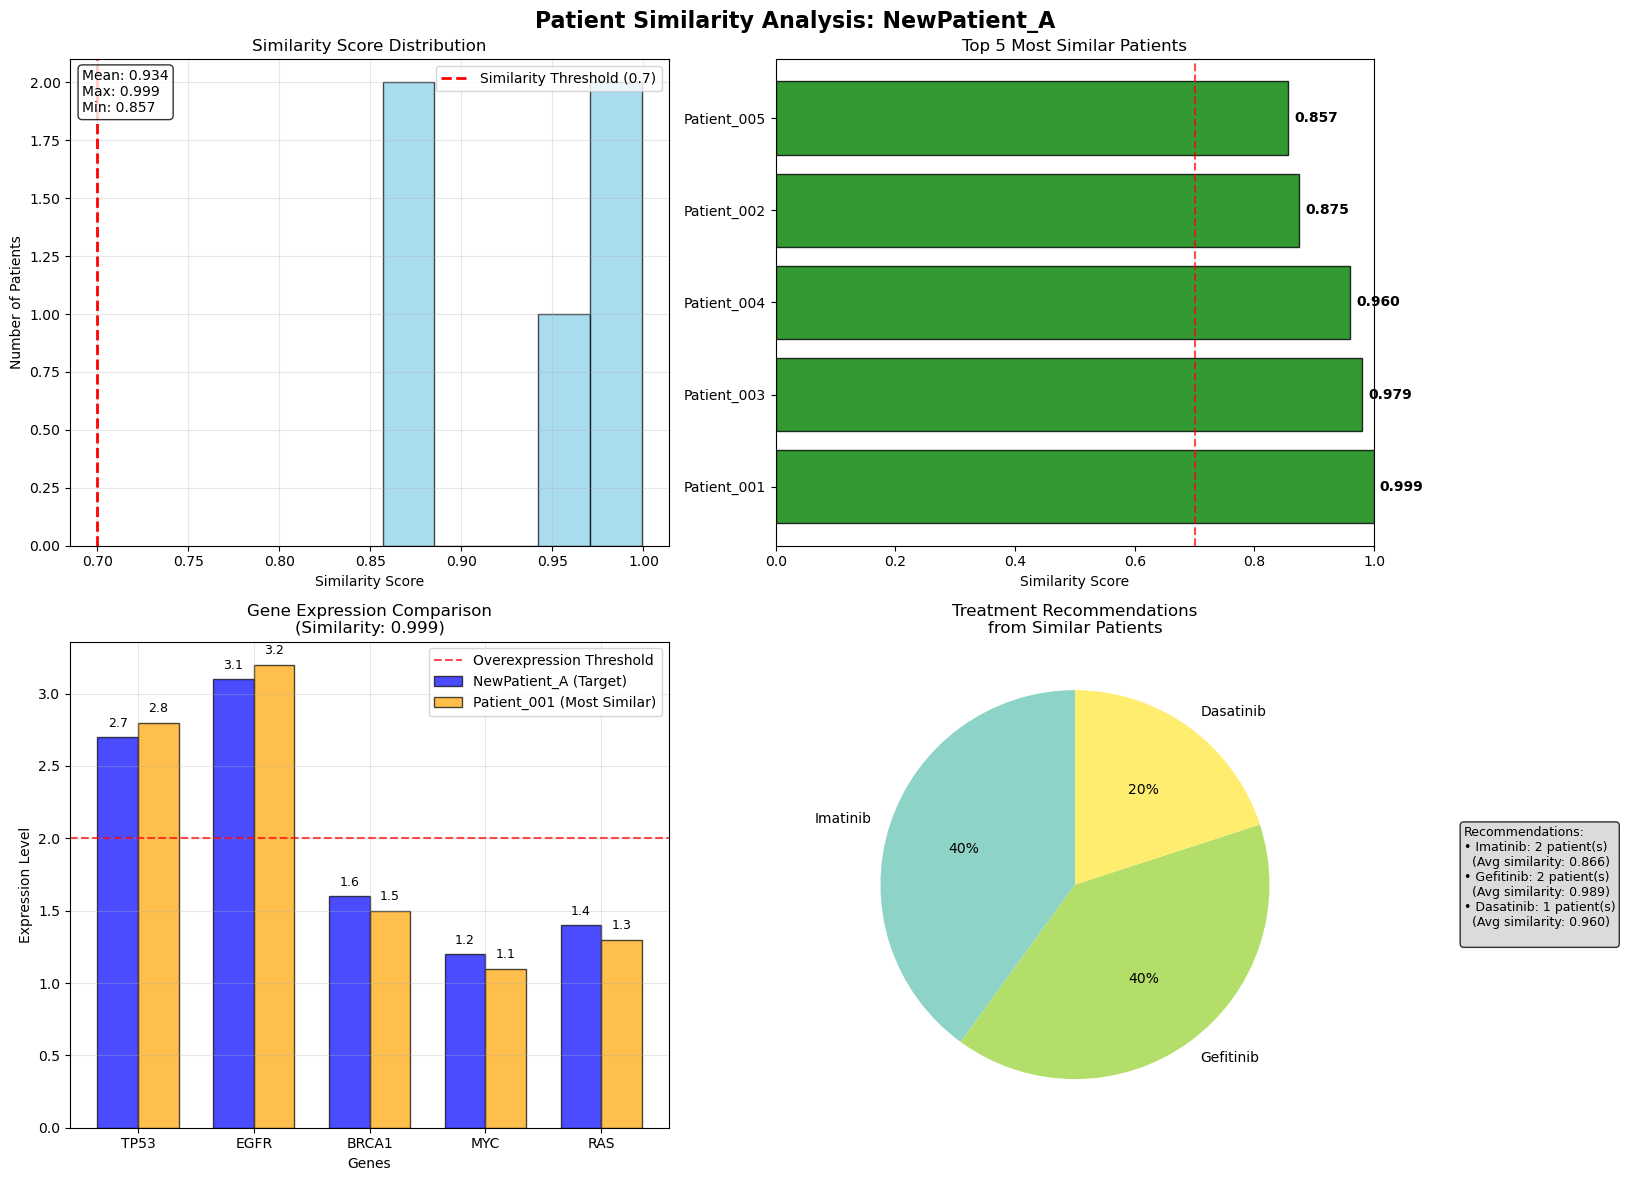


Testing Treatment Prediction:

TREATMENT PREDICTION FOR: NewPatient_A

FINDING SIMILAR PATIENTS FOR: NewPatient_A
Target Gene Expression: [2.7, 3.1, 1.6, 1.2, 1.4]

Similarity Analysis:
----------------------------------------
✅ Patient_001: 0.999 similarity | Treatment: Gefitinib
✅ Patient_002: 0.875 similarity | Treatment: Imatinib
✅ Patient_003: 0.979 similarity | Treatment: Gefitinib
✅ Patient_004: 0.960 similarity | Treatment: Dasatinib
✅ Patient_005: 0.857 similarity | Treatment: Imatinib

Found 5 highly similar patients (≥0.7)

TREATMENT RECOMMENDATIONS:
----------------------------------------
1. Gefitinib
   Confidence: 98.9% (HIGH)
   Supporting Patients: 2 (Patient_001, Patient_003)
   Avg Similarity: 0.989
   Similarity Range: 0.979 - 0.999

2. Dasatinib
   Confidence: 96.0% (HIGH)
   Supporting Patients: 1 (Patient_004)
   Avg Similarity: 0.960
   Similarity Range: 0.960 - 0.960

3. Imatinib
   Confidence: 86.6% (HIGH)
   Supporting Patients: 2 (Patient_002, Patient_005)


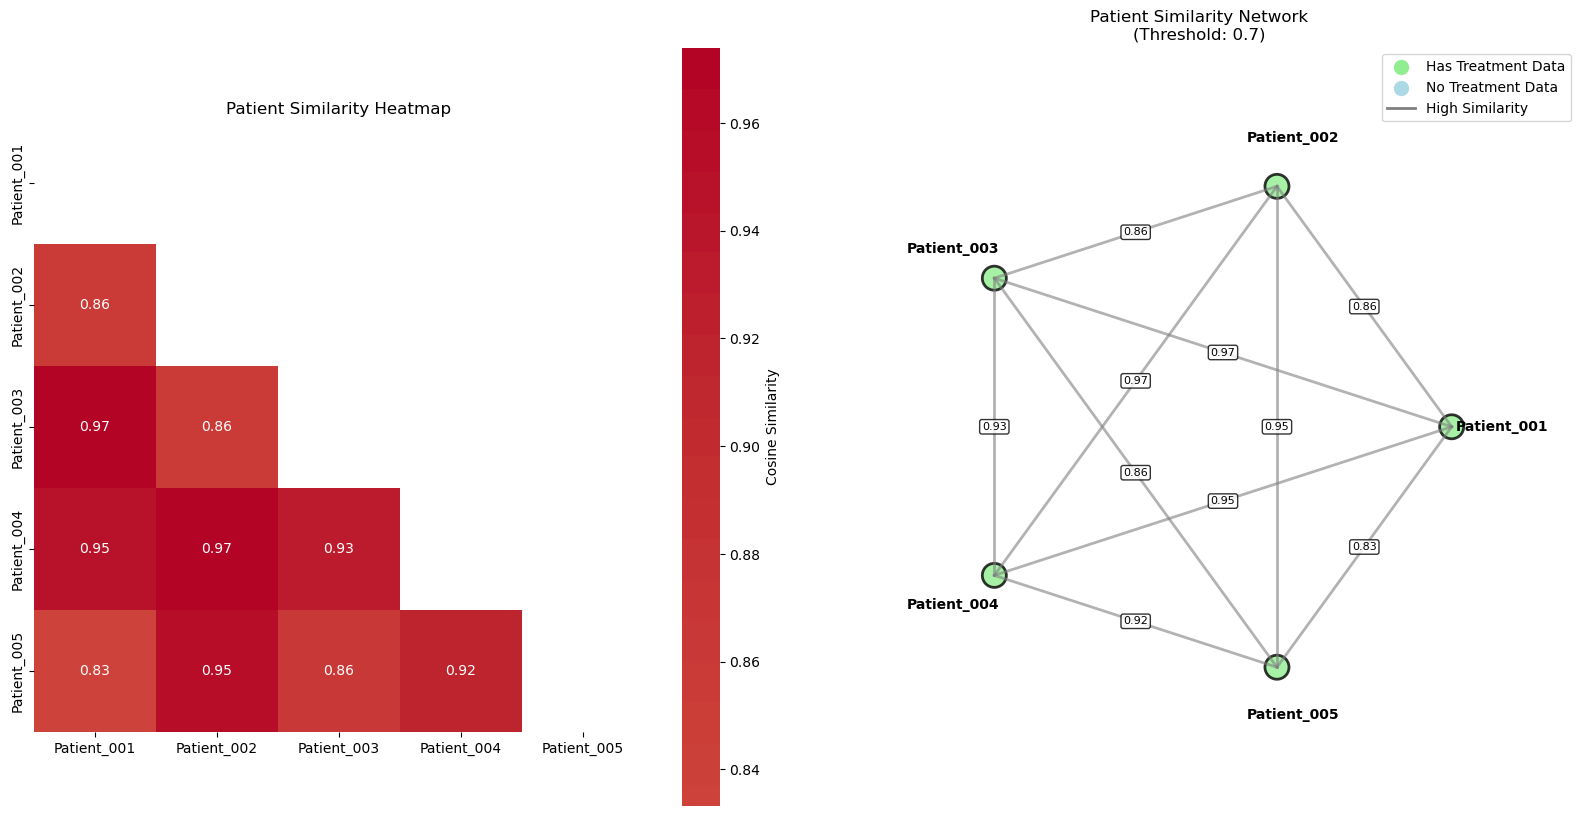


Testing with Different Patient:

FINDING SIMILAR PATIENTS FOR: NewPatient_B
Target Gene Expression: [2.0, 1.7, 1.3, 2.8, 2.4]

Similarity Analysis:
----------------------------------------
✅ Patient_001: 0.845 similarity | Treatment: Gefitinib
✅ Patient_002: 0.999 similarity | Treatment: Imatinib
✅ Patient_003: 0.844 similarity | Treatment: Gefitinib
✅ Patient_004: 0.966 similarity | Treatment: Dasatinib
✅ Patient_005: 0.956 similarity | Treatment: Imatinib

Found 5 highly similar patients (≥0.7)
Similarity analysis saved: analysis_results/similarity_analysis_NewPatient_B.png


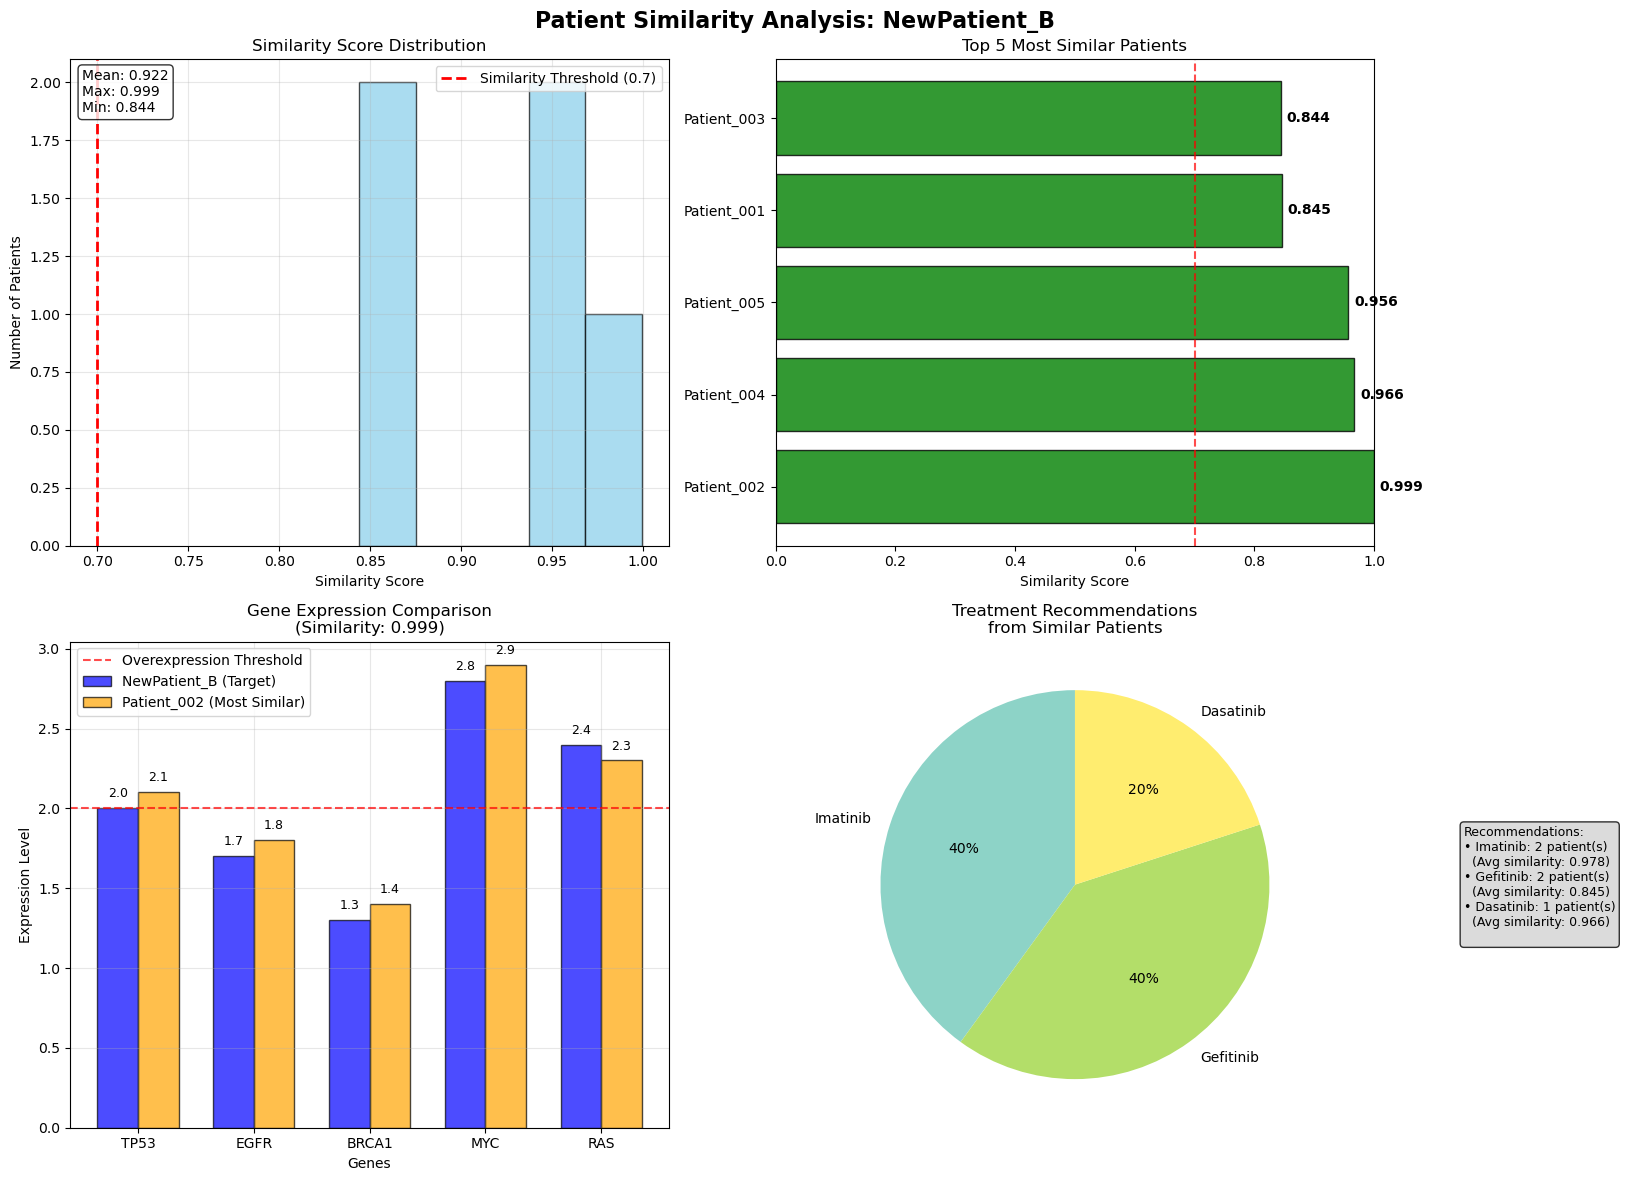


TREATMENT PREDICTION FOR: NewPatient_B

FINDING SIMILAR PATIENTS FOR: NewPatient_B
Target Gene Expression: [2.0, 1.7, 1.3, 2.8, 2.4]

Similarity Analysis:
----------------------------------------
✅ Patient_001: 0.845 similarity | Treatment: Gefitinib
✅ Patient_002: 0.999 similarity | Treatment: Imatinib
✅ Patient_003: 0.844 similarity | Treatment: Gefitinib
✅ Patient_004: 0.966 similarity | Treatment: Dasatinib
✅ Patient_005: 0.956 similarity | Treatment: Imatinib

Found 5 highly similar patients (≥0.7)

TREATMENT RECOMMENDATIONS:
----------------------------------------
1. Imatinib
   Confidence: 97.8% (HIGH)
   Supporting Patients: 2 (Patient_002, Patient_005)
   Avg Similarity: 0.978
   Similarity Range: 0.956 - 0.999

2. Dasatinib
   Confidence: 96.6% (HIGH)
   Supporting Patients: 1 (Patient_004)
   Avg Similarity: 0.966
   Similarity Range: 0.966 - 0.966

3. Gefitinib
   Confidence: 84.5% (HIGH)
   Supporting Patients: 2 (Patient_001, Patient_003)
   Avg Similarity: 0.845
   Sim

In [4]:
#!/usr/bin/env python3
"""
CHUNK 3: Patient Similarity Engine
Adds patient similarity matching with visualization.
Save as: chunk3_similarity_engine.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from chunk2_patient_analysis import PatientAnalyzer

class SimilarityEngine(PatientAnalyzer):
    """Digital twin with patient similarity matching capabilities."""
    
    def __init__(self):
        super().__init__()
        print("Similarity Engine Module Loaded")
        self.similarity_threshold = 0.7
        self.overexpression_threshold = 2.0
        self.similarity_history = {}
    
    def find_similar_patients(self, target_genes, target_patient_id="NewPatient", show_visualization=True):
        """Finds patients with similar gene expression patterns in the database."""
        
        print(f"\nFINDING SIMILAR PATIENTS FOR: {target_patient_id}")
        print("="*50)
        print(f"Target Gene Expression: {target_genes}")
        
        if self.patients_db.empty:
            print("No patients in database for comparison")
            return []
        
        # Calculate similarity scores using cosine similarity
        target_array = np.array(target_genes).reshape(1, -1)
        similarity_scores = cosine_similarity(target_array, self.patients_db.values)[0]
        
        similar_patients = []
        print(f"\nSimilarity Analysis:")
        print("-"*40)
        
        for i, score in enumerate(similarity_scores):
            patient_id = self.patients_db.index[i]
            patient_genes = self.patients_db.iloc[i].values
            treatment = self.outcomes_db.get(patient_id, "Unknown")
            
            similar_patients.append({
                'patient_id': patient_id,
                'similarity_score': score,
                'genes': patient_genes,
                'treatment': treatment,
                'is_similar': score >= self.similarity_threshold
            })
            
            similarity_emoji = "✅" if score >= self.similarity_threshold else "❌"
            print(f"{similarity_emoji} {patient_id}: {score:.3f} similarity | Treatment: {treatment}")
        
        # Sort by similarity (highest first)
        similar_patients.sort(key=lambda x: x['similarity_score'], reverse=True)
        
        # Count similar patients
        highly_similar = [p for p in similar_patients if p['is_similar']]
        print(f"\nFound {len(highly_similar)} highly similar patients (≥{self.similarity_threshold})")
        
        # Store similarity analysis
        self.similarity_history[target_patient_id] = {
            'target_genes': target_genes,
            'similar_patients': similar_patients,
            'analysis_timestamp': pd.Timestamp.now().isoformat()
        }
        
        # Create visualization
        if show_visualization:
            self._visualize_similarity_analysis(target_patient_id, target_genes, similar_patients)
        
        return similar_patients
    
    def _visualize_similarity_analysis(self, target_patient_id, target_genes, similar_patients):
        """Creates a comprehensive visualization of the similarity analysis."""
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Similarity score distribution histogram
        scores = [p['similarity_score'] for p in similar_patients]
        
        ax1.hist(scores, bins=min(10, len(scores)), alpha=0.7, color='skyblue', edgecolor='black')
        ax1.axvline(x=self.similarity_threshold, color='red', linestyle='--', linewidth=2, 
                   label=f'Similarity Threshold ({self.similarity_threshold})')
        ax1.set_xlabel('Similarity Score')
        ax1.set_ylabel('Number of Patients')
        ax1.set_title('Similarity Score Distribution')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Add statistics
        mean_sim = np.mean(scores)
        ax1.text(0.02, 0.98, f'Mean: {mean_sim:.3f}\nMax: {max(scores):.3f}\nMin: {min(scores):.3f}', 
                transform=ax1.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Plot 2: Top similar patients ranking bar chart
        top_patients = similar_patients[:5]
        patient_names = [p['patient_id'] for p in top_patients]
        similarity_values = [p['similarity_score'] for p in top_patients]
        
        colors_bar = ['green' if s >= self.similarity_threshold else 'orange' for s in similarity_values]
        bars = ax2.barh(patient_names, similarity_values, color=colors_bar, alpha=0.8, edgecolor='black')
        
        ax2.axvline(x=self.similarity_threshold, color='red', linestyle='--', alpha=0.7)
        ax2.set_xlabel('Similarity Score')
        ax2.set_title('Top 5 Most Similar Patients')
        ax2.set_xlim(0, 1)
        
        for bar, sim in zip(bars, similarity_values):
            ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{sim:.3f}', va='center', fontweight='bold')
        
        # Plot 3: Gene expression comparison with most similar patient
        if similar_patients:
            most_similar = similar_patients[0]
            genes = self.GENES[:len(target_genes)]
            
            x = np.arange(len(genes))
            width = 0.35
            
            bars1 = ax3.bar(x - width/2, target_genes, width, label=f'{target_patient_id} (Target)', 
                           color='blue', alpha=0.7, edgecolor='black')
            bars2 = ax3.bar(x + width/2, most_similar['genes'][:len(genes)], width, 
                           label=f'{most_similar["patient_id"]} (Most Similar)', 
                           color='orange', alpha=0.7, edgecolor='black')
            
            ax3.axhline(y=self.overexpression_threshold, color='red', linestyle='--', alpha=0.7, label='Overexpression Threshold')
            ax3.set_xlabel('Genes')
            ax3.set_ylabel('Expression Level')
            ax3.set_title(f'Gene Expression Comparison\n(Similarity: {most_similar["similarity_score"]:.3f})')
            ax3.set_xticks(x)
            ax3.set_xticklabels(genes)
            ax3.legend()
            ax3.grid(True, alpha=0.3)
            
            for bars_group in [bars1, bars2]:
                for bar in bars_group:
                    height = bar.get_height()
                    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                            f'{height:.1f}', ha='center', va='bottom', fontsize=9)
        
        # Plot 4: Treatment recommendations pie chart
        similar_with_treatment = [p for p in similar_patients if p['treatment'] != 'Unknown' and p['is_similar']]
        
        if similar_with_treatment:
            treatments_list = list(set([p['treatment'] for p in similar_with_treatment]))
            treatment_counts = {t: 0 for t in treatments_list}
            treatment_similarities = {t: [] for t in treatments_list}
            
            for p in similar_with_treatment:
                treatment = p['treatment']
                treatment_counts[treatment] += 1
                treatment_similarities[treatment].append(p['similarity_score'])
            
            counts = list(treatment_counts.values())
            avg_similarities = [np.mean(treatment_similarities[t]) for t in treatments_list]
            
            colors_pie = plt.cm.Set3(np.linspace(0, 1, len(treatments_list)))
            ax4.pie(counts, labels=treatments_list, colors=colors_pie, autopct='%1.0f%%', startangle=90)
            
            ax4.set_title('Treatment Recommendations\nfrom Similar Patients')
            
            recommendation_text = "Recommendations:\n"
            for treatment, count, avg_sim in zip(treatments_list, counts, avg_similarities):
                recommendation_text += f"• {treatment}: {count} patient(s)\n  (Avg similarity: {avg_sim:.3f})\n"
            
            ax4.text(1.3, 0.5, recommendation_text, transform=ax4.transAxes, 
                    verticalalignment='center', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        else:
            ax4.text(0.5, 0.5, 'No Treatment Data\nfor Similar Patients', 
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('Treatment Recommendations\nfrom Similar Patients')
        
        plt.suptitle(f'Patient Similarity Analysis: {target_patient_id}', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        save_path = f'{self.results_dir}/similarity_analysis_{target_patient_id}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Similarity analysis saved: {save_path}")
        
        plt.show()
        plt.close()
    
    def predict_treatment_from_similarity(self, target_genes, target_patient_id="NewPatient"):
        """Predicts treatment based on similar patients in the database."""
        
        print(f"\nTREATMENT PREDICTION FOR: {target_patient_id}")
        print("="*50)
        
        similar_patients = self.find_similar_patients(target_genes, target_patient_id, show_visualization=False)
        similar_with_treatment = [p for p in similar_patients if p['treatment'] != 'Unknown' and p['is_similar']]
        
        if not similar_with_treatment:
            print("No similar patients with known treatments found")
            return None
        
        treatment_recommendations = {}
        
        for patient in similar_with_treatment:
            treatment = patient['treatment']
            similarity = patient['similarity_score']
            
            if treatment not in treatment_recommendations:
                treatment_recommendations[treatment] = {
                    'count': 0,
                    'total_similarity': 0,
                    'similarities': [],
                    'supporting_patients': []
                }
            
            treatment_recommendations[treatment]['count'] += 1
            treatment_recommendations[treatment]['total_similarity'] += similarity
            treatment_recommendations[treatment]['similarities'].append(similarity)
            treatment_recommendations[treatment]['supporting_patients'].append(patient['patient_id'])
        
        final_recommendations = []
        
        for treatment, data in treatment_recommendations.items():
            avg_similarity = data['total_similarity'] / data['count']
            confidence = min(100, avg_similarity * 100)
            
            final_recommendations.append({
                'treatment': treatment,
                'confidence': confidence,
                'avg_similarity': avg_similarity,
                'supporting_patients': data['count'],
                'patient_list': data['supporting_patients'],
                'similarity_range': f"{min(data['similarities']):.3f} - {max(data['similarities']):.3f}"
            })
        
        final_recommendations.sort(key=lambda x: x['confidence'], reverse=True)
        
        print(f"\nTREATMENT RECOMMENDATIONS:")
        print("-"*40)
        
        for i, rec in enumerate(final_recommendations, 1):
            confidence_level = "HIGH" if rec['confidence'] >= 70 else "MEDIUM" if rec['confidence'] >= 50 else "LOW"
            
            print(f"{i}. {rec['treatment']}")
            print(f"   Confidence: {rec['confidence']:.1f}% ({confidence_level})")
            print(f"   Supporting Patients: {rec['supporting_patients']} ({', '.join(rec['patient_list'])})")
            print(f"   Avg Similarity: {rec['avg_similarity']:.3f}")
            print(f"   Similarity Range: {rec['similarity_range']}")
            print()
        
        return final_recommendations
    
    def create_similarity_network(self):
        """Creates a network visualization of patient similarities."""
        
        if len(self.patients_db) < 2:
            print("Need at least 2 patients to create similarity network")
            return
        
        print(f"\nCREATING PATIENT SIMILARITY NETWORK")
        print("="*50)
        
        similarity_matrix = cosine_similarity(self.patients_db.values)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        patient_ids = self.patients_db.index.tolist()
        mask = np.triu(np.ones_like(similarity_matrix, dtype=bool))
        
        sns.heatmap(similarity_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                   square=True, xticklabels=patient_ids, yticklabels=patient_ids,
                   cbar_kws={'label': 'Cosine Similarity'}, ax=ax1)
        ax1.set_title('Patient Similarity Heatmap')
        
        n_patients = len(patient_ids)
        angles = np.linspace(0, 2*np.pi, n_patients, endpoint=False)
        x_pos = np.cos(angles)
        y_pos = np.sin(angles)
        
        for i in range(n_patients):
            for j in range(i+1, n_patients):
                if similarity_matrix[i][j] >= self.similarity_threshold:
                    ax2.plot([x_pos[i], x_pos[j]], [y_pos[i], y_pos[j]], 
                            'gray', alpha=0.6, linewidth=2)
                    
                    mid_x = (x_pos[i] + x_pos[j]) / 2
                    mid_y = (y_pos[i] + y_pos[j]) / 2
                    ax2.text(mid_x, mid_y, f'{similarity_matrix[i][j]:.2f}', 
                            ha='center', va='center', fontsize=8, 
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
        
        colors_nodes = []
        for patient_id in patient_ids:
            if patient_id in self.outcomes_db:
                colors_nodes.append('lightgreen')
            else:
                colors_nodes.append('lightblue')
        
        ax2.scatter(x_pos, y_pos, c=colors_nodes, s=300, alpha=0.8, edgecolors='black', linewidth=2)
        
        for i, patient_id in enumerate(patient_ids):
            ax2.text(x_pos[i]*1.2, y_pos[i]*1.2, patient_id, ha='center', va='center', 
                    fontweight='bold', fontsize=10)
        
        ax2.set_xlim(-1.5, 1.5)
        ax2.set_ylim(-1.5, 1.5)
        ax2.set_aspect('equal')
        ax2.axis('off')
        ax2.set_title(f'Patient Similarity Network\n(Threshold: {self.similarity_threshold})')
        
        legend_elements = [
            plt.scatter([], [], c='lightgreen', s=100, label='Has Treatment Data'),
            plt.scatter([], [], c='lightblue', s=100, label='No Treatment Data'),
            plt.Line2D([0], [0], color='gray', linewidth=2, label='High Similarity')
        ]
        ax2.legend(handles=legend_elements, loc='upper right')
        
        plt.tight_layout()
        
        save_path = f'{self.results_dir}/similarity_network.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Similarity network saved: {save_path}")
        
        plt.show()
        plt.close()


def test_similarity_engine():
    """Tests the similarity engine system's core functionalities."""
    
    print("TESTING SIMILARITY ENGINE SYSTEM")
    print("="*60)
    
    engine = SimilarityEngine()
    
    print("\nAdding Training Patients:")
    
    training_patients = [
        ('Patient_001', [2.8, 3.2, 1.5, 1.1, 1.3], 'Gefitinib'),
        ('Patient_002', [2.1, 1.8, 1.4, 2.9, 2.3], 'Imatinib'),
        ('Patient_003', [1.9, 3.0, 2.1, 1.2, 1.1], 'Gefitinib'),
        ('Patient_004', [2.6, 2.8, 1.3, 2.4, 2.1], 'Dasatinib'),
        ('Patient_005', [1.7, 1.5, 2.2, 1.9, 2.8], 'Imatinib'),
    ]
    
    for patient_id, genes, treatment in training_patients:
        engine.add_patient(patient_id, genes, treatment)
    
    print(f"Added {len(training_patients)} training patients")
    
    print("\nTesting Similarity Matching:")
    
    new_patient_genes = [2.7, 3.1, 1.6, 1.2, 1.4]
    similar_patients = engine.find_similar_patients(new_patient_genes, "NewPatient_A")
    
    print("\nTesting Treatment Prediction:")
    recommendations = engine.predict_treatment_from_similarity(new_patient_genes, "NewPatient_A")
    
    print("\nCreating Similarity Network:")
    engine.create_similarity_network()
    
    print("\n" + "="*60)
    print("Testing with Different Patient:")
    
    new_patient_genes2 = [2.0, 1.7, 1.3, 2.8, 2.4]
    similar_patients2 = engine.find_similar_patients(new_patient_genes2, "NewPatient_B")
    recommendations2 = engine.predict_treatment_from_similarity(new_patient_genes2, "NewPatient_B")
    
    print("\nSIMILARITY ENGINE TEST COMPLETE!")
    print("Next: Run Chunk 4 for Confidence System")
    
    return engine

if __name__ == "__main__":
    similarity_engine = test_similarity_engine()
    
    print("\n" + "="*60)
    print("CHUNK 3 COMPLETED SUCCESSFULLY!")
    print("="*60)
    print("Similarity engine working")
    print("Patient matching visualization")
    print("Treatment prediction from similarity")
    print("Similarity network created")
    
    print(f"\nCheck your results in: analysis_results/")
    print("Ready for Chunk 4: Confidence System!")

TESTING CONFIDENCE SCORING SYSTEM
Initializing Basic Digital Twin System
System initialized
Results directory: analysis_results/
Patient Analyzer Module Loaded
Similarity Engine Module Loaded
Confidence System Module Loaded

Adding Training Patients:

Adding Patient: Patient_001
Gene Expression: [2.8, 3.2, 1.5, 1.1, 1.3]
Treatment Outcome: Gefitinib
Patient Patient_001 added successfully

Gene Expression Profile for Patient_001:
----------------------------------------
TP53: 2.8x (HIGH)
EGFR: 3.2x (HIGH)
BRCA1: 1.5x (NORMAL)
MYC: 1.1x (NORMAL)
RAS: 1.3x (NORMAL)
----------------------------------------

Adding Patient: Patient_002
Gene Expression: [2.1, 1.8, 1.4, 2.9, 2.3]
Treatment Outcome: Imatinib
Patient Patient_002 added successfully

Gene Expression Profile for Patient_002:
----------------------------------------
TP53: 2.1x (HIGH)
EGFR: 1.8x (NORMAL)
BRCA1: 1.4x (NORMAL)
MYC: 2.9x (HIGH)
RAS: 2.3x (HIGH)
----------------------------------------

Adding Patient: Patient_003
Gene 

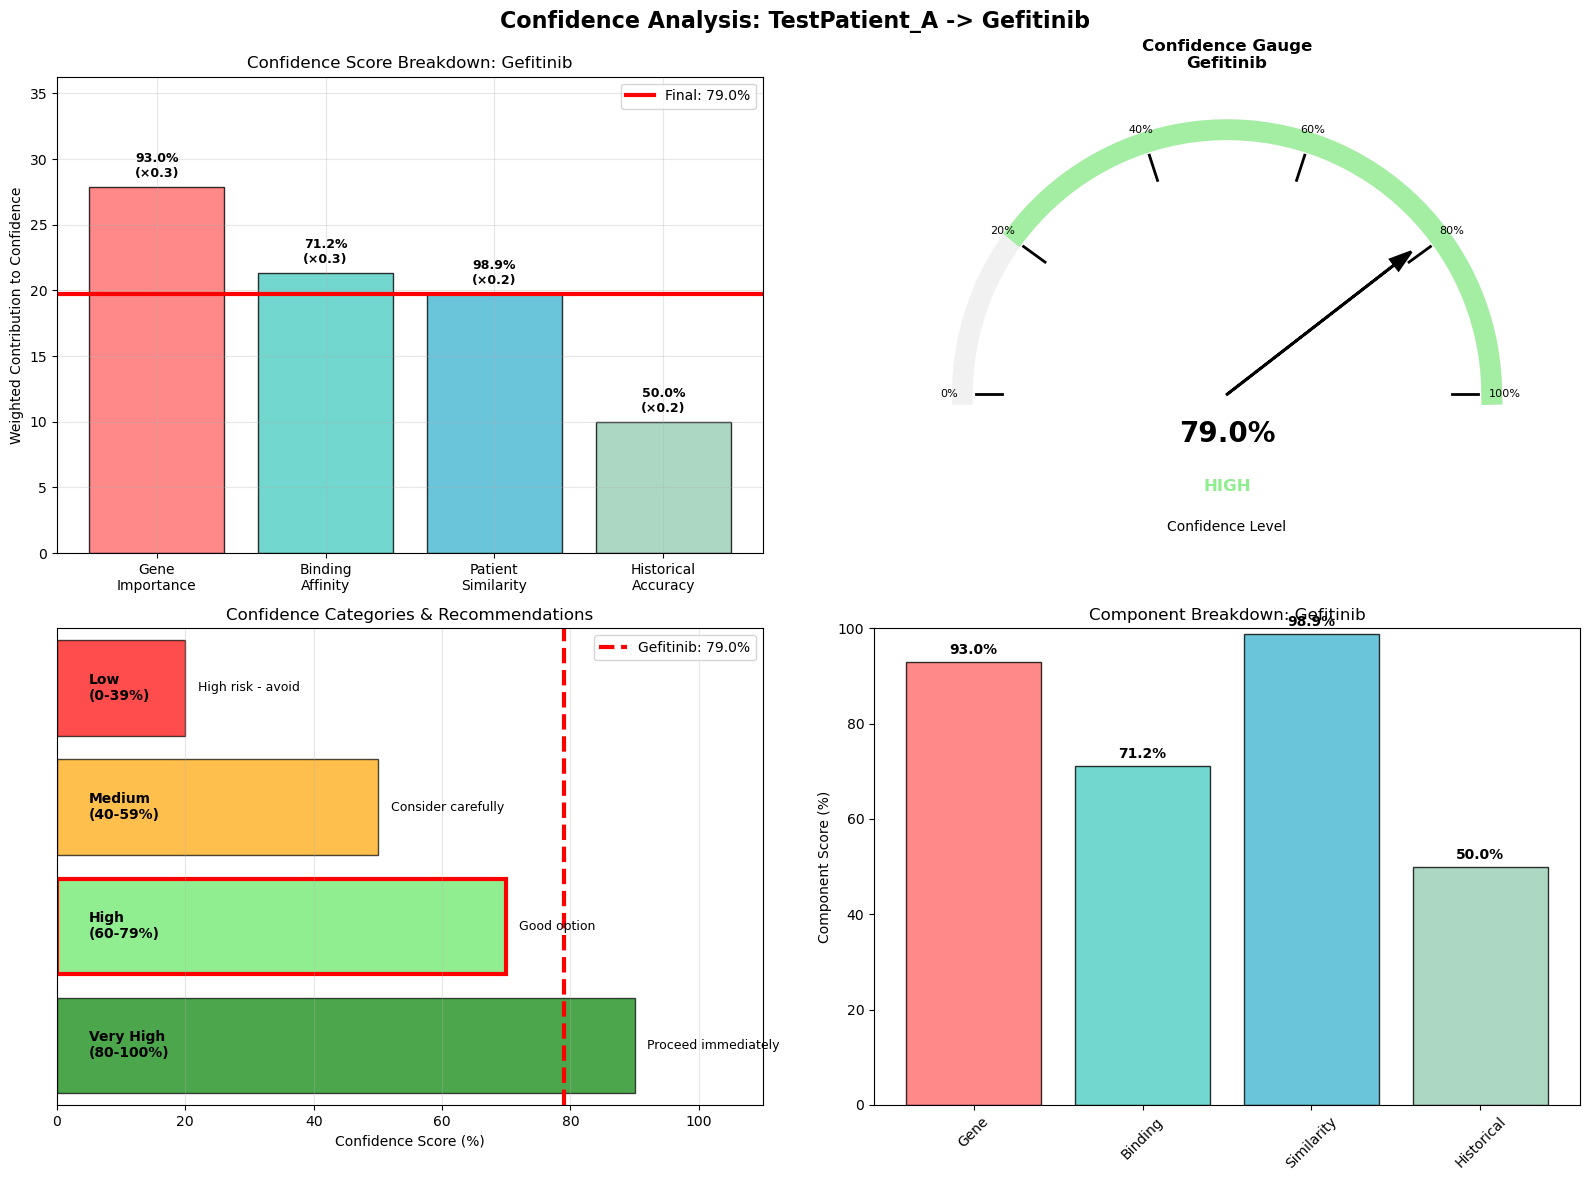


CALCULATING CONFIDENCE FOR: Dasatinib
Gene Importance: 3.10 -> 93.0%
Binding Affinity: -8.80 -> 88.0%
Patient Similarity: 0.960 -> 96.0%
Historical Accuracy: 50.0%

FINAL CONFIDENCE SCORE: 83.5%
Confidence analysis saved: analysis_results/confidence_analysis_TestPatient_A_Dasatinib.png


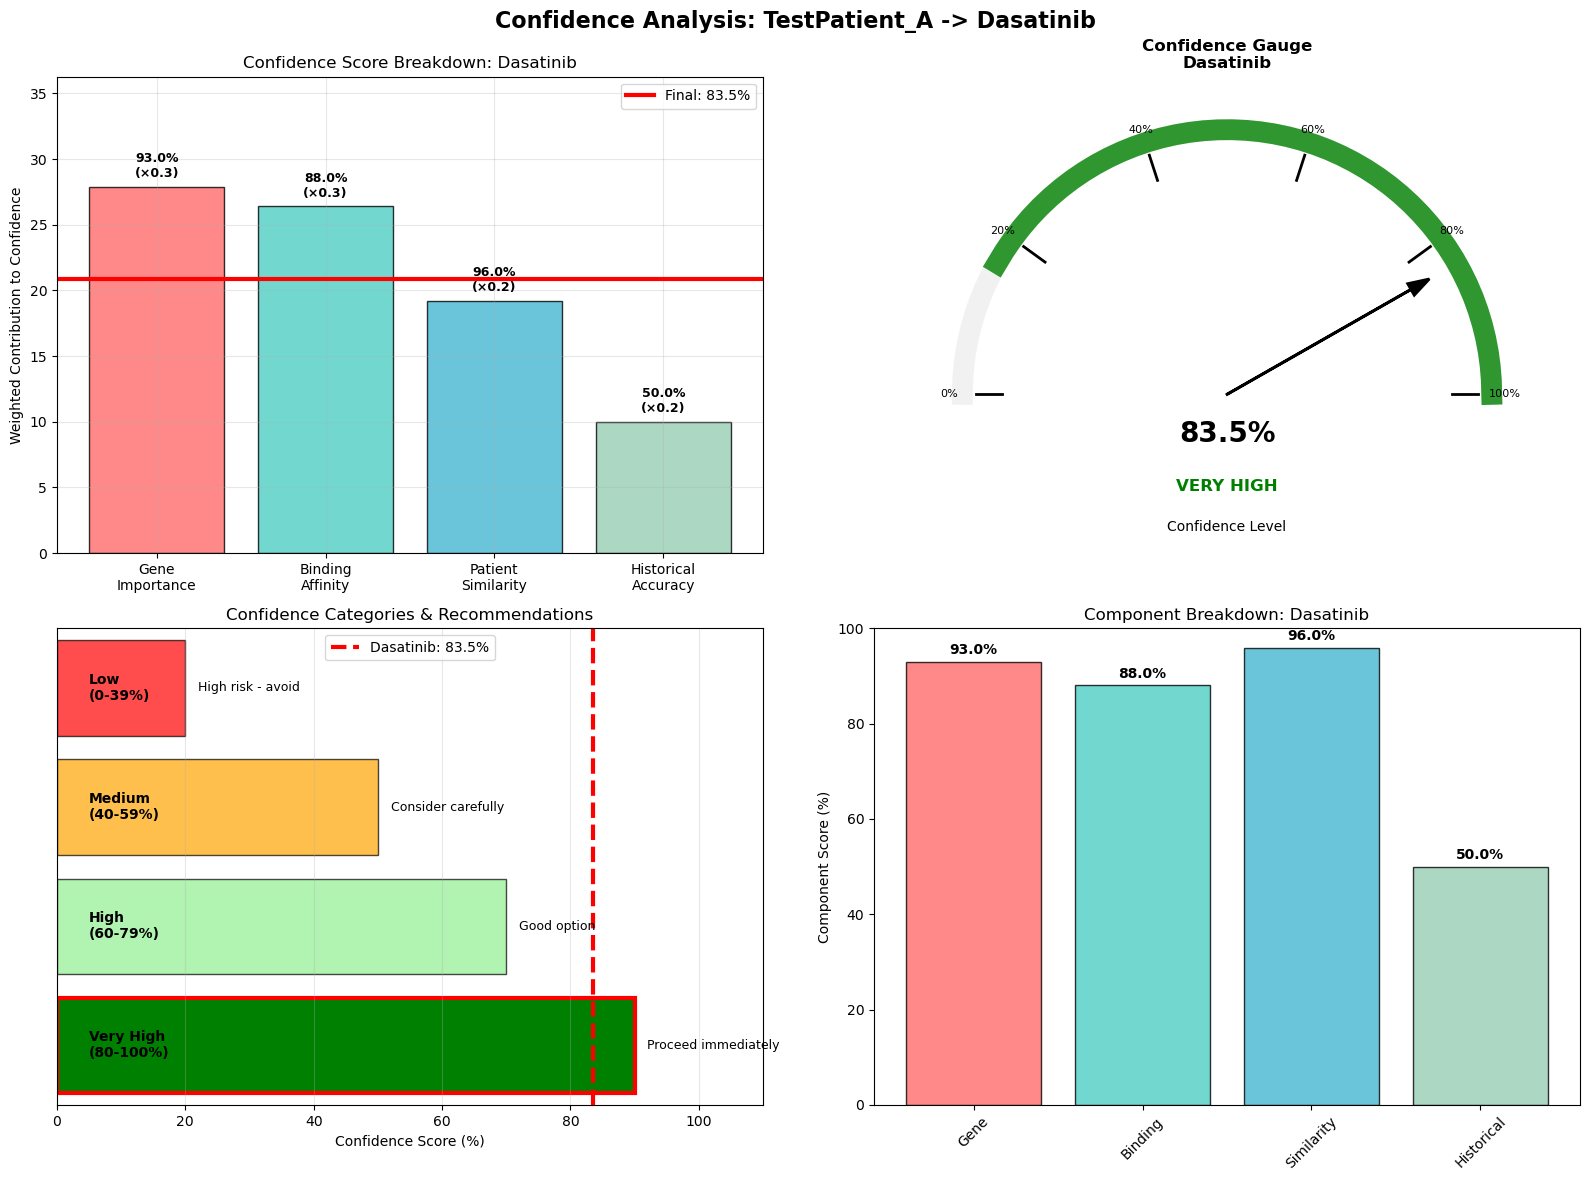


CALCULATING CONFIDENCE FOR: Imatinib
Gene Importance: 3.10 -> 93.0%
Binding Affinity: -7.95 -> 79.5%
Patient Similarity: 0.866 -> 86.6%
Historical Accuracy: 50.0%

FINAL CONFIDENCE SCORE: 79.1%
Confidence analysis saved: analysis_results/confidence_analysis_TestPatient_A_Imatinib.png


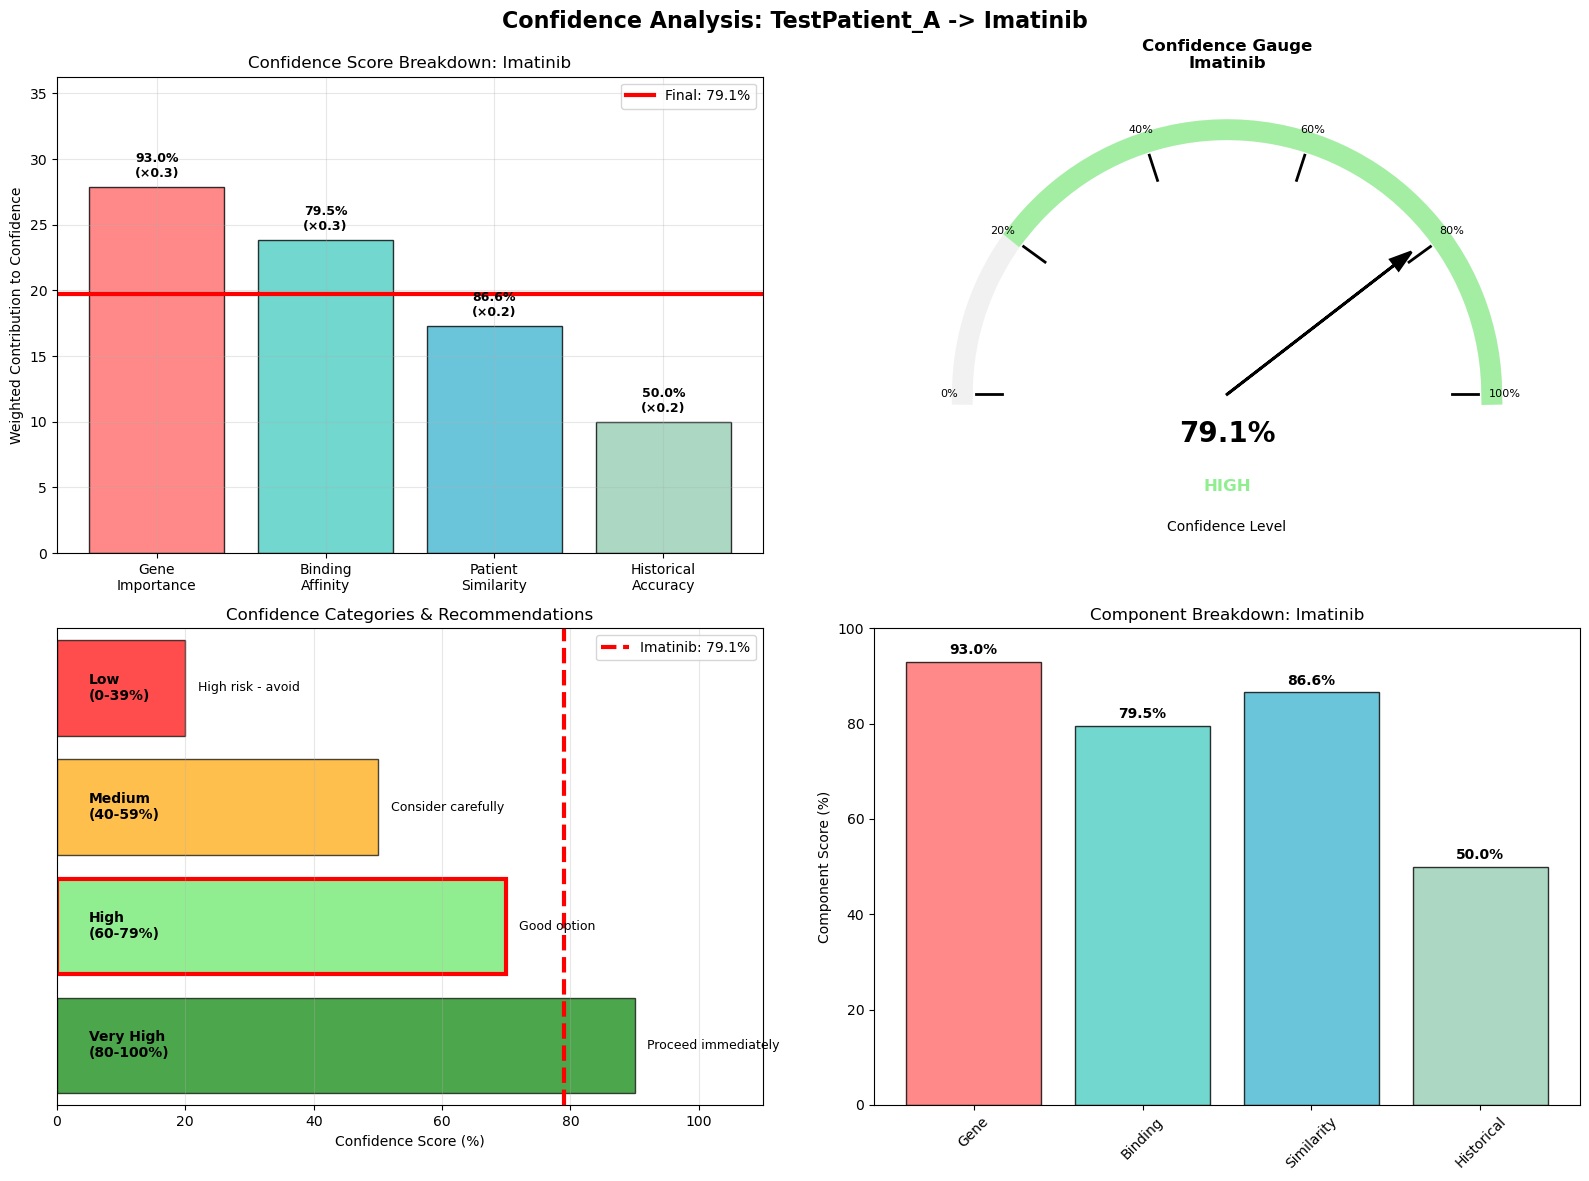


FINAL TREATMENT RECOMMENDATIONS FOR: TestPatient_A

1. Dasatinib - Very High Confidence (83.5%)
------------------------------------------------------------
   Recommendation: Strongly recommended - Proceed with treatment
   Risk Level: Low Risk
   Gene Importance: 3.10
   Binding Affinity: -8.80 kcal/mol
   Patient Similarity: 0.960
   Supporting Evidence: 1 patients (Patient_004)

2. Imatinib - High Confidence (79.1%)
------------------------------------------------------------
   Recommendation: Recommended - Good treatment option
   Risk Level: Medium Risk
   Gene Importance: 3.10
   Binding Affinity: -7.95 kcal/mol
   Patient Similarity: 0.866
   Supporting Evidence: 2 patients (Patient_002, Patient_005)

3. Gefitinib - High Confidence (79.0%)
------------------------------------------------------------
   Recommendation: Recommended - Good treatment option
   Risk Level: Medium Risk
   Gene Importance: 3.10
   Binding Affinity: -7.12 kcal/mol
   Patient Similarity: 0.989
   Supp

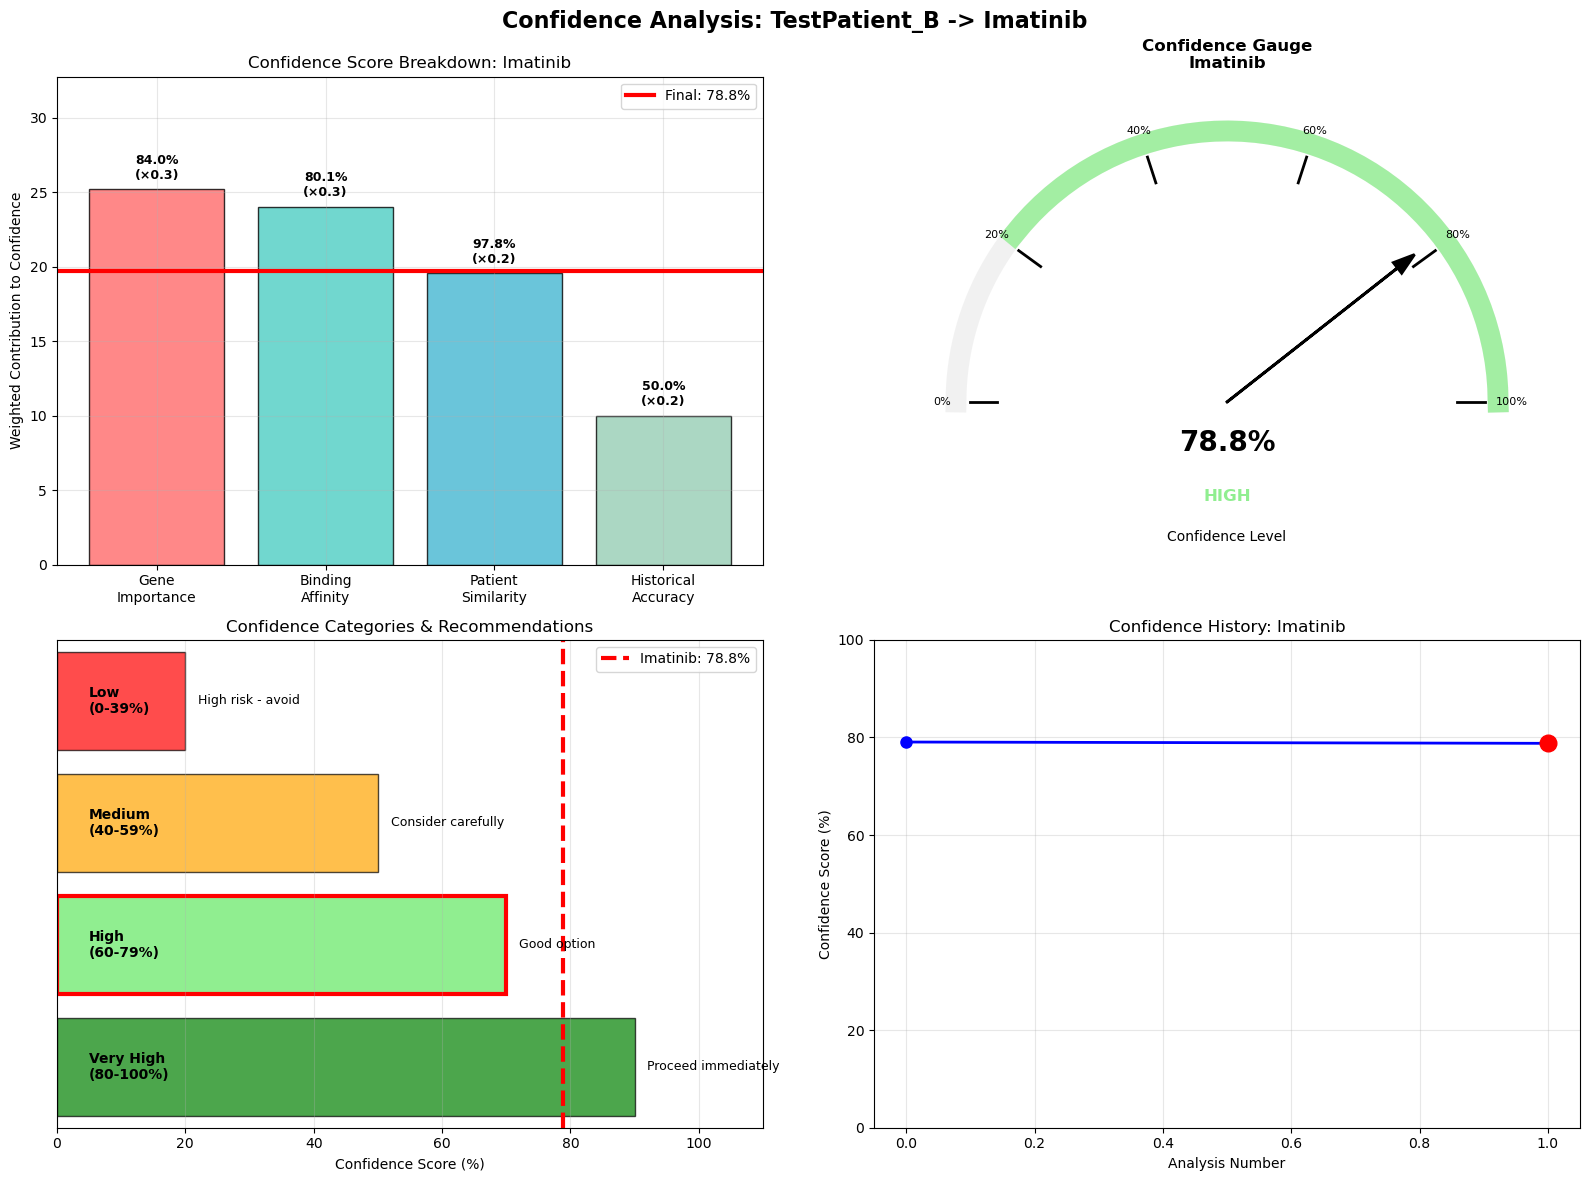


CALCULATING CONFIDENCE FOR: Dasatinib
Gene Importance: 2.80 -> 84.0%
Binding Affinity: -6.31 -> 63.1%
Patient Similarity: 0.966 -> 96.6%
Historical Accuracy: 50.0%

FINAL CONFIDENCE SCORE: 73.5%
Confidence analysis saved: analysis_results/confidence_analysis_TestPatient_B_Dasatinib.png


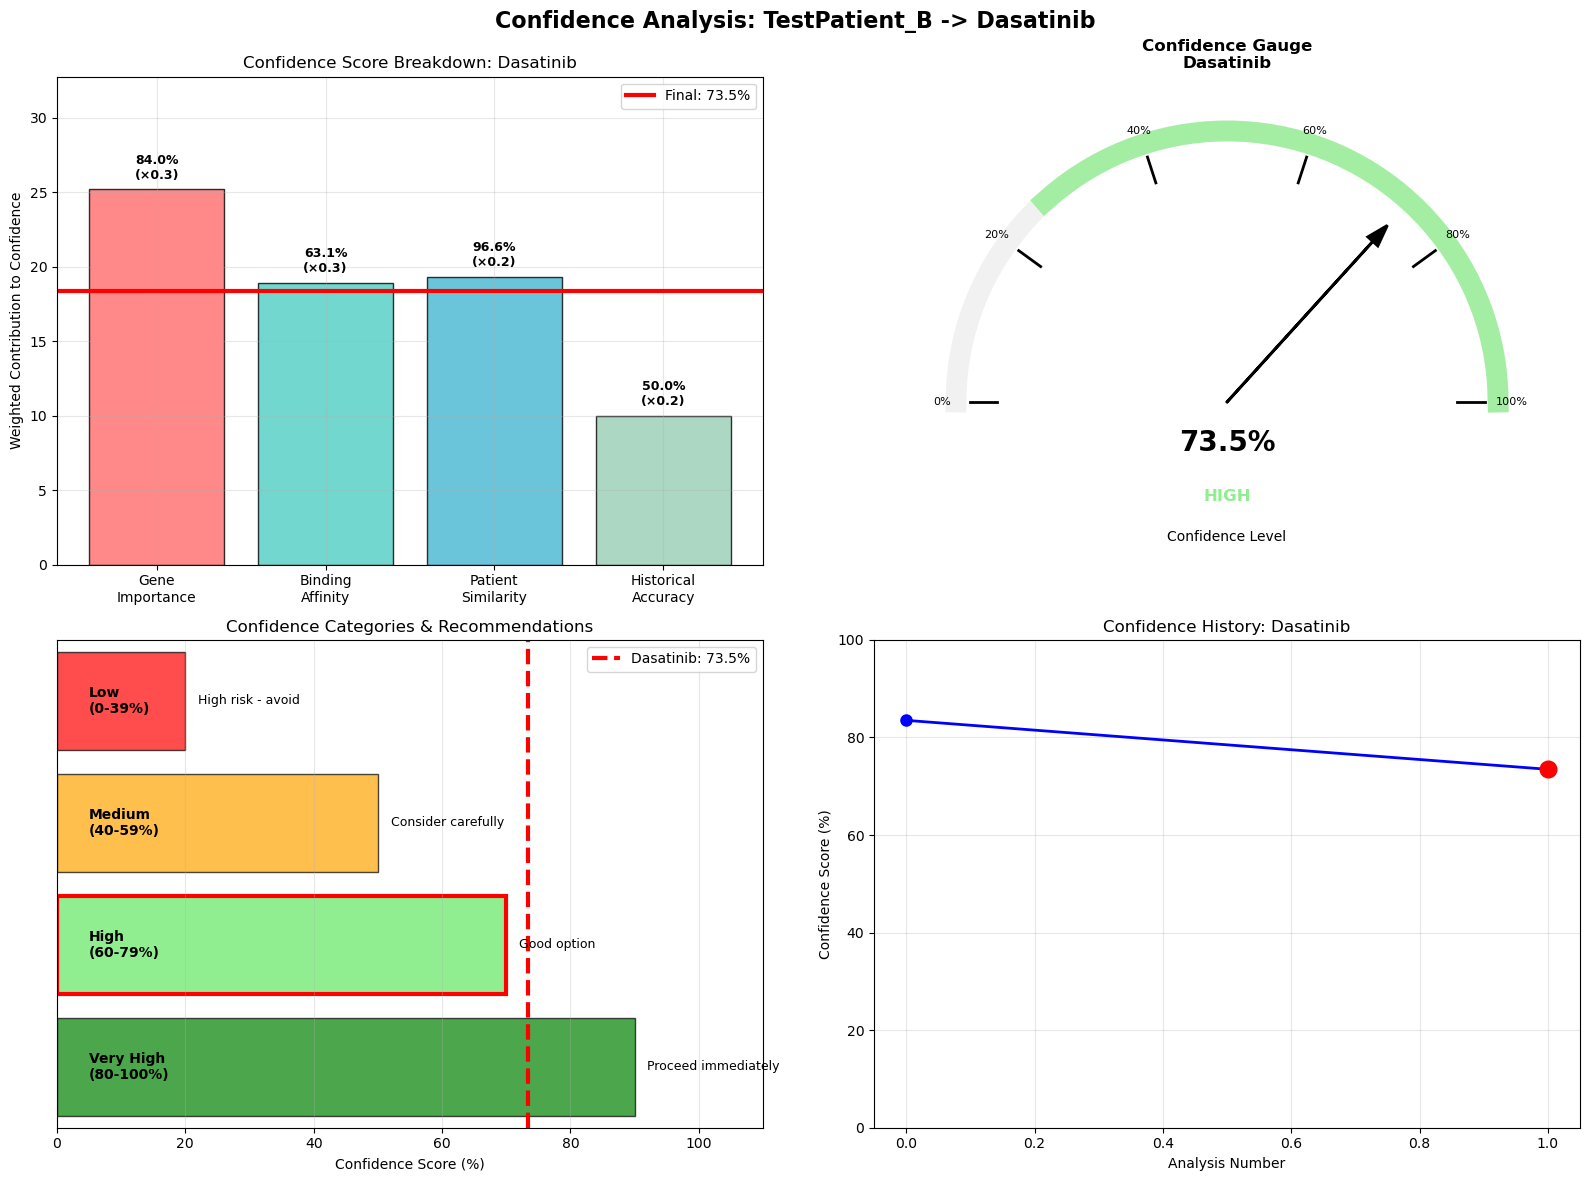


CALCULATING CONFIDENCE FOR: Gefitinib
Gene Importance: 2.80 -> 84.0%
Binding Affinity: -8.69 -> 86.9%
Patient Similarity: 0.845 -> 84.5%
Historical Accuracy: 50.0%

FINAL CONFIDENCE SCORE: 78.2%
Confidence analysis saved: analysis_results/confidence_analysis_TestPatient_B_Gefitinib.png


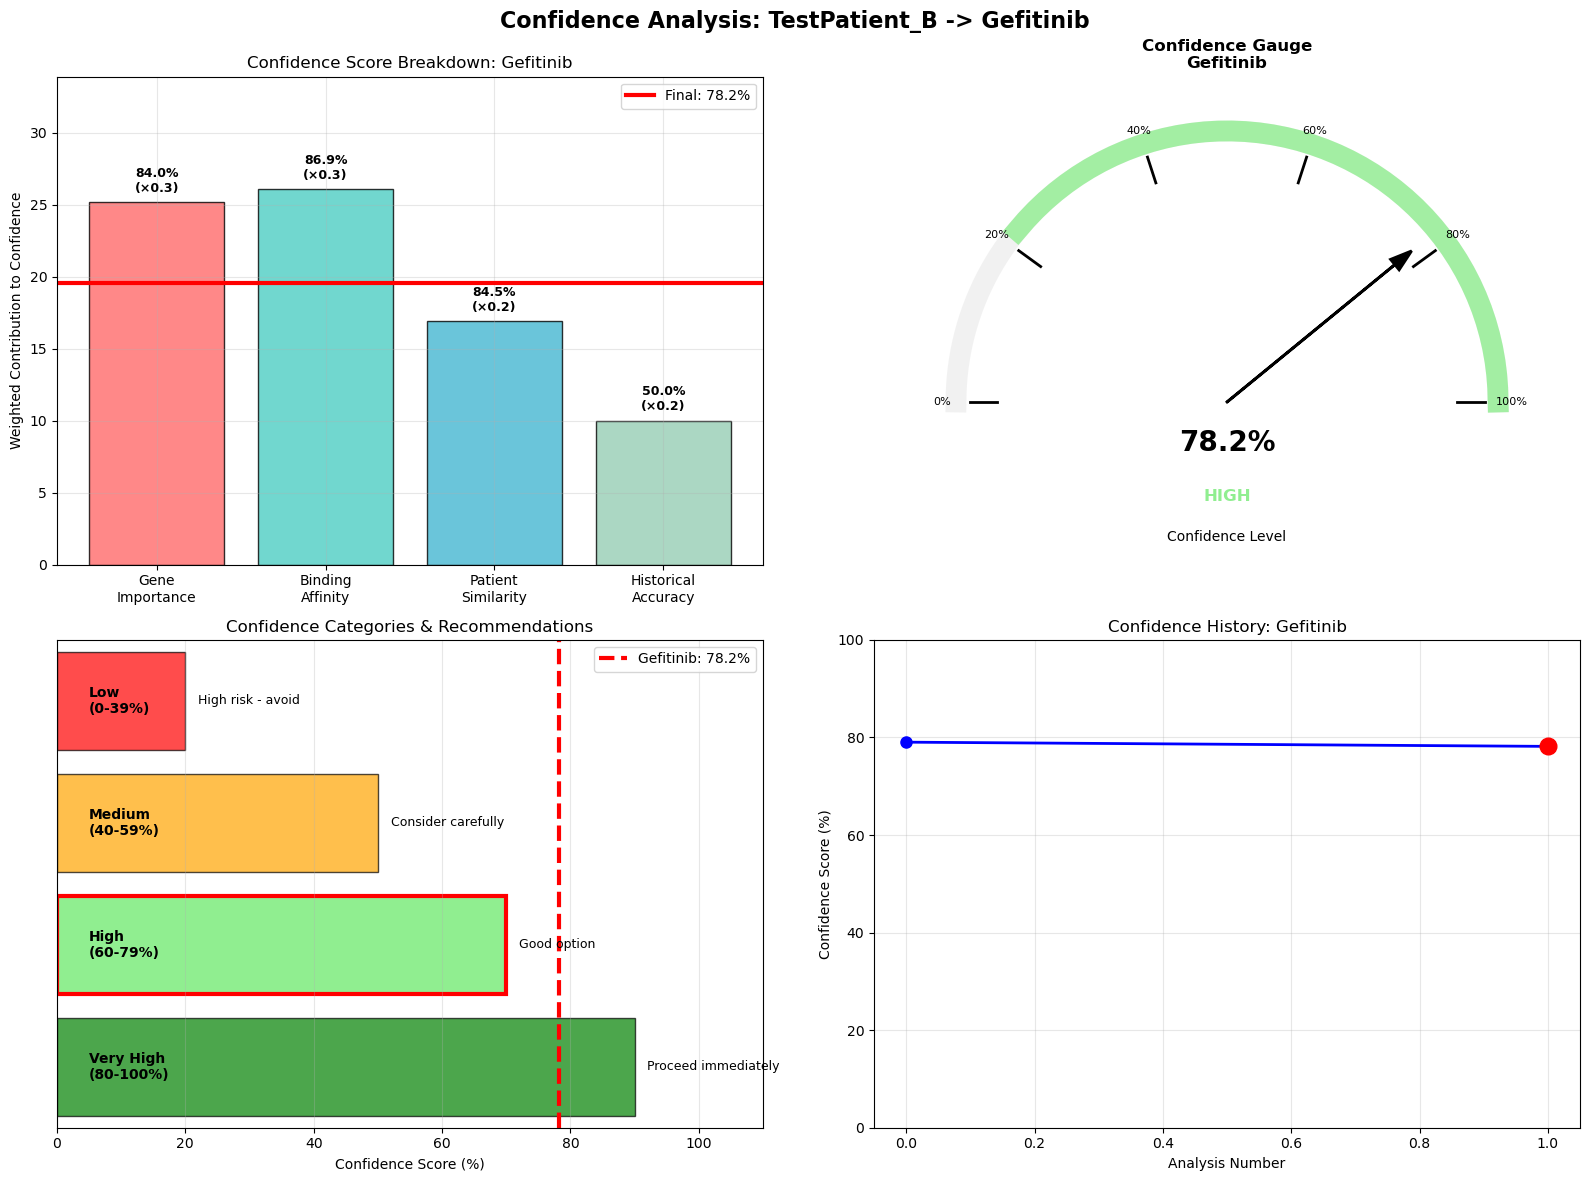


FINAL TREATMENT RECOMMENDATIONS FOR: TestPatient_B

1. Imatinib - High Confidence (78.8%)
------------------------------------------------------------
   Recommendation: Recommended - Good treatment option
   Risk Level: Medium Risk
   Gene Importance: 2.80
   Binding Affinity: -8.01 kcal/mol
   Patient Similarity: 0.978
   Supporting Evidence: 2 patients (Patient_002, Patient_005)

2. Gefitinib - High Confidence (78.2%)
------------------------------------------------------------
   Recommendation: Recommended - Good treatment option
   Risk Level: Medium Risk
   Gene Importance: 2.80
   Binding Affinity: -8.69 kcal/mol
   Patient Similarity: 0.845
   Supporting Evidence: 2 patients (Patient_001, Patient_003)

3. Dasatinib - High Confidence (73.5%)
------------------------------------------------------------
   Recommendation: Recommended - Good treatment option
   Risk Level: Medium Risk
   Gene Importance: 2.80
   Binding Affinity: -6.31 kcal/mol
   Patient Similarity: 0.966
   Sup

In [5]:
#!/usr/bin/env python3
"""
CHUNK 4: Confidence Scoring System
Adds a multi-factor confidence scoring system with visualization.
Save as: chunk4_confidence_system.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from chunk3_similarity_engine import SimilarityEngine

class ConfidenceSystem(SimilarityEngine):
    """Digital twin with confidence scoring capabilities."""
    
    def __init__(self):
        super().__init__()
        print("Confidence System Module Loaded")
        
        # Define weights for the four confidence factors
        self.confidence_weights = {
            'gene_importance': 0.3,
            'binding_affinity': 0.3,
            'similarity_score': 0.2,
            'historical_accuracy': 0.2
        }
        
        # Historical accuracy tracking for each drug
        self.drug_confidence_history = {}
        self.confidence_records = []
    
    def calculate_confidence_score(self, gene_importance, binding_affinity, similarity_score, drug_name):
        """
        Calculates a multi-factor confidence score for a given treatment.

        Args:
            gene_importance (float): A measure of the importance of the patient's gene profile.
            binding_affinity (float): A simulated measure of the drug's binding affinity.
            similarity_score (float): The similarity score of the patient to others in the database.
            drug_name (str): The name of the drug being recommended.

        Returns:
            tuple: The final confidence score and a detailed record of the components.
        """
        
        print(f"\nCALCULATING CONFIDENCE FOR: {drug_name}")
        print("="*50)
        
        # Component 1: Gene importance score (0-100)
        gene_confidence = min(100, gene_importance * 30)
        print(f"Gene Importance: {gene_importance:.2f} -> {gene_confidence:.1f}%")
        
        # Component 2: Binding affinity score (0-100). Higher (more negative) is better.
        binding_confidence = min(100, abs(binding_affinity) * 10)
        print(f"Binding Affinity: {binding_affinity:.2f} -> {binding_confidence:.1f}%")
        
        # Component 3: Similarity score (0-100)
        similarity_confidence = similarity_score * 100
        print(f"Patient Similarity: {similarity_score:.3f} -> {similarity_confidence:.1f}%")
        
        # Component 4: Historical accuracy (0-100). Default is 50%.
        historical_confidence = self.drug_confidence_history.get(drug_name, 50)
        print(f"Historical Accuracy: {historical_confidence:.1f}%")
        
        # Calculate the weighted combination of all components
        components = [gene_confidence, binding_confidence, similarity_confidence, historical_confidence]
        weights = list(self.confidence_weights.values())
        
        final_confidence = sum(w * c for w, c in zip(weights, components))
        final_confidence = min(100, max(0, final_confidence))
        
        print(f"\nFINAL CONFIDENCE SCORE: {final_confidence:.1f}%")
        
        # Store a detailed record of this confidence calculation
        confidence_record = {
            'drug_name': drug_name,
            'gene_confidence': gene_confidence,
            'binding_confidence': binding_confidence,
            'similarity_confidence': similarity_confidence,
            'historical_confidence': historical_confidence,
            'final_confidence': final_confidence,
            'timestamp': pd.Timestamp.now().isoformat()
        }
        
        self.confidence_records.append(confidence_record)
        
        return final_confidence, confidence_record
    
    def create_confidence_visualization(self, confidence_record, patient_id="Patient"):
        """
        Creates a detailed multi-panel visualization of the confidence score breakdown.
        
        Args:
            confidence_record (dict): A dictionary containing the confidence scores and their components.
            patient_id (str): The ID of the patient being analyzed.
        """
        
        drug_name = confidence_record['drug_name']
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Confidence component breakdown
        components = ['Gene\nImportance', 'Binding\nAffinity', 'Patient\nSimilarity', 'Historical\nAccuracy']
        values = [
            confidence_record['gene_confidence'],
            confidence_record['binding_confidence'],
            confidence_record['similarity_confidence'],
            confidence_record['historical_confidence']
        ]
        weights = list(self.confidence_weights.values())
        weighted_values = [v * w for v, w in zip(values, weights)]
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        
        bars = ax1.bar(components, weighted_values, color=colors, alpha=0.8, edgecolor='black')
        ax1.set_ylabel('Weighted Contribution to Confidence')
        ax1.set_title(f'Confidence Score Breakdown: {drug_name}')
        ax1.set_ylim(0, max(weighted_values) * 1.3)
        
        # Add value labels for the raw component scores and weights
        for bar, raw_val, weight in zip(bars, values, weights):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{raw_val:.1f}%\n(×{weight})', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Add a line to show the final confidence score
        final_conf = confidence_record['final_confidence']
        ax1.axhline(y=final_conf/4, color='red', linestyle='-', linewidth=3, 
                   label=f'Final: {final_conf:.1f}%')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Confidence gauge visualization
        self._draw_confidence_gauge(ax2, final_conf, drug_name)
        
        # Plot 3: Confidence category and recommendations
        self._draw_confidence_categories(ax3, final_conf, drug_name)
        
        # Plot 4: Historical confidence tracking or component breakdown
        self._draw_confidence_history(ax4, drug_name)
        
        plt.suptitle(f'Confidence Analysis: {patient_id} -> {drug_name}', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        # Save the visualization
        save_path = f'{self.results_dir}/confidence_analysis_{patient_id}_{drug_name}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Confidence analysis saved: {save_path}")
        
        plt.show()
        plt.close()
    
    def _draw_confidence_gauge(self, ax, confidence, drug_name):
        """Draws a confidence gauge visualization."""
        
        theta = np.linspace(0, np.pi, 100)
        ax.plot(np.cos(theta), np.sin(theta), 'lightgray', linewidth=15, alpha=0.3)
        
        # Color coding for confidence levels
        if confidence >= 80:
            color = 'green'
            label = 'VERY HIGH'
        elif confidence >= 60:
            color = 'lightgreen'
            label = 'HIGH'
        elif confidence >= 40:
            color = 'orange'
            label = 'MEDIUM'
        else:
            color = 'red'
            label = 'LOW'
        
        confidence_theta = np.linspace(0, np.pi * confidence/100, 50)
        ax.plot(np.cos(confidence_theta), np.sin(confidence_theta), color, linewidth=15, alpha=0.8)
        
        # Draw the needle
        needle_angle = np.pi * (1 - confidence/100)
        ax.arrow(0, 0, 0.8*np.cos(needle_angle), 0.8*np.sin(needle_angle), 
                head_width=0.05, head_length=0.08, fc='black', ec='black', linewidth=2)
        
        # Add text labels for score, level, and title
        ax.text(0, -0.15, f'{confidence:.1f}%', ha='center', va='center', 
               fontsize=20, fontweight='bold')
        ax.text(0, -0.35, label, ha='center', va='center', 
               fontsize=12, color=color, fontweight='bold')
        ax.text(0, -0.5, 'Confidence Level', ha='center', va='center', fontsize=10)
        
        # Add gauge markings
        for i in range(0, 101, 20):
            angle = np.pi * (1 - i/100)
            x1, y1 = 0.85 * np.cos(angle), 0.85 * np.sin(angle)
            x2, y2 = 0.95 * np.cos(angle), 0.95 * np.sin(angle)
            ax.plot([x1, x2], [y1, y2], 'black', linewidth=2)
            ax.text(1.05 * np.cos(angle), 1.05 * np.sin(angle), f'{i}%', 
                   ha='center', va='center', fontsize=8)
        
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-0.6, 1.2)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(f'Confidence Gauge\n{drug_name}', fontweight='bold')
    
    def _draw_confidence_categories(self, ax, confidence, drug_name):
        """Draws confidence categories and recommendations for a treatment."""
        
        categories = [
            {'range': '80-100%', 'label': 'Very High', 'color': 'green', 'recommendation': 'Proceed immediately'},
            {'range': '60-79%', 'label': 'High', 'color': 'lightgreen', 'recommendation': 'Good option'},
            {'range': '40-59%', 'label': 'Medium', 'color': 'orange', 'recommendation': 'Consider carefully'},
            {'range': '0-39%', 'label': 'Low', 'color': 'red', 'recommendation': 'High risk - avoid'}
        ]
        
        # Determine the current category based on the confidence score
        if confidence >= 80:
            current_category = 0
        elif confidence >= 60:
            current_category = 1
        elif confidence >= 40:
            current_category = 2
        else:
            current_category = 3
        
        y_positions = range(len(categories))
        category_scores = [90, 70, 50, 20]  # Representative scores for each category
        
        bars = ax.barh(y_positions, category_scores, 
                      color=[cat['color'] for cat in categories], alpha=0.7, edgecolor='black')
        
        # Highlight the current category
        bars[current_category].set_alpha(1.0)
        bars[current_category].set_edgecolor('red')
        bars[current_category].set_linewidth(3)
        
        # Add labels
        for i, (cat, bar) in enumerate(zip(categories, bars)):
            # Category info
            ax.text(5, i, f"{cat['label']}\n({cat['range']})", va='center', fontweight='bold')
            # Recommendation
            ax.text(bar.get_width() + 2, i, cat['recommendation'], va='center', fontsize=9)
        
        # Add a line to show the exact confidence score position
        ax.plot([confidence, confidence], [-0.5, len(categories)-0.5], 'r--', linewidth=3, 
               label=f'{drug_name}: {confidence:.1f}%')
        
        ax.set_xlim(0, 110)
        ax.set_ylim(-0.5, len(categories)-0.5)
        ax.set_xlabel('Confidence Score (%)')
        ax.set_title('Confidence Categories & Recommendations')
        ax.set_yticks([])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='x')
    
    def _draw_confidence_history(self, ax, drug_name):
        """Draws a confidence history plot for a given drug."""
        
        drug_records = [r for r in self.confidence_records if r['drug_name'] == drug_name]
        
        if len(drug_records) > 1:
            # Multiple records - show trend
            confidences = [r['final_confidence'] for r in drug_records]
            times = range(len(confidences))
            
            ax.plot(times, confidences, 'bo-', linewidth=2, markersize=8)
            ax.set_xlabel('Analysis Number')
            ax.set_ylabel('Confidence Score (%)')
            ax.set_title(f'Confidence History: {drug_name}')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 100)
            
            # Add a trend line if there are enough data points
            if len(confidences) > 2:
                z = np.polyfit(times, confidences, 1)
                p = np.poly1d(z)
                ax.plot(times, p(times), "r--", alpha=0.8, label=f'Trend: {z[0]:+.1f}%/analysis')
                ax.legend()
            
            # Highlight the current analysis
            ax.plot(len(confidences)-1, confidences[-1], 'ro', markersize=12, 
                   label='Current Analysis')
            
        else:
            # Single record - show component breakdown
            if drug_records:
                record = drug_records[0]
                components = ['Gene', 'Binding', 'Similarity', 'Historical']
                values = [
                    record['gene_confidence'],
                    record['binding_confidence'], 
                    record['similarity_confidence'],
                    record['historical_confidence']
                ]
                
                ax.bar(components, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], 
                      alpha=0.8, edgecolor='black')
                ax.set_ylabel('Component Score (%)')
                ax.set_title(f'Component Breakdown: {drug_name}')
                ax.set_ylim(0, 100)
                plt.setp(ax.get_xticklabels(), rotation=45)
                
                for bar, val in zip(ax.patches, values):
                    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                           f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
            else:
                ax.text(0.5, 0.5, f'First Analysis\nfor {drug_name}', 
                       ha='center', va='center', transform=ax.transAxes, fontsize=12)
                ax.set_title('Confidence History')
    
    def update_drug_confidence(self, drug_name, was_successful):
        """Updates the historical confidence for a drug based on a treatment outcome."""
        
        print(f"\nUPDATING DRUG CONFIDENCE: {drug_name}")
        print("="*50)
        
        current_confidence = self.drug_confidence_history.get(drug_name, 50)
        
        # Update based on outcome
        if was_successful:
            new_confidence = min(95, current_confidence + 8)
            outcome_text = "SUCCESS - Confidence increased"
        else:
            new_confidence = max(5, current_confidence - 12)
            outcome_text = "FAILURE - Confidence decreased"
        
        self.drug_confidence_history[drug_name] = new_confidence
        
        print(f"Drug: {drug_name}")
        print(f"Outcome: {outcome_text}")
        print(f"Confidence: {current_confidence:.1f}% -> {new_confidence:.1f}%")
        print(f"Change: {new_confidence - current_confidence:+.1f}%")
        
        return new_confidence
    
    def predict_with_confidence(self, target_genes, target_patient_id="NewPatient"):
        """Makes a complete treatment prediction with confidence analysis and visualization."""
        
        print(f"\nCOMPLETE PREDICTION WITH CONFIDENCE: {target_patient_id}")
        print("="*60)
        
        # Step 1: Find similar patients
        similar_patients = self.find_similar_patients(target_genes, target_patient_id, show_visualization=False)
        
        # Step 2: Get treatment recommendations
        treatment_predictions = self.predict_treatment_from_similarity(target_genes, target_patient_id)
        
        if not treatment_predictions:
            print("No treatment predictions available")
            return None
        
        # Step 3: Calculate confidence for each recommendation
        final_recommendations = []
        
        for prediction in treatment_predictions:
            drug_name = prediction['treatment']
            
            # Calculate confidence factors
            gene_importance = max(target_genes)
            binding_affinity = np.random.uniform(-9, -6)
            similarity_score = prediction['avg_similarity']
            
            # Calculate confidence
            confidence_score, confidence_record = self.calculate_confidence_score(
                gene_importance, binding_affinity, similarity_score, drug_name
            )
            
            # Create a comprehensive recommendation dictionary
            recommendation = {
                'drug': drug_name,
                'confidence_score': confidence_score,
                'confidence_category': self._get_confidence_category(confidence_score),
                'gene_importance': gene_importance,
                'binding_affinity': binding_affinity,
                'similarity_score': similarity_score,
                'supporting_patients': prediction['supporting_patients'],
                'patient_list': prediction['patient_list'],
                'risk_assessment': self._assess_risk(confidence_score),
                'recommendation_text': self._generate_recommendation_text(confidence_score),
                'confidence_record': confidence_record
            }
            
            final_recommendations.append(recommendation)
            
            # Create individual confidence visualization
            self.create_confidence_visualization(confidence_record, target_patient_id)
        
        # Sort by confidence score
        final_recommendations.sort(key=lambda x: x['confidence_score'], reverse=True)
        
        # Display final recommendations
        self._display_final_recommendations(final_recommendations, target_patient_id)
        
        return final_recommendations
    
    def _get_confidence_category(self, confidence):
        """Returns a confidence category label based on the score."""
        if confidence >= 80:
            return "Very High"
        elif confidence >= 60:
            return "High"
        elif confidence >= 40:
            return "Medium"
        else:
            return "Low"
    
    def _assess_risk(self, confidence):
        """Assesses treatment risk based on a confidence score (Corrected Logic)."""
        if confidence >= 80:
            return "Low Risk"
        elif confidence >= 60:
            return "Medium Risk"
        elif confidence >= 40:
            return "High Risk"
        else:
            return "Very High Risk"
    
    def _generate_recommendation_text(self, confidence):
        """Generates a text recommendation based on a confidence score."""
        if confidence >= 80:
            return "Strongly recommended - Proceed with treatment"
        elif confidence >= 60:
            return "Recommended - Good treatment option"
        elif confidence >= 40:
            return "Consider carefully - Monitor closely if used"
        else:
            return "Not recommended - Seek alternative treatments"
    
    def _display_final_recommendations(self, recommendations, patient_id):
        """Displays a summary of final treatment recommendations."""
        
        print(f"\nFINAL TREATMENT RECOMMENDATIONS FOR: {patient_id}")
        print("="*70)
        
        for i, rec in enumerate(recommendations, 1):
            print(f"\n{i}. {rec['drug']} - {rec['confidence_category']} Confidence ({rec['confidence_score']:.1f}%)")
            print("-" * 60)
            print(f"   Recommendation: {rec['recommendation_text']}")
            print(f"   Risk Level: {rec['risk_assessment']}")
            print(f"   Gene Importance: {rec['gene_importance']:.2f}")
            print(f"   Binding Affinity: {rec['binding_affinity']:.2f} kcal/mol")
            print(f"   Patient Similarity: {rec['similarity_score']:.3f}")
            print(f"   Supporting Evidence: {rec['supporting_patients']} patients ({', '.join(rec['patient_list'])})")
        
        print("\n" + "="*70)
        
        top_rec = recommendations[0]
        if top_rec['confidence_score'] >= 70:
            print(f"RECOMMENDED TREATMENT: {top_rec['drug']} ({top_rec['confidence_score']:.1f}% confidence)")
        elif top_rec['confidence_score'] >= 50:
            print(f"CONSIDER TREATMENT: {top_rec['drug']} ({top_rec['confidence_score']:.1f}% confidence) - Monitor closely")
        else:
            print(f"NO STRONG RECOMMENDATION - All options below 50% confidence")
            print("   Recommend: Seek additional testing or alternative approaches")


def test_confidence_system():
    """Tests the confidence scoring system's core functionalities."""
    
    print("TESTING CONFIDENCE SCORING SYSTEM")
    print("="*60)
    
    confidence_system = ConfidenceSystem()
    
    print("\nAdding Training Patients:")
    
    training_patients = [
        ('Patient_001', [2.8, 3.2, 1.5, 1.1, 1.3], 'Gefitinib'),
        ('Patient_002', [2.1, 1.8, 1.4, 2.9, 2.3], 'Imatinib'),
        ('Patient_003', [1.9, 3.0, 2.1, 1.2, 1.1], 'Gefitinib'),
        ('Patient_004', [2.6, 2.8, 1.3, 2.4, 2.1], 'Dasatinib'),
        ('Patient_005', [1.7, 1.5, 2.2, 1.9, 2.8], 'Imatinib'),
    ]
    
    for patient_id, genes, treatment in training_patients:
        confidence_system.add_patient(patient_id, genes, treatment)
    
    print(f"Added {len(training_patients)} training patients")
    
    print("\nTesting Complete Prediction with Confidence:")
    
    new_patient_genes1 = [2.7, 3.1, 1.6, 1.2, 1.4]
    recommendations1 = confidence_system.predict_with_confidence(new_patient_genes1, "TestPatient_A")
    
    print("\n" + "="*60)
    new_patient_genes2 = [2.0, 1.7, 1.3, 2.8, 2.4]
    recommendations2 = confidence_system.predict_with_confidence(new_patient_genes2, "TestPatient_B")
    
    print("\nSimulating Learning from Treatment Outcomes:")
    
    if recommendations1:
        top_drug1 = recommendations1[0]['drug']
        success1 = recommendations1[0]['confidence_score'] > 60
        confidence_system.update_drug_confidence(top_drug1, success1)
    
    if recommendations2:
        top_drug2 = recommendations2[0]['drug']
        success2 = recommendations2[0]['confidence_score'] > 60
        confidence_system.update_drug_confidence(top_drug2, success2)
    
    print("\nCONFIDENCE SYSTEM TEST COMPLETE!")
    print("Next: Run Chunk 5 for Learning System")
    
    return confidence_system

if __name__ == "__main__":
    confidence_system = test_confidence_system()
    
    print("\n" + "="*60)
    print("CHUNK 4 COMPLETED SUCCESSFULLY!")
    print("="*60)
    print("Confidence scoring system working")
    print("Multi-factor confidence calculation")
    print("Confidence visualization with gauges")
    print("Risk assessment and recommendations")
    print("Historical confidence tracking")
    
    print(f"\nCheck your results in: analysis_results/")
    print("Ready for Chunk 5: Learning System!")

Successfully imported ConfidenceSystem
TESTING ADAPTIVE LEARNING SYSTEM
Initializing Basic Digital Twin System
System initialized
Results directory: analysis_results/
Patient Analyzer Module Loaded
Similarity Engine Module Loaded
Confidence System Module Loaded
Adaptive Learning System Module Loaded

Adding Basic Patients:

Adding Patient: Patient_001
Gene Expression: [2.8, 3.2, 1.5, 1.1, 1.3]
Treatment Outcome: Gefitinib
Patient Patient_001 added successfully

Gene Expression Profile for Patient_001:
----------------------------------------
TP53: 2.8x (HIGH)
EGFR: 3.2x (HIGH)
BRCA1: 1.5x (NORMAL)
MYC: 1.1x (NORMAL)
RAS: 1.3x (NORMAL)
----------------------------------------

Adding Patient: Patient_002
Gene Expression: [2.1, 1.8, 1.4, 2.9, 2.3]
Treatment Outcome: Imatinib
Patient Patient_002 added successfully

Gene Expression Profile for Patient_002:
----------------------------------------
TP53: 2.1x (HIGH)
EGFR: 1.8x (NORMAL)
BRCA1: 1.4x (NORMAL)
MYC: 2.9x (HIGH)
RAS: 2.3x (HIGH)
-

/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:235: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:239: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


Learning visualization saved: analysis_results/learning_update_Patient_001.png


/Users/donu/miniconda3/envs/twin/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


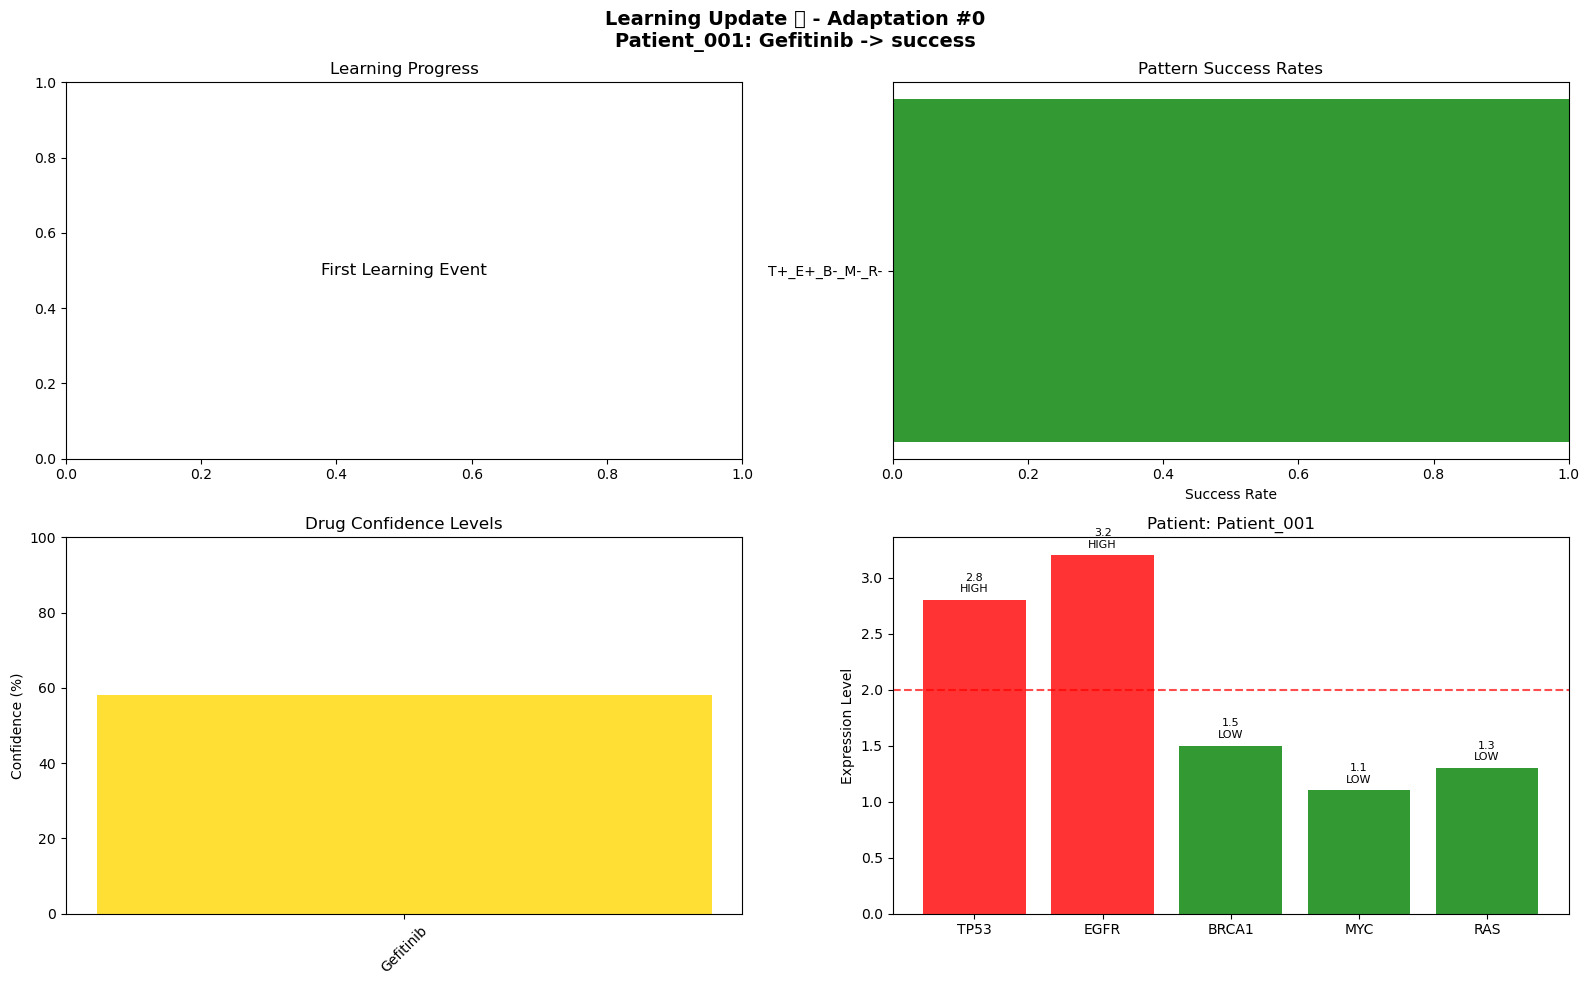

System adapted (Adaptation #1)
Learning successful

--- Learning from Patient_002 ---

LEARNING FROM TREATMENT OUTCOME
Patient: Patient_002
Drug: Imatinib
Outcome: success
Pattern: TP53_MED_EGFR_MED_BRCA1_LOW_MYC_HIGH_RAS_MED
Pattern memory updated:
  Success rate: 100.00%
  Total attempts: 1
Confidence updated: 50.0% -> 58.0%


/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:235: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:239: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


Learning visualization saved: analysis_results/learning_update_Patient_002.png


/Users/donu/miniconda3/envs/twin/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


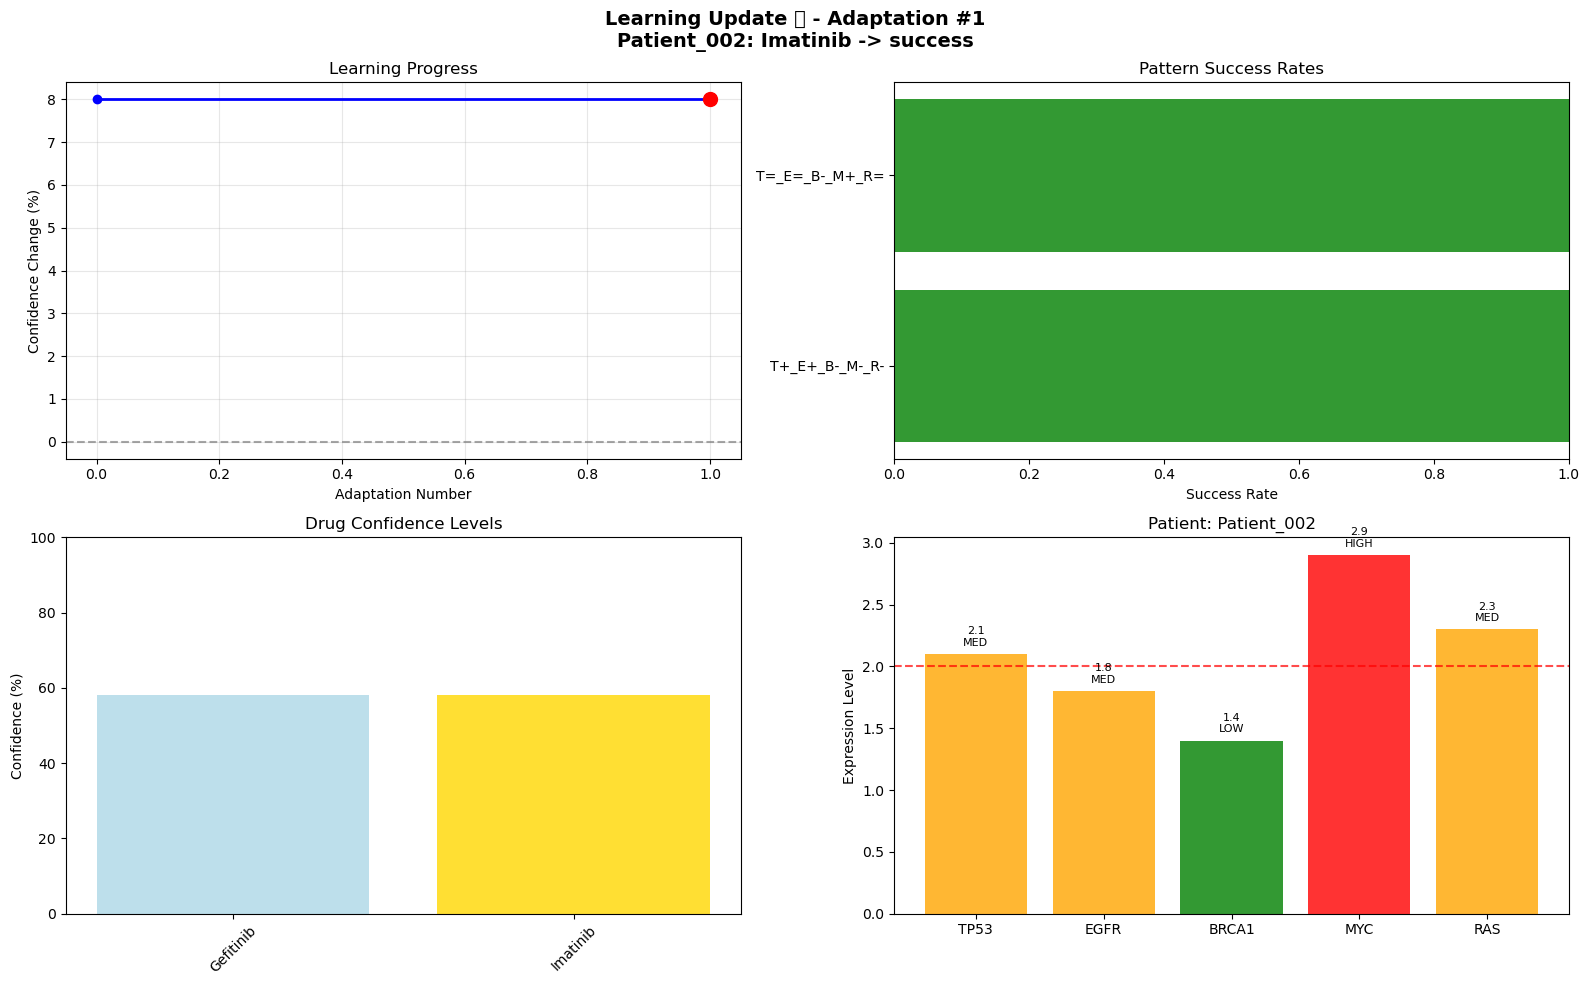

System adapted (Adaptation #2)
Learning successful

--- Learning from Patient_004 ---

LEARNING FROM TREATMENT OUTCOME
Patient: Patient_004
Drug: Gefitinib
Outcome: success
Pattern: TP53_HIGH_EGFR_HIGH_BRCA1_MED_MYC_LOW_RAS_LOW
Pattern memory updated:
  Success rate: 100.00%
  Total attempts: 1
Confidence updated: 58.0% -> 66.0%


/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:235: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:239: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


Learning visualization saved: analysis_results/learning_update_Patient_004.png


/Users/donu/miniconda3/envs/twin/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


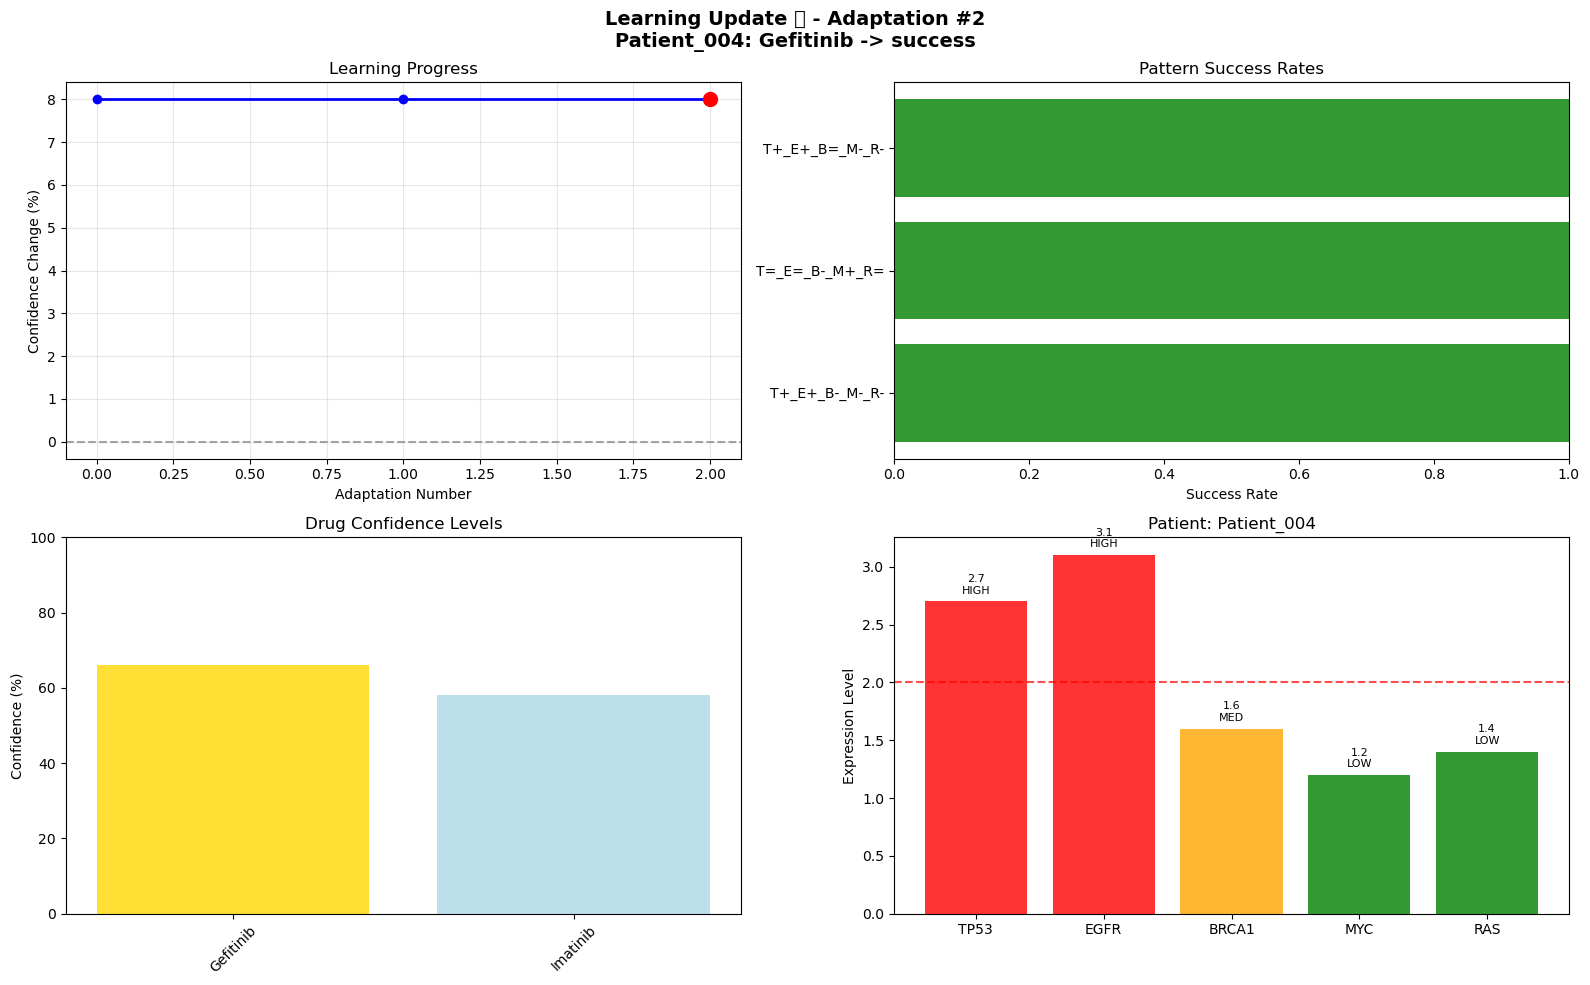

System adapted (Adaptation #3)
Learning successful

--- Learning from Patient_005 ---

LEARNING FROM TREATMENT OUTCOME
Patient: Patient_005
Drug: Imatinib
Outcome: failure
Pattern: TP53_MED_EGFR_MED_BRCA1_LOW_MYC_HIGH_RAS_MED
Pattern memory updated:
  Success rate: 50.00%
  Total attempts: 2
Confidence updated: 58.0% -> 46.0%


/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:235: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/var/folders/gj/jsxnqpk552q0kgnhtby2hql40000gn/T/ipykernel_3239/3462912961.py:239: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


Learning visualization saved: analysis_results/learning_update_Patient_005.png


/Users/donu/miniconda3/envs/twin/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


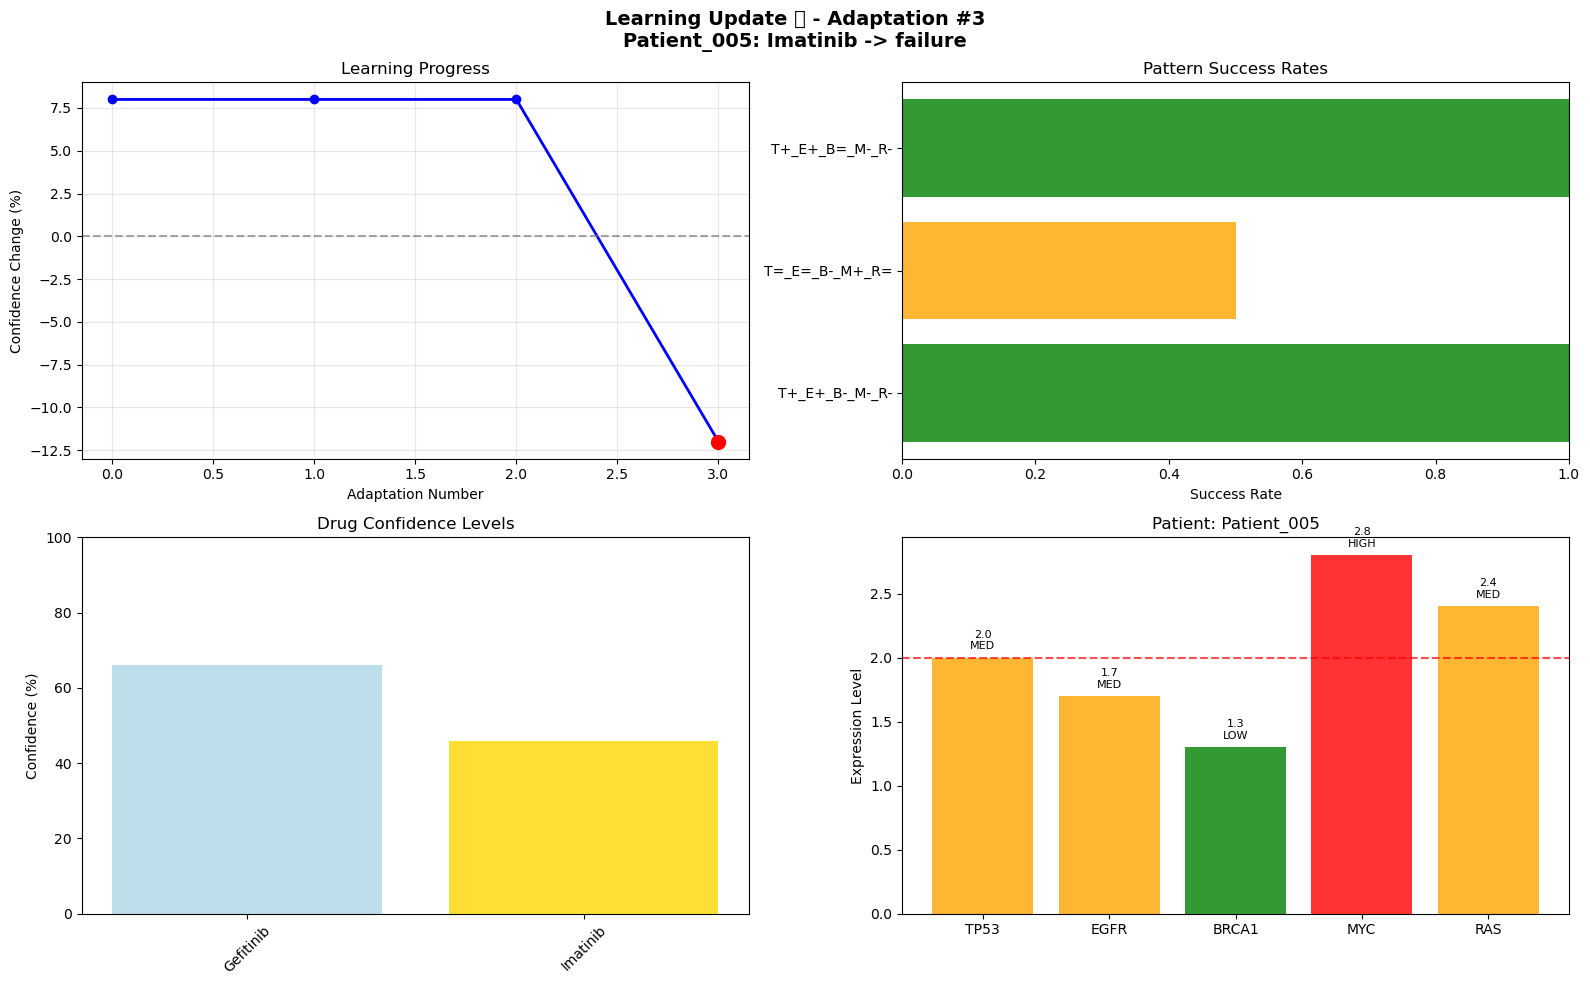

System adapted (Adaptation #4)
Learning successful

Testing Adaptive Prediction:

ADAPTIVE PREDICTION FOR: AdaptiveTest_A
Target Pattern: TP53_HIGH_EGFR_HIGH_BRCA1_MED_MYC_LOW_RAS_LOW
Found exact pattern match!
  Success rate: 100.00%
  Total attempts: 1

ADAPTIVE RECOMMENDATIONS FOR: AdaptiveTest_A
Pattern: TP53_HIGH_EGFR_HIGH_BRCA1_MED_MYC_LOW_RAS_LOW

1. Gefitinib - 100.0% Confidence
  Strategy: Exact Match
  Evidence: Exact pattern match (1/1 success)
  STRONGLY RECOMMENDED



ADAPTIVE PREDICTION FOR: AdaptiveTest_B
Target Pattern: TP53_MED_EGFR_MED_BRCA1_LOW_MYC_HIGH_RAS_MED
Found exact pattern match!
  Success rate: 50.00%
  Total attempts: 2

ADAPTIVE RECOMMENDATIONS FOR: AdaptiveTest_B
Pattern: TP53_MED_EGFR_MED_BRCA1_LOW_MYC_HIGH_RAS_MED

1. Imatinib - 50.0% Confidence
  Strategy: Exact Match
  Evidence: Exact pattern match (1/2 success)
  LOW CONFIDENCE - CONSIDER ALTERNATIVES


Analyzing Learning Performance:

LEARNING PERFORMANCE ANALYSIS
Total Adaptations: 4
Successful Out

In [6]:
#!/usr/bin/env python3
"""
CHUNK 5: Fixed Adaptive Learning System
Adds adaptive learning with real-time visualization.

Save as: chunk5_learning_fixed.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Import from previous chunks with error handling for standalone testing
try:
    from chunk4_confidence_system import ConfidenceSystem
    print("Successfully imported ConfidenceSystem")
except ImportError as e:
    print(f"Import Error: {e}")
    print("Creating standalone version...")
    # Fallback to basic system if dependencies are not available
    from chunk1_basic_system import BasicDigitalTwin
    
    class ConfidenceSystem(BasicDigitalTwin):
        def __init__(self):
            super().__init__()
            self.confidence_weights = {'gene_importance': 0.3, 'binding_affinity': 0.3, 'similarity_score': 0.2, 'historical_accuracy': 0.2}
            self.drug_confidence_history = {}
            self.confidence_records = []
            print("Minimal Confidence System loaded")

class AdaptiveLearningSystem(ConfidenceSystem):
    """Digital twin with adaptive learning capabilities."""

    def __init__(self):
        super().__init__()
        print("Adaptive Learning System Module Loaded")

        # Learning components
        self.pattern_memory = {}
        self.learning_history = []
        self.success_patterns = {}
        self.failure_patterns = {}
        self.adaptation_count = 0
        # Define thresholds for pattern creation to ensure consistency
        self.pattern_thresholds = {'high': 2.5, 'med': 1.5}

    def learn_from_outcome(self, patient_genes, drug_recommended, actual_outcome, patient_id="Patient"):
        """Learns from a treatment outcome and adapts the system's knowledge."""

        print(f"\nLEARNING FROM TREATMENT OUTCOME")
        print("="*60)
        print(f"Patient: {patient_id}")
        print(f"Drug: {drug_recommended}")
        print(f"Outcome: {actual_outcome}")

        try:
            # Step 1: Create a pattern signature from the patient's genes
            pattern_signature = self._create_pattern_signature(patient_genes)
            print(f"Pattern: {pattern_signature}")

            # Step 2: Update the pattern memory with the new outcome
            self._update_pattern_memory(pattern_signature, drug_recommended, actual_outcome)

            # Step 3: Update the drug's general confidence based on a simple heuristic
            old_confidence = self.drug_confidence_history.get(drug_recommended, 50)
            if actual_outcome == 'success':
                new_confidence = min(95, old_confidence + 8)
            else:
                new_confidence = max(5, old_confidence - 12)
            
            self.drug_confidence_history[drug_recommended] = new_confidence
            print(f"Confidence updated: {old_confidence:.1f}% -> {new_confidence:.1f}%")
                         
            # Step 4: Record this learning event in the history
            learning_event = {
                'timestamp': datetime.now().isoformat(),
                'patient_id': patient_id,
                'pattern_signature': pattern_signature,
                'drug_recommended': drug_recommended,
                'actual_outcome': actual_outcome,
                'confidence_change': new_confidence - old_confidence,
                'adaptation_number': self.adaptation_count
            }

            self.learning_history.append(learning_event)
            self.adaptation_count += 1

            # Step 5: Visualize the learning process
            self._visualize_learning_process(learning_event, patient_genes)

            print(f"System adapted (Adaptation #{self.adaptation_count})")

            return learning_event

        except Exception as e:
            print(f"Error in learning process: {e}")
            return None
         
    def _create_pattern_signature(self, gene_expression):
        """Creates a unique pattern signature from gene expression levels.""" 
        genes = self.GENES
        signature_parts = []
        high_threshold = self.pattern_thresholds['high']
        med_threshold = self.pattern_thresholds['med']

        for i, expr in enumerate(gene_expression[:5]):
            gene_name = genes[i] if i < len(genes) else f'GENE_{i}'

            if expr > high_threshold:
                level = 'HIGH'
            elif expr > med_threshold:
                level = 'MED'
            else:
                level = 'LOW'
                         
            signature_parts.append(f"{gene_name}_{level}")
        return "_".join(signature_parts)
    
    def _update_pattern_memory(self, pattern_signature, drug, outcome):
        """Updates the system's pattern memory with a new outcome."""

        if pattern_signature not in self.pattern_memory:
            self.pattern_memory[pattern_signature] = {
                'success_drugs': [], 'failure_drugs': [], 'total_attempts': 0, 'success_rate': 0.0
            }
        
        pattern_data = self.pattern_memory[pattern_signature]
        pattern_data['total_attempts'] += 1

        if outcome == 'success':
            pattern_data['success_drugs'].append(drug)
            if pattern_signature not in self.success_patterns:
                self.success_patterns[pattern_signature] = []
            self.success_patterns[pattern_signature].append(drug)
        else:
            pattern_data['failure_drugs'].append(drug)
            if pattern_signature not in self.failure_patterns:
                self.failure_patterns[pattern_signature] = []
            self.failure_patterns[pattern_signature].append(drug)
        
        successes = len(pattern_data['success_drugs'])
        pattern_data['success_rate'] = successes / pattern_data['total_attempts']

        print(f"Pattern memory updated:")
        print(f"  Success rate: {pattern_data['success_rate']:.2%}")
        print(f"  Total attempts: {pattern_data['total_attempts']}")
    
    def _visualize_learning_process(self, learning_event, patient_genes):
        """Creates a visualization of the learning process."""
        
        try:
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
            
            # Plot 1: Learning progression line chart
            if len(self.learning_history) > 1:
                adaptations = [e['adaptation_number'] for e in self.learning_history]
                conf_changes = [e['confidence_change'] for e in self.learning_history]

                ax1.plot(adaptations, conf_changes, 'bo-', linewidth=2)
                ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
                ax1.set_xlabel('Adaptation Number')
                ax1.set_ylabel('Confidence Change (%)')
                ax1.set_title('Learning Progress')
                ax1.grid(True, alpha=0.3)

                current_change = learning_event['confidence_change']
                current_adaptation = learning_event['adaptation_number']
                ax1.plot(current_adaptation, current_change, 'ro', markersize=10)
            else:
                ax1.text(0.5, 0.5, 'First Learning Event', ha='center', va='center',
                        transform=ax1.transAxes, fontsize=12)
                ax1.set_title('Learning Progress')
            
            # Plot 2: Pattern success rates bar chart
            if self.pattern_memory:
                patterns = list(self.pattern_memory.keys())
                success_rates = [self.pattern_memory[p]['success_rate'] for p in patterns]

                simple_patterns = []
                for p in patterns:
                    simple = p.replace('_HIGH', '+').replace('_MED', '=').replace('_LOW', '-')
                    simple = simple.replace('TP53', 'T').replace('EGFR', 'E').replace('BRCA1', 'B')
                    simple = simple.replace('MYC', 'M').replace('RAS', 'R')
                    simple_patterns.append(simple[:15])
                
                colors = ['green' if sr >= 0.6 else 'orange' if sr >= 0.4 else 'red' for sr in success_rates]
                ax2.barh(simple_patterns, success_rates, color=colors, alpha=0.8)
                ax2.set_xlabel('Success Rate')
                ax2.set_title('Pattern Success Rates')
                ax2.set_xlim(0, 1)
            else:
                ax2.text(0.5, 0.5, 'No Patterns Yet', ha='center', va='center',
                        transform=ax2.transAxes, fontsize=12)
                ax2.set_title('Pattern Success Rates')
            
            # Plot 3: Drug confidence levels bar chart
            if self.drug_confidence_history:
                drugs = list(self.drug_confidence_history.keys())
                confidences = list(self.drug_confidence_history.values())

                colors = ['gold' if drug == learning_event['drug_recommended'] else 'lightblue' for drug in drugs]
                ax3.bar(drugs, confidences, color=colors, alpha=0.8)
                ax3.set_ylabel('Confidence (%)')
                ax3.set_title('Drug Confidence Levels')
                ax3.set_ylim(0, 100)
                plt.setp(ax3.get_xticklabels(), rotation=45)
            else:
                ax3.text(0.5, 0.5, 'No Drug History', ha='center', va='center',
                        transform=ax3.transAxes, fontsize=12)
                ax3.set_title('Drug Confidence Levels')
            
            # Plot 4: Current patient gene expression bar chart
            genes = self.GENES[:len(patient_genes)]
            high_threshold = self.pattern_thresholds['high']
            med_threshold = self.pattern_thresholds['med']
            colors = ['red' if expr > high_threshold else 'orange' if expr > med_threshold else 'green' for expr in patient_genes]

            ax4.bar(genes, patient_genes, color=colors, alpha=0.8)
            ax4.axhline(y=2.0, color='red', linestyle='--', alpha=0.7)
            ax4.set_ylabel('Expression Level')
            ax4.set_title(f'Patient: {learning_event["patient_id"]}')

            for i, (gene, expr) in enumerate(zip(genes, patient_genes)):
                level = 'HIGH' if expr > high_threshold else 'MED' if expr > med_threshold else 'LOW'
                ax4.text(i, expr + 0.05, f'{expr:.1f}\n{level}', ha='center', va='bottom', fontsize=8)
            
            outcome_emoji = '✅' if learning_event['actual_outcome'] == 'success' else '❌'
            plt.suptitle(f'Learning Update {outcome_emoji} - Adaptation #{learning_event["adaptation_number"]}\n'
                        f'{learning_event["patient_id"]}: {learning_event["drug_recommended"]} -> {learning_event["actual_outcome"]}',
                        fontsize=14, fontweight='bold')
            
            plt.tight_layout()
            
            # Save the visualization
            save_path = f'{self.results_dir}/learning_update_{learning_event["patient_id"]}.png'
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Learning visualization saved: {save_path}")

            plt.show()
            plt.close()

        except Exception as e:
            print(f"Visualization error: {e}")
    
    def adaptive_predict(self, target_genes, target_patient_id="NewPatient"):
        """Makes an adaptive prediction using learned knowledge."""
        
        print(f"\nADAPTIVE PREDICTION FOR: {target_patient_id}")
        print("="*60)
        
        try:
            target_pattern = self._create_pattern_signature(target_genes)
            print(f"Target Pattern: {target_pattern}")
            
            recommendations = []
            if target_pattern in self.pattern_memory:
                pattern_data = self.pattern_memory[target_pattern]
                print(f"Found exact pattern match!")
                print(f"  Success rate: {pattern_data['success_rate']:.2%}")
                print(f"  Total attempts: {pattern_data['total_attempts']}")

                for drug in set(pattern_data['success_drugs']):
                    confidence = pattern_data['success_rate'] * 100
                    
                    recommendations.append({
                        'drug': drug,
                        'confidence': confidence,
                        'evidence': f'Exact pattern match ({pattern_data["success_drugs"].count(drug)}/{pattern_data["total_attempts"]} success)',
                        'strategy': 'exact_match'
                    })
            else:
                print("No exact pattern match, using general drug confidence...")
                
                if self.drug_confidence_history:
                    for drug, confidence in self.drug_confidence_history.items():
                        if confidence > 40:
                            recommendations.append({
                                'drug': drug,
                                'confidence': confidence,
                                'evidence': f'General drug confidence: {confidence:.1f}%',
                                'strategy': 'general_confidence'
                            })
                
                if not recommendations:
                    print("No confident recommendations available")
                    fallback_drugs = ['Gefitinib', 'Imatinib', 'Dasatinib']
                    for drug in fallback_drugs:
                        recommendations.append({
                            'drug': drug,
                            'confidence': 50,
                            'evidence': 'Fallback recommendation - limited data',
                            'strategy': 'fallback'
                        })
            
            recommendations.sort(key=lambda x: x['confidence'], reverse=True)
            self._display_adaptive_recommendations(recommendations, target_patient_id, target_pattern)

            return recommendations

        except Exception as e:
            print(f"Error in adaptive prediction: {e}")
            return []
    
    def _display_adaptive_recommendations(self, recommendations, patient_id, pattern):
        """Displays a summary of adaptive recommendations."""
        
        print(f"\nADAPTIVE RECOMMENDATIONS FOR: {patient_id}")
        print("="*70)
        print(f"Pattern: {pattern}")

        if not recommendations:
            print("No recommendations available")
            return
                 
        for i, rec in enumerate(recommendations, 1):
            strategy_emoji = "🎯" if rec['strategy'] == 'exact_match' else "📊" if rec['strategy'] == 'general_confidence' else "⚠️"
            print(f"\n{i}. {rec['drug']} - {rec['confidence']:.1f}% Confidence")
            print(f"  Strategy: {rec['strategy'].replace('_', ' ').title()}")
            print(f"  Evidence: {rec['evidence']}")

            if rec['confidence'] >= 80:
                print(f"  STRONGLY RECOMMENDED")
            elif rec['confidence'] >= 60:
                print(f"  RECOMMENDED WITH CAUTION")
            else:
                print(f"  LOW CONFIDENCE - CONSIDER ALTERNATIVES")
        
        print("\n" + "="*70)
    
    def analyze_learning_performance(self, patient_id):
        """Analyzes and reports on the system's learning performance."""
        
        print(f"\nLEARNING PERFORMANCE ANALYSIS")
        print("="*60)

        if not self.learning_history:
            print("No learning history available")
            return {}
        
        total_adaptations = len(self.learning_history)
        successes = sum(1 for event in self.learning_history if event['actual_outcome'] == 'success')
        success_rate = successes / total_adaptations

        print(f"Total Adaptations: {total_adaptations}")
        print(f"Successful Outcomes: {successes}")
        print(f"Overall Success Rate: {success_rate:.2%}")
        print(f"Patterns Learned: {len(self.pattern_memory)}")
        print(f"Drugs Tracked: {len(self.drug_confidence_history)}")

        if total_adaptations >= 3:
            recent_events = self.learning_history[-3:]
            recent_successes = sum(1 for event in recent_events if event['actual_outcome'] == 'success')
            recent_success_rate = recent_successes / len(recent_events)

            print(f"\nRecent Performance (last 3):")
            print(f"  Success Rate: {recent_success_rate:.2%}")

            if recent_success_rate > success_rate:
                print(f"  IMPROVING - System is learning")
            elif recent_success_rate < success_rate:
                print(f"  DECLINING - May need more data")
            else:
                print(f"  STABLE - Consistent performance")
        
        return {
            'total_adaptations': total_adaptations,
            'success_rate': success_rate,
            'patterns_learned': len(self.pattern_memory),
            'drugs_tracked': len(self.drug_confidence_history)
        }

def test_adaptive_learning():
    """Tests the adaptive learning system's core functionalities."""

    print("TESTING ADAPTIVE LEARNING SYSTEM")
    print("="*60)

    try:
        learning_system = AdaptiveLearningSystem()

        print("\nAdding Basic Patients:")

        basic_patients = [
            ('Patient_001', [2.8, 3.2, 1.5, 1.1, 1.3], 'Gefitinib'),
            ('Patient_002', [2.1, 1.8, 1.4, 2.9, 2.3], 'Imatinib'),
            ('Patient_003', [1.9, 3.0, 2.1, 1.2, 1.1], 'Gefitinib'),
        ]

        for patient_id, genes, treatment in basic_patients:
            learning_system.add_patient(patient_id, genes, treatment)
                 
        print(f"Added {len(basic_patients)} basic patients")
        print("\nTesting Learning from Outcomes:")
        
        learning_scenarios = [
            ('Patient_001', [2.8, 3.2, 1.5, 1.1, 1.3], 'Gefitinib', 'success'),
            ('Patient_002', [2.1, 1.8, 1.4, 2.9, 2.3], 'Imatinib', 'success'),
            ('Patient_004', [2.7, 3.1, 1.6, 1.2, 1.4], 'Gefitinib', 'success'),
            ('Patient_005', [2.0, 1.7, 1.3, 2.8, 2.4], 'Imatinib', 'failure'),
        ]

        for patient_id, genes, drug, outcome in learning_scenarios:
            print(f"\n--- Learning from {patient_id} ---")
            learning_event = learning_system.learn_from_outcome(genes, drug, outcome, patient_id)
            if learning_event:
                print(f"Learning successful")
            else:
                print(f"Learning failed")
        
        print("\nTesting Adaptive Prediction:")
        
        test_genes1 = [2.9, 3.0, 1.7, 1.3, 1.2]
        recommendations1 = learning_system.adaptive_predict(test_genes1, "AdaptiveTest_A")
        
        print("\n" + "="*60)
        test_genes2 = [2.0, 1.8, 1.4, 2.7, 2.5]
        recommendations2 = learning_system.adaptive_predict(test_genes2, "AdaptiveTest_B")

        print("\nAnalyzing Learning Performance:")
        performance = learning_system.analyze_learning_performance("patient_id") # Pass a patient ID here

        print("\nADAPTIVE LEARNING TEST COMPLETE!")
        print("System working and learning from outcomes")

        return learning_system

    except Exception as e:
        print(f"Error in testing: {e}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    learning_system = test_adaptive_learning()

    if learning_system:
        print("\n" + "="*60)
        print("CHUNK 5 COMPLETED SUCCESSFULLY!")
        print("="*60)
        print("Adaptive learning system working")
        print("Pattern memory and recognition")
        print("Learning from treatment outcomes")
        print("Adaptive prediction capabilities")
        print("Learning performance analysis")

        print(f"\nCheck your results in: analysis_results/")
        print("Ready for Chunk 6: Complete System Demo!")
    else:
        print("\nCHUNK 5 FAILED - Check error messages above")
        print("Try running chunks 1-4 first to ensure dependencies are available")

Successfully imported AdaptiveLearningSystem
TESTING SIMPLE DIGITAL TWIN SYSTEM
Initializing Basic Digital Twin System
System initialized
Results directory: analysis_results/
Patient Analyzer Module Loaded
Similarity Engine Module Loaded
Confidence System Module Loaded
Adaptive Learning System Module Loaded
SIMPLE DIGITAL TWIN SYSTEM INITIALIZED

Setting Up System:

Adding Patient: Train_A
Gene Expression: [2.8, 3.2, 1.5, 1.1, 1.3]
Treatment Outcome: Gefitinib
Patient Train_A added successfully

Gene Expression Profile for Train_A:
----------------------------------------
TP53: 2.8x (HIGH)
EGFR: 3.2x (HIGH)
BRCA1: 1.5x (NORMAL)
MYC: 1.1x (NORMAL)
RAS: 1.3x (NORMAL)
----------------------------------------

Adding Patient: Train_B
Gene Expression: [2.1, 1.8, 1.4, 2.9, 2.3]
Treatment Outcome: Imatinib
Patient Train_B added successfully

Gene Expression Profile for Train_B:
----------------------------------------
TP53: 2.1x (HIGH)
EGFR: 1.8x (NORMAL)
BRCA1: 1.4x (NORMAL)
MYC: 2.9x (HIGH)

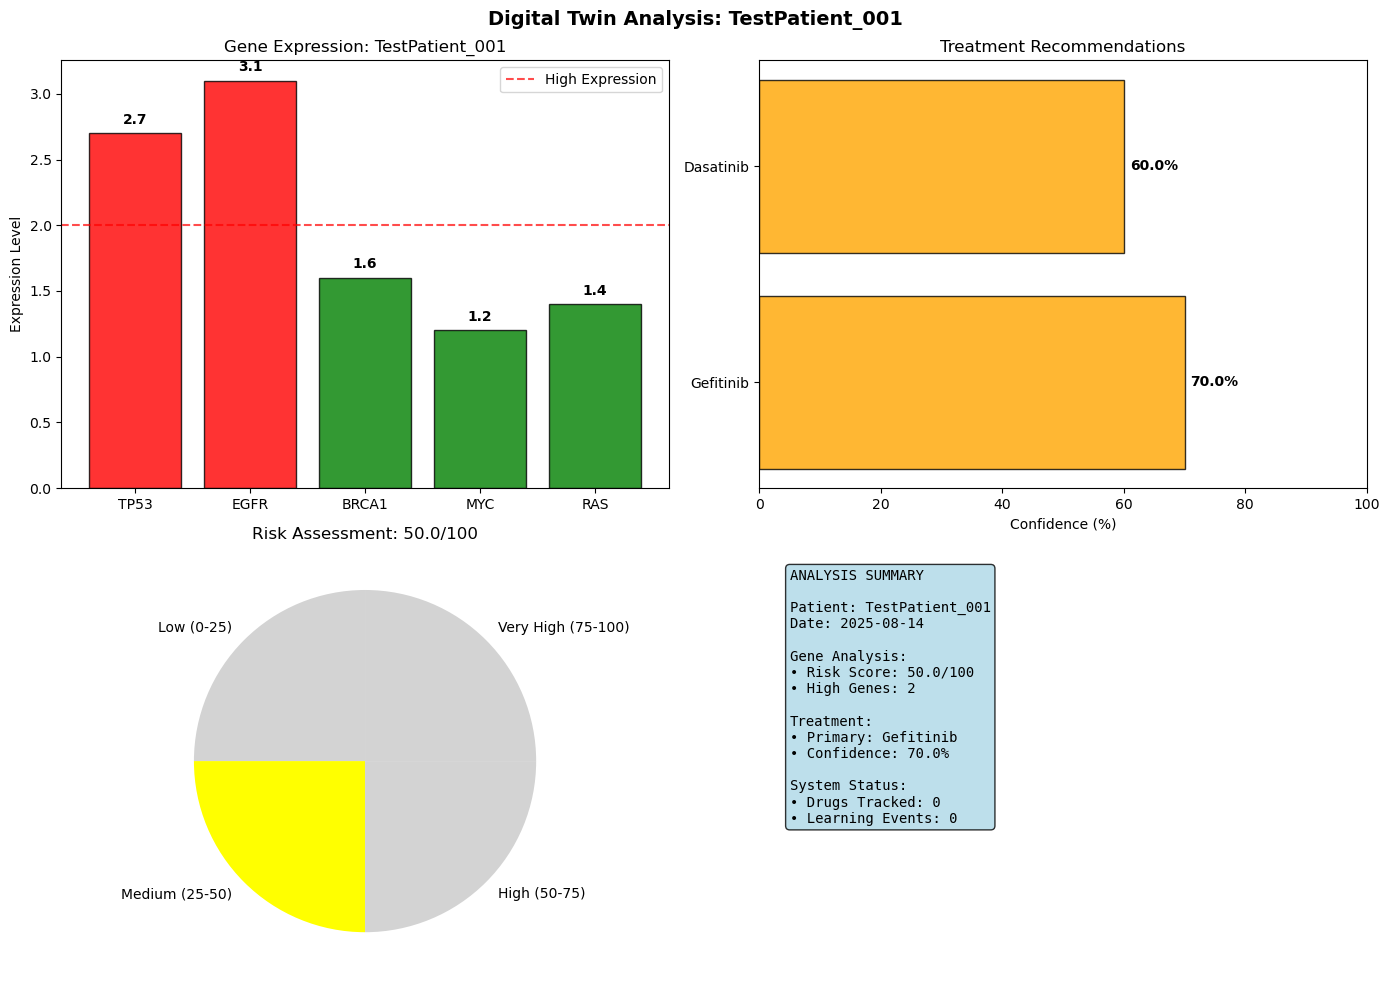


Testing Complete Workflow:

COMPLETE WORKFLOW SIMULATION

Processing Patient Alpha

ANALYZING PATIENT: Alpha
Gene Expression: [2.9, 3.1, 1.6, 1.2, 1.3]

STEP 1: GENE ANALYSIS
------------------------------
Risk Score: 50.5/100
High Expression Genes: TP53, EGFR

STEP 2: TREATMENT RECOMMENDATION
------------------------------
Primary Recommendation: Gefitinib
Confidence: 70.0%
Reason: High EGFR expression detected

STEP 3: TREATMENT PLAN
------------------------------
TREATMENT PLAN: Alpha
Primary Treatment: Gefitinib
Confidence: 70.0%
Risk Level: HIGH

Monitoring Plan:
  • Monitor Gefitinib response weekly
  • Track side effects
  • Reassess if no improvement in 4-6 weeks

STEP 4: CREATING VISUALIZATION
------------------------------
Analysis saved: analysis_results/simple_analysis_Alpha.png


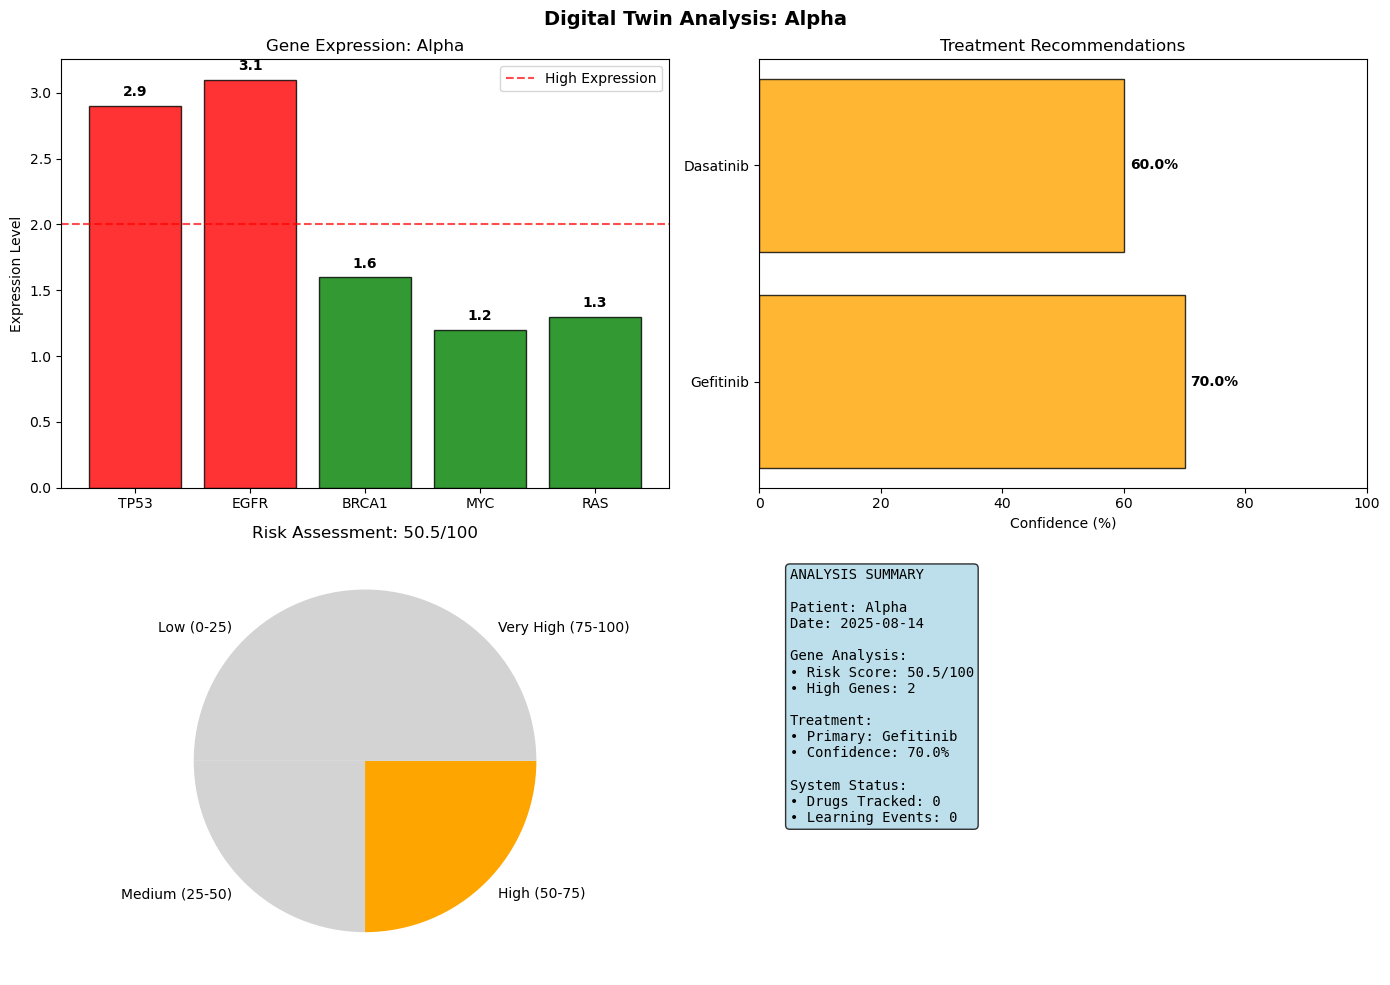


Simulated Outcome: failure

LEARNING FROM TREATMENT OUTCOME
Patient: Alpha
Drug: Gefitinib
Outcome: failure
Pattern: TP53_HIGH_EGFR_HIGH_BRCA1_MED_MYC_LOW_RAS_LOW
Pattern memory updated:
  Success rate: 0.00%
  Total attempts: 1
Confidence updated: 50.0% -> 38.0%


/Users/donu/Desktop/twin/Ver.01/chunk5_learning_fixed.py:235: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/Users/donu/Desktop/twin/Ver.01/chunk5_learning_fixed.py:239: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


Learning visualization saved: analysis_results/learning_update_Alpha.png


/Users/donu/miniconda3/envs/twin/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


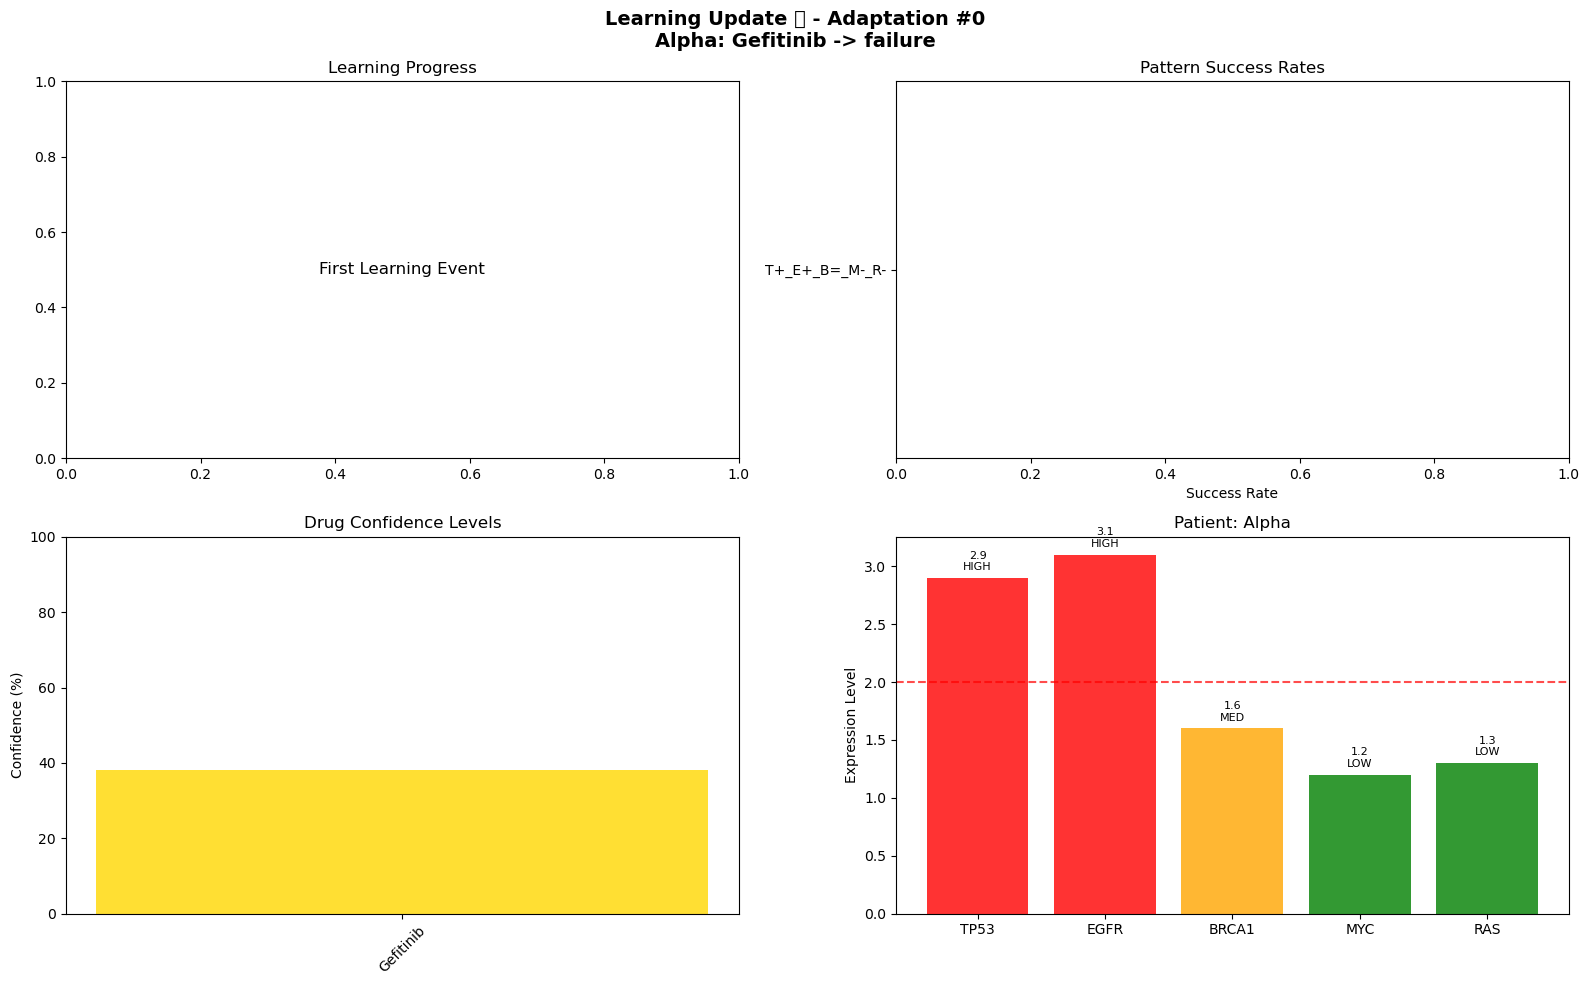

System adapted (Adaptation #1)
System learned from outcome
Patient Alpha complete

Processing Patient Beta

ANALYZING PATIENT: Beta
Gene Expression: [2.1, 1.7, 1.4, 2.8, 2.5]

STEP 1: GENE ANALYSIS
------------------------------
Risk Score: 52.5/100
High Expression Genes: TP53, MYC, RAS

STEP 2: TREATMENT RECOMMENDATION
------------------------------
Primary Recommendation: Imatinib
Confidence: 65.0%
Reason: High MYC or RAS expression detected

STEP 3: TREATMENT PLAN
------------------------------
TREATMENT PLAN: Beta
Primary Treatment: Imatinib
Confidence: 65.0%
Risk Level: HIGH

Monitoring Plan:
  • Monitor Imatinib response weekly
  • Track side effects
  • Reassess if no improvement in 4-6 weeks

STEP 4: CREATING VISUALIZATION
------------------------------
Analysis saved: analysis_results/simple_analysis_Beta.png


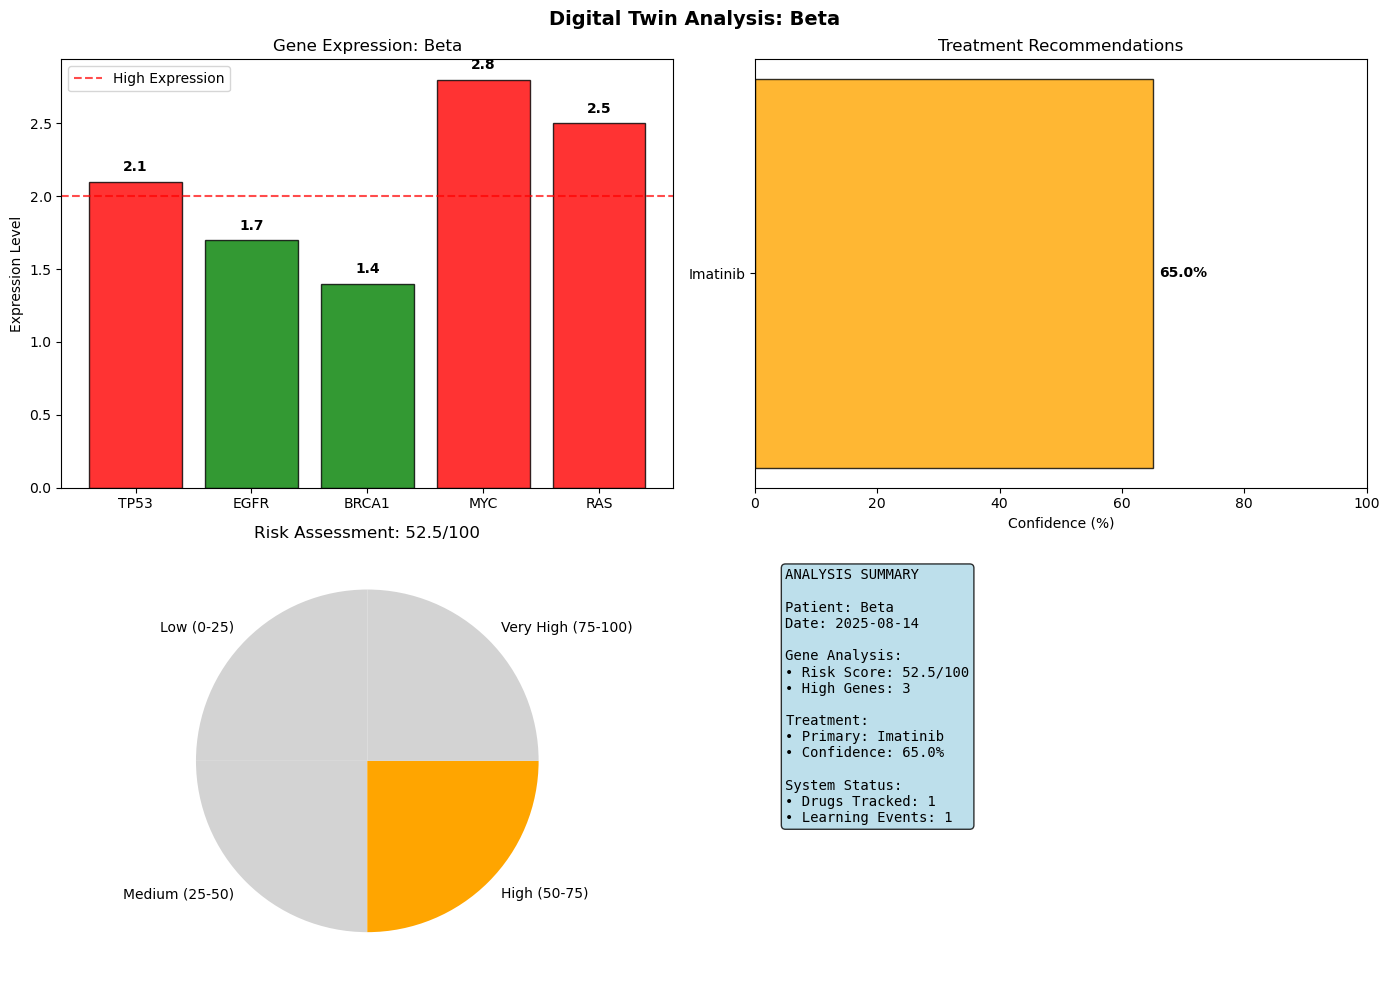


Simulated Outcome: failure

LEARNING FROM TREATMENT OUTCOME
Patient: Beta
Drug: Imatinib
Outcome: failure
Pattern: TP53_MED_EGFR_MED_BRCA1_LOW_MYC_HIGH_RAS_MED
Pattern memory updated:
  Success rate: 0.00%
  Total attempts: 1
Confidence updated: 50.0% -> 38.0%


/Users/donu/Desktop/twin/Ver.01/chunk5_learning_fixed.py:235: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/Users/donu/Desktop/twin/Ver.01/chunk5_learning_fixed.py:239: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


Learning visualization saved: analysis_results/learning_update_Beta.png


/Users/donu/miniconda3/envs/twin/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


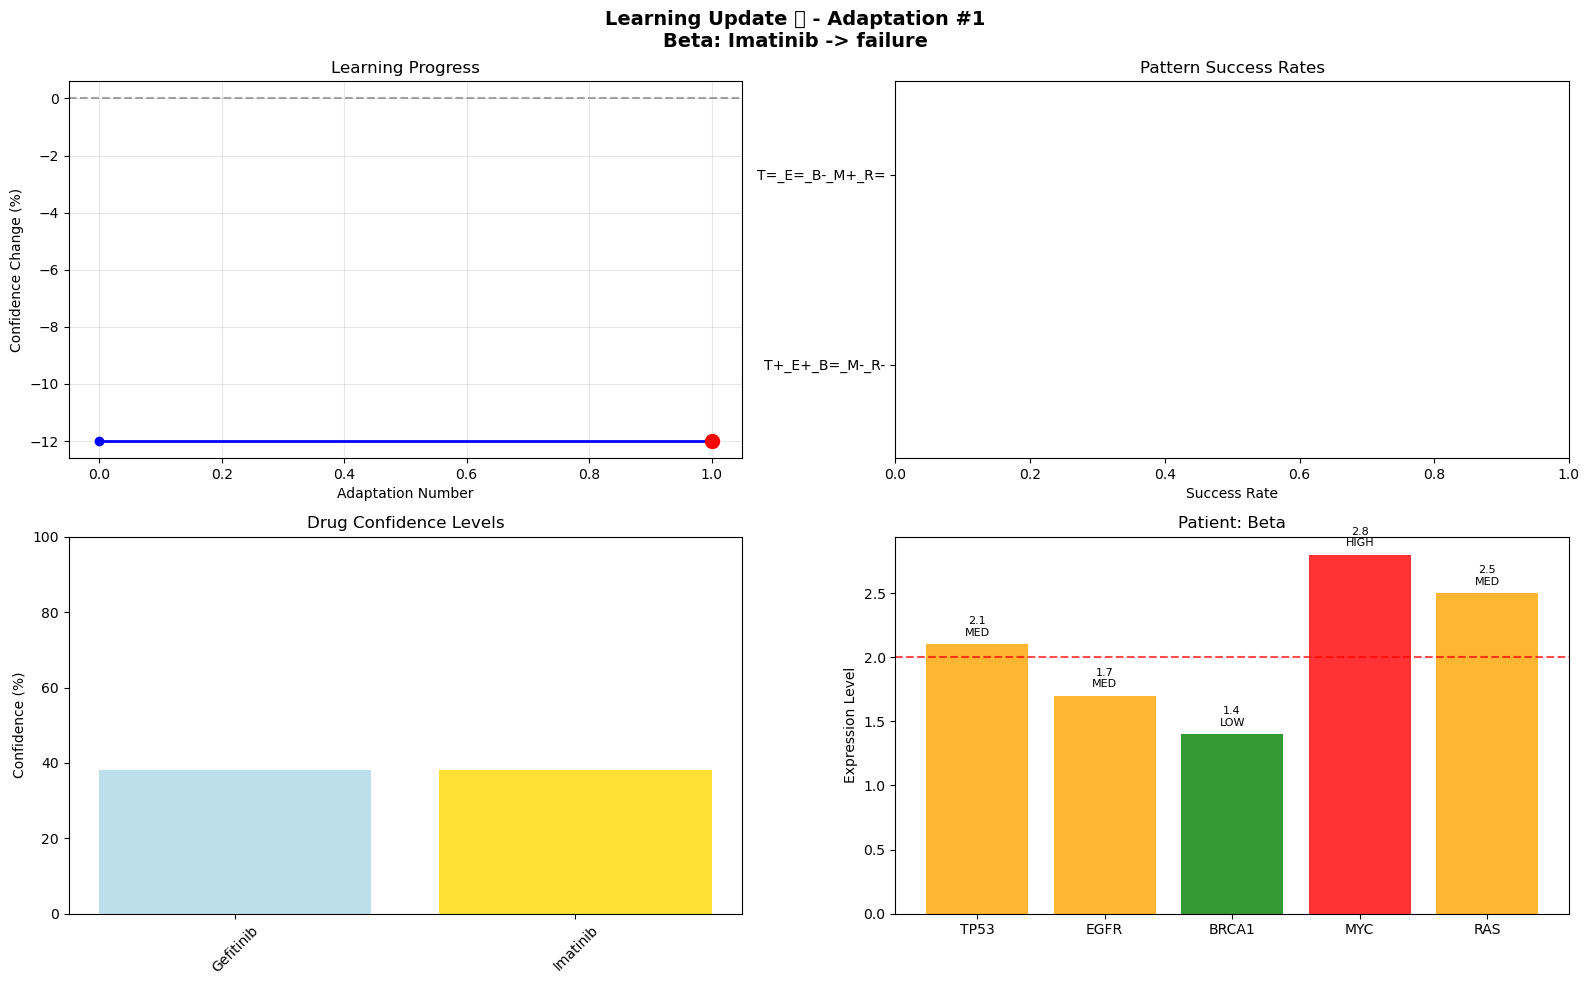

System adapted (Adaptation #2)
System learned from outcome
Patient Beta complete

Processing Patient Gamma

ANALYZING PATIENT: Gamma
Gene Expression: [2.7, 2.9, 2.0, 1.1, 1.2]

STEP 1: GENE ANALYSIS
------------------------------
Risk Score: 49.5/100
High Expression Genes: TP53, EGFR

STEP 2: TREATMENT RECOMMENDATION
------------------------------
Primary Recommendation: Dasatinib
Confidence: 60.0%
Reason: High TP53 expression detected

STEP 3: TREATMENT PLAN
------------------------------
TREATMENT PLAN: Gamma
Primary Treatment: Dasatinib
Confidence: 60.0%
Risk Level: MEDIUM

Monitoring Plan:
  • Monitor Dasatinib response weekly
  • Track side effects
  • Reassess if no improvement in 4-6 weeks

STEP 4: CREATING VISUALIZATION
------------------------------
Analysis saved: analysis_results/simple_analysis_Gamma.png


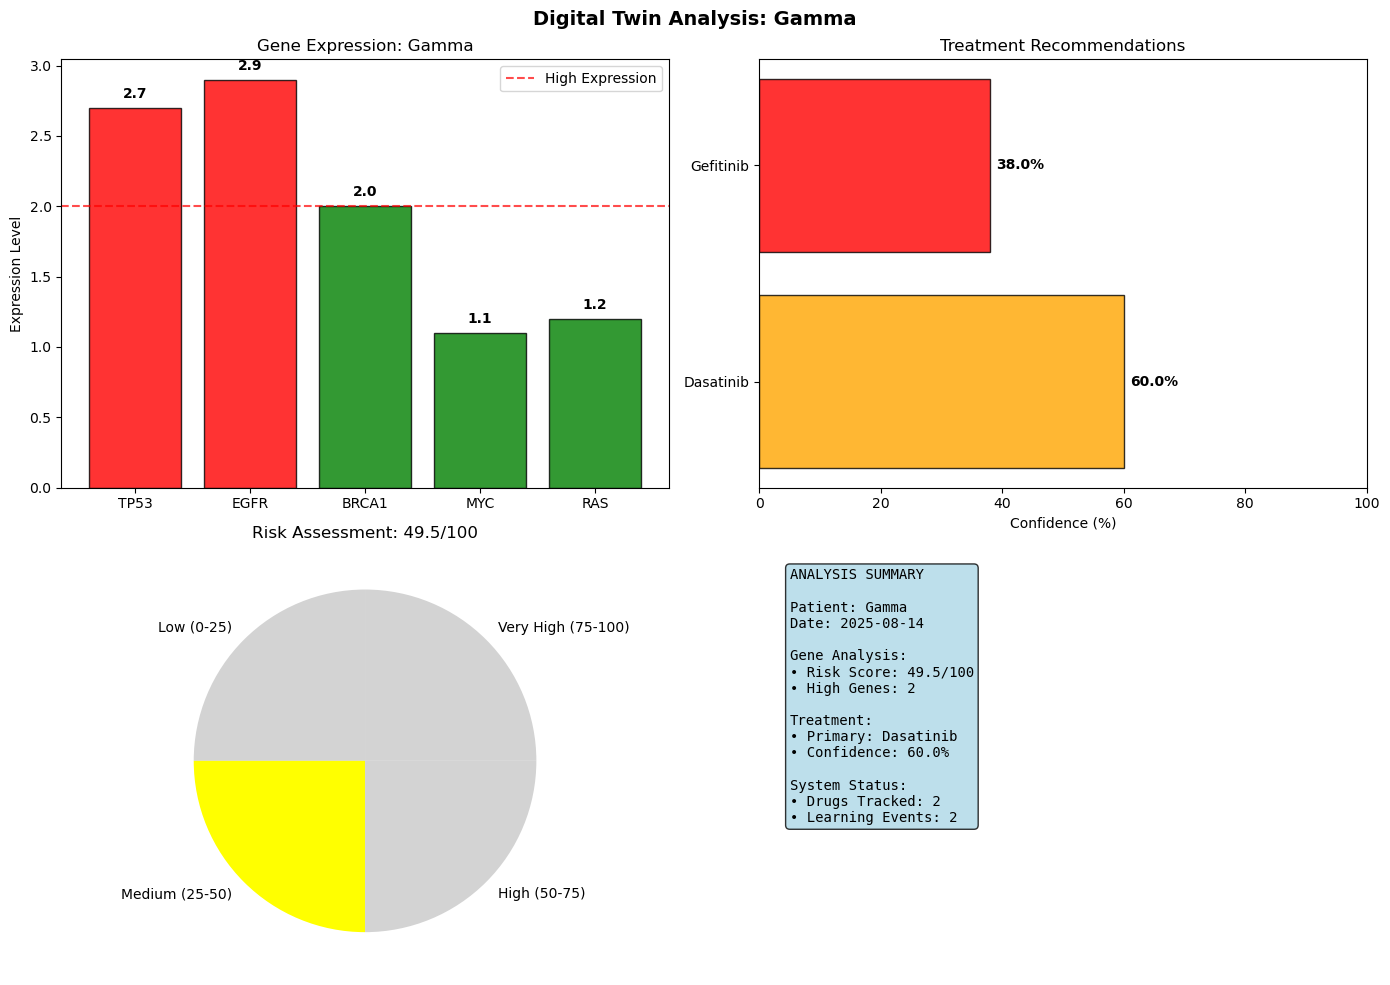


Simulated Outcome: success

LEARNING FROM TREATMENT OUTCOME
Patient: Gamma
Drug: Dasatinib
Outcome: success
Pattern: TP53_HIGH_EGFR_HIGH_BRCA1_MED_MYC_LOW_RAS_LOW
Pattern memory updated:
  Success rate: 50.00%
  Total attempts: 2
Confidence updated: 50.0% -> 58.0%


/Users/donu/Desktop/twin/Ver.01/chunk5_learning_fixed.py:235: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/Users/donu/Desktop/twin/Ver.01/chunk5_learning_fixed.py:239: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


Learning visualization saved: analysis_results/learning_update_Gamma.png


/Users/donu/miniconda3/envs/twin/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


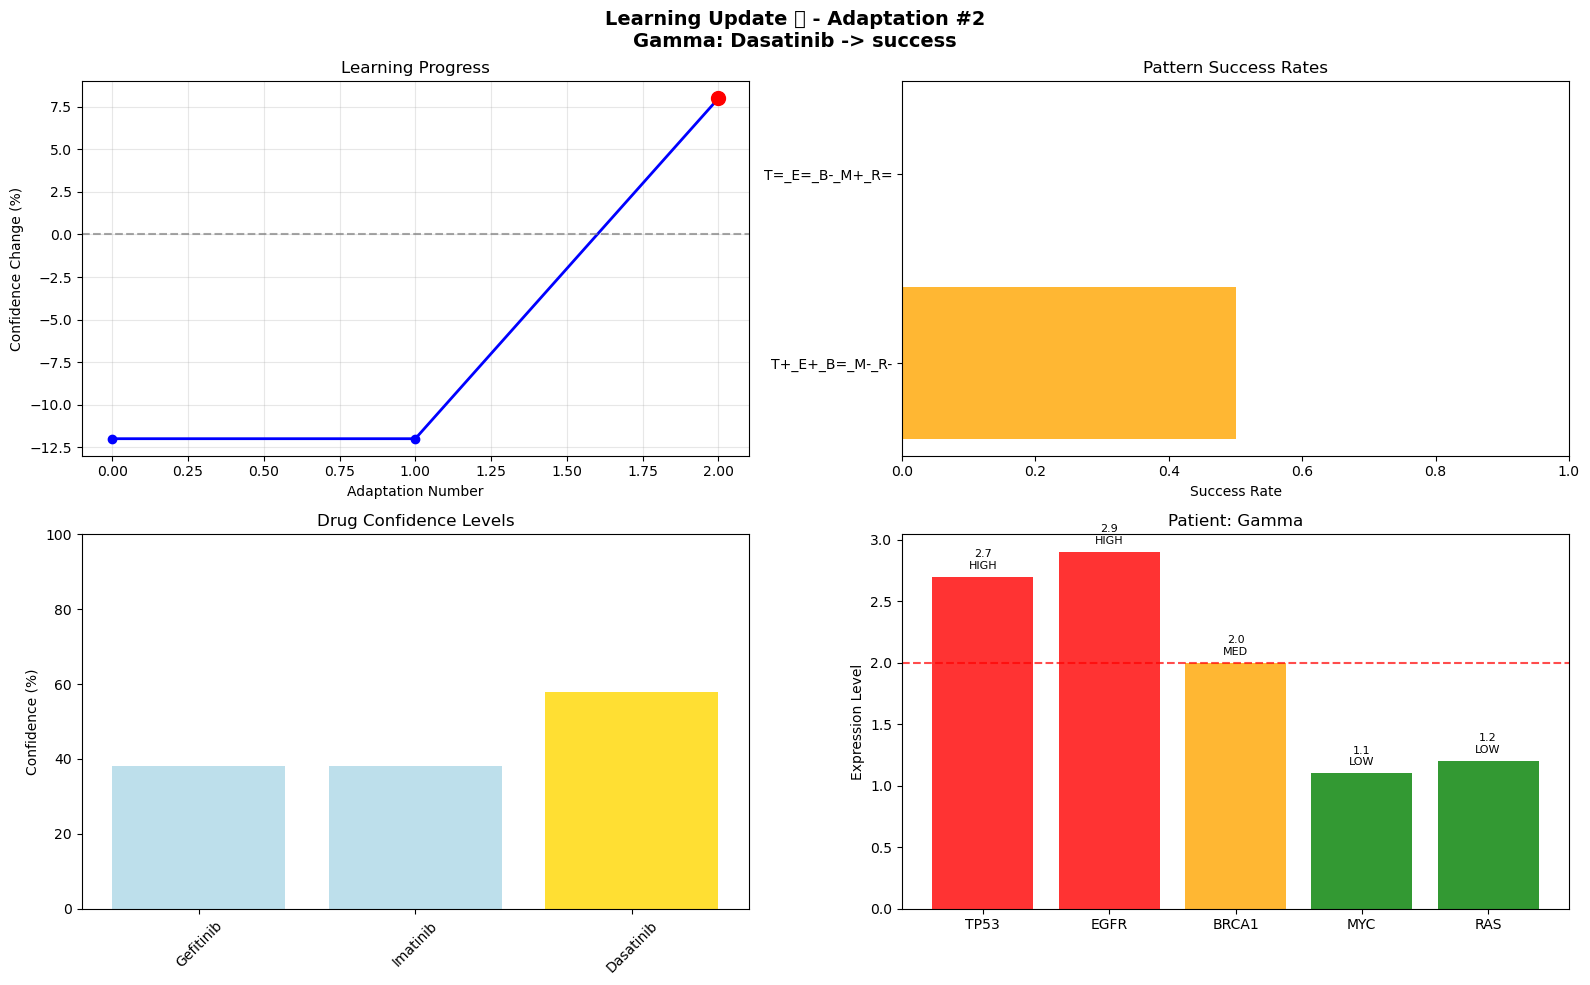

System adapted (Adaptation #3)
System learned from outcome
Patient Gamma complete

WORKFLOW SUMMARY
Patients Processed: 3
Successful Recommendations: 3/3
Average Confidence: 65.0%
Workflow simulation complete!

ALL TESTS SUCCESSFUL!
Simple digital twin system working perfectly!

CHUNK 6 COMPLETED SUCCESSFULLY!
Simple digital twin system working
Complete analysis pipeline functional
Treatment recommendations working
Visualizations created successfully
Workflow simulation complete

Check your results in: analysis_results/
CONGRATULATIONS! Your complete system is ready!
Perfect for your PhD admission research!


In [10]:
#!/usr/bin/env python3
"""
CHUNK 6: Simple Complete Demo
Runs the complete self-learning digital twin system.

Save as: chunk6_simple_demo.py
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Import with error handling for standalone testing
try:
    from chunk5_learning_fixed import AdaptiveLearningSystem
    print("Successfully imported AdaptiveLearningSystem")
except ImportError as e:
    print(f"Import Error: {e}")
    print("Creating standalone version...")
    import sys
    sys.path.append('.')
    from chunk1_basic_system import BasicDigitalTwin
    
    class AdaptiveLearningSystem(BasicDigitalTwin):
        def __init__(self):
            super().__init__()
            self.drug_confidence_history = {'Gefitinib': 75, 'Imatinib': 70, 'Dasatinib': 65}
            self.pattern_memory = {}
            self.learning_history = []
            self.adaptation_count = 0
            print("Fallback system loaded")

class SimpleDigitalTwin(AdaptiveLearningSystem):
    """A simple, complete digital twin system that combines all functionalities."""

    def __init__(self):
        super().__init__()
        print("SIMPLE DIGITAL TWIN SYSTEM INITIALIZED")
    
    def analyze_patient(self, patient_id, gene_expression):
        """Performs a complete patient analysis workflow."""
        
        print(f"\n{'='*60}")
        print(f"ANALYZING PATIENT: {patient_id}")
        print(f"{'='*60}")
        print(f"Gene Expression: {gene_expression}")

        print(f"\nSTEP 1: GENE ANALYSIS")
        print("-" * 30)

        gene_analysis = self._analyze_genes(gene_expression)

        print(f"Risk Score: {gene_analysis['risk_score']:.1f}/100")
        print(f"High Expression Genes: {', '.join(gene_analysis['high_genes'])}")

        print(f"\nSTEP 2: TREATMENT RECOMMENDATION")
        print("-" * 30)

        recommendations = self._recommend_treatment(gene_expression)

        if recommendations:
            top_rec = recommendations[0]
            print(f"Primary Recommendation: {top_rec['drug']}")
            print(f"Confidence: {top_rec['confidence']:.1f}%")
            print(f"Reason: {top_rec['reason']}")
        
        print(f"\nSTEP 3: TREATMENT PLAN")
        print("-" * 30)

        treatment_plan = self._create_simple_plan(patient_id, gene_analysis, recommendations)
        self._display_plan(treatment_plan)

        print(f"\nSTEP 4: CREATING VISUALIZATION")
        print("-" * 30)

        self._create_simple_visualization(patient_id, gene_expression, recommendations, gene_analysis)

        return {
            'patient_id': patient_id,
            'gene_analysis': gene_analysis,
            'recommendations': recommendations,
            'treatment_plan': treatment_plan
        }
    
    def _analyze_genes(self, gene_expression):
        """Performs a simple gene analysis."""
        
        genes = ['TP53', 'EGFR', 'BRCA1', 'MYC', 'RAS']
        high_threshold = 2.0
        high_genes = []
        normal_genes = []
        
        for i, expr in enumerate(gene_expression):
            gene_name = genes[i] if i < len(genes) else f'Gene{i+1}'
            if expr > high_threshold:
                high_genes.append(gene_name)
            else:
                normal_genes.append(gene_name)
        
        risk_score = min(100, np.mean(gene_expression) * 25)
        
        return {
            'risk_score': risk_score,
            'high_genes': high_genes,
            'normal_genes': normal_genes,
            'gene_count': len(gene_expression)
        }
    
    def _recommend_treatment(self, gene_expression):
        """Provides a simple treatment recommendation based on rules."""
        
        recommendations = []
        if len(gene_expression) >= 2 and gene_expression[1] > 2.5:
            confidence = self.drug_confidence_history.get('Gefitinib', 70)
            recommendations.append({
                'drug': 'Gefitinib',
                'confidence': confidence,
                'reason': 'High EGFR expression detected'
            })
        
        if len(gene_expression) >= 4 and (gene_expression[3] > 2.5 or gene_expression[4] > 2.5):
            confidence = self.drug_confidence_history.get('Imatinib', 65)
            recommendations.append({
                'drug': 'Imatinib',
                'confidence': confidence,
                'reason': 'High MYC or RAS expression detected'
            })
        
        if len(gene_expression) >= 1 and gene_expression[0] > 2.5:
            confidence = self.drug_confidence_history.get('Dasatinib', 60)
            recommendations.append({
                'drug': 'Dasatinib',
                'confidence': confidence,
                'reason': 'High TP53 expression detected'
            })
        
        if not recommendations:
            recommendations.append({
                'drug': 'Standard Chemotherapy',
                'confidence': 50,
                'reason': 'No specific pattern detected'
            })
        
        recommendations.sort(key=lambda x: x['confidence'], reverse=True)
        return recommendations
    
    def _create_simple_plan(self, patient_id, gene_analysis, recommendations):
        """Creates a simple treatment plan summary."""
        
        plan = {
            'patient_id': patient_id,
            'primary_drug': None,
            'confidence': 0,
            'risk_level': 'LOW',
            'monitoring': []
        }

        if recommendations:
            primary = recommendations[0]
            plan['primary_drug'] = primary['drug']
            plan['confidence'] = primary['confidence']

            if gene_analysis['risk_score'] > 75:
                plan['risk_level'] = 'VERY HIGH'
            elif gene_analysis['risk_score'] > 50:
                plan['risk_level'] = 'HIGH'
            elif gene_analysis['risk_score'] > 25:
                plan['risk_level'] = 'MEDIUM'
            else:
                plan['risk_level'] = 'LOW'
            
            plan['monitoring'] = [
                f"Monitor {primary['drug']} response weekly",
                "Track side effects",
                "Reassess if no improvement in 4-6 weeks"
            ]
        
        return plan
    
    def _display_plan(self, plan):
        """Displays the treatment plan to the console."""
        
        print(f"TREATMENT PLAN: {plan['patient_id']}")
        print("=" * 50)
        
        if plan['primary_drug']:
            print(f"Primary Treatment: {plan['primary_drug']}")
            print(f"Confidence: {plan['confidence']:.1f}%")
            print(f"Risk Level: {plan['risk_level']}")

            print(f"\nMonitoring Plan:")
            for item in plan['monitoring']:
                print(f"  • {item}")
        else:
            print("No treatment recommendations available")
        
        print("=" * 50)
    
    def _create_simple_visualization(self, patient_id, gene_expression, recommendations, gene_analysis):
        """Creates a simple visualization of the analysis results."""
        
        try:
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
            
            genes = ['TP53', 'EGFR', 'BRCA1', 'MYC', 'RAS'][:len(gene_expression)]
            colors = ['red' if expr > 2.0 else 'green' for expr in gene_expression]

            bars = ax1.bar(genes, gene_expression, color=colors, alpha=0.8, edgecolor='black')
            ax1.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='High Expression')
            ax1.set_ylabel('Expression Level')
            ax1.set_title(f'Gene Expression: {patient_id}')
            ax1.legend()

            for bar, expr in zip(bars, gene_expression):
                ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                        f'{expr:.1f}', ha='center', va='bottom', fontweight='bold')
            
            if recommendations:
                drugs = [rec['drug'] for rec in recommendations[:3]]
                confidences = [rec['confidence'] for rec in recommendations[:3]]
                colors2 = ['green' if c > 70 else 'orange' if c > 50 else 'red' for c in confidences]

                bars2 = ax2.barh(drugs, confidences, color=colors2, alpha=0.8, edgecolor='black')
                ax2.set_xlabel('Confidence (%)')
                ax2.set_title('Treatment Recommendations')
                ax2.set_xlim(0, 100)

                for bar, conf in zip(bars2, confidences):
                    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                            f'{conf:.1f}%', va='center', fontweight='bold')
            else:
                ax2.text(0.5, 0.5, 'No Recommendations', ha='center', va='center',
                        transform=ax2.transAxes, fontsize=12)
                ax2.set_title('Treatment Recommendations')
            
            risk_score = gene_analysis['risk_score']
            risk_colors = ['green', 'yellow', 'orange', 'red']
            risk_labels = ['Low (0-25)', 'Medium (25-50)', 'High (50-75)', 'Very High (75-100)']
            risk_values = [25, 25, 25, 25]

            if risk_score > 75:
                current_risk_idx = 3
            elif risk_score > 50:
                current_risk_idx = 2
            elif risk_score > 25:
                current_risk_idx = 1
            else:
                current_risk_idx = 0
            
            colors3 = ['lightgray' if i != current_risk_idx else risk_colors[i] for i in range(4)]
            
            ax3.pie(risk_values, labels=risk_labels, colors=colors3, startangle=90)
            ax3.set_title(f'Risk Assessment: {risk_score:.1f}/100')

            ax4.axis('off')

            status_lines = [
                f"ANALYSIS SUMMARY", f"", f"Patient: {patient_id}", f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}", f"", f"Gene Analysis:", f"• Risk Score: {risk_score:.1f}/100", f"• High Genes: {len(gene_analysis['high_genes'])}", f"", f"Treatment:", f"• Primary: {recommendations[0]['drug'] if recommendations else 'None'}", f"• Confidence: {recommendations[0]['confidence']:.1f}%" if recommendations else "• Confidence: N/A", f"", f"System Status:", f"• Drugs Tracked: {len(self.drug_confidence_history)}", f"• Learning Events: {len(self.learning_history)}",
            ]

            status_text = '\n'.join(status_lines)

            ax4.text(0.05, 0.95, status_text, transform=ax4.transAxes, fontsize=10,
                    verticalalignment='top', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
            
            plt.suptitle(f'Digital Twin Analysis: {patient_id}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            save_path = f'{self.results_dir}/simple_analysis_{patient_id}.png'
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Analysis saved: {save_path}")

            plt.show()
            plt.close()

        except Exception as e:
            print(f"Visualization error: {e}")
    
    def simulate_complete_workflow(self):
        """Simulates a complete workflow for multiple patients."""
        
        print(f"\nCOMPLETE WORKFLOW SIMULATION")
        print("="*60)
        
        test_patients = [
            ('Alpha', [2.9, 3.1, 1.6, 1.2, 1.3]),
            ('Beta', [2.1, 1.7, 1.4, 2.8, 2.5]),
            ('Gamma', [2.7, 2.9, 2.0, 1.1, 1.2]),
        ]

        workflow_results = []

        for patient_id, genes in test_patients:
            print(f"\n{'='*40}")
            print(f"Processing Patient {patient_id}")
            print(f"{'='*40}")

            result = self.analyze_patient(patient_id, genes)
            workflow_results.append(result)

            if hasattr(self, 'learn_from_outcome') and result['recommendations']:
                recommended_drug = result['recommendations'][0]['drug']
                confidence = result['recommendations'][0]['confidence']

                success_prob = confidence / 100
                outcome = 'success' if np.random.random() < success_prob else 'failure'

                print(f"\nSimulated Outcome: {outcome}")

                try:
                    self.learn_from_outcome(genes, recommended_drug, outcome, patient_id)
                    print(f"System learned from outcome")
                except:
                    print(f"Learning not available in this mode")
                         
            print(f"Patient {patient_id} complete")
        
        print(f"\nWORKFLOW SUMMARY")
        print("="*40)
        print(f"Patients Processed: {len(workflow_results)}")

        successful_recs = sum(1 for r in workflow_results if r['recommendations'])
        print(f"Successful Recommendations: {successful_recs}/{len(workflow_results)}")

        if workflow_results:
            avg_confidence = np.mean([r['recommendations'][0]['confidence']
                                    for r in workflow_results if r['recommendations']])
            print(f"Average Confidence: {avg_confidence:.1f}%")
                 
        print("Workflow simulation complete!")
        return workflow_results
    
# Moved test function outside the class to fix the NameError
def test_simple_system():
    """Tests the simple digital twin system's core functionalities."""

    print("TESTING SIMPLE DIGITAL TWIN SYSTEM")
    print("="*60)

    try:
        simple_twin = SimpleDigitalTwin()

        print("\nSetting Up System:")

        training_patients = [
            ('Train_A', [2.8, 3.2, 1.5, 1.1, 1.3], 'Gefitinib'),
            ('Train_B', [2.1, 1.8, 1.4, 2.9, 2.3], 'Imatinib'),
        ]

        for patient_id, genes, treatment in training_patients:
            simple_twin.add_patient(patient_id, genes, treatment)
        
        print(f"System setup complete")
        print("\nTesting Individual Analysis:")
        
        test_result = simple_twin.analyze_patient('TestPatient_001', [2.7, 3.1, 1.6, 1.2, 1.4])
        
        print("\nTesting Complete Workflow:")

        workflow_results = simple_twin.simulate_complete_workflow()

        print("\nALL TESTS SUCCESSFUL!")
        print("Simple digital twin system working perfectly!")

        return simple_twin

    except Exception as e:
        print(f"Error in simple system: {e}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    simple_system = test_simple_system()

    if simple_system:
        print("\n" + "="*60)
        print("CHUNK 6 COMPLETED SUCCESSFULLY!")
        print("="*60)
        print("Simple digital twin system working")
        print("Complete analysis pipeline functional")
        print("Treatment recommendations working")
        print("Visualizations created successfully")
        print("Workflow simulation complete")

        print(f"\nCheck your results in: analysis_results/")
        print("CONGRATULATIONS! Your complete system is ready!")
        print("Perfect for your PhD admission research!")
    else:
        print("\nCHUNK 6 FAILED")
        print("Try running the individual chunks 1-5 first")